# FairDisCo + Dual ResNet-18 for Fair Skin Disease Classification

Adapter of FairDisCo (Du et al., 2022) using the **dual ResNet-18 encoder backbone**  


## Phase 0 — Environment Setup

In [43]:
!pip install -q scikit-learn \
               matplotlib seaborn pandas tqdm Pillow


In [44]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
# timm replaced by torchvision ResNet-18
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

import os
_hf_token = os.environ.get('HF_TOKEN', '')
if _hf_token:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = _hf_token
    print(f'HF token loaded ({len(_hf_token)} chars).')
else:
    print('[INFO] No HF_TOKEN found — downloads may be slow. '
          'Add it via Kaggle Secrets → HF_TOKEN.')

_BACKBONE_CACHE = Path('/kaggle/working/backbone_cache')
_BACKBONE_CACHE.mkdir(exist_ok=True)
os.environ['TORCH_HOME']            = str(_BACKBONE_CACHE)
os.environ['HF_HOME']               = str(_BACKBONE_CACHE)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(_BACKBONE_CACHE)
print(f'Backbone cache dir: {_BACKBONE_CACHE}')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
[INFO] No HF_TOKEN found — downloads may be slow. Add it via Kaggle Secrets → HF_TOKEN.
Backbone cache dir: /kaggle/working/backbone_cache


In [45]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
DRIVE_ROOT = Path('/kaggle/input/datasets')
WORK_ROOT  = Path('/kaggle/working')

CFG = dict(
    # Dataset roots  (read-only)
    hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    derm7pt_root  = DRIVE_ROOT / 'asosenge/derm7pt',
    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    ckpt_dir      = WORK_ROOT / 'checkpoints',
    results_dir   = WORK_ROOT / 'results',
    # Architecture — Dual ResNet-18 + FairDisCo disentanglement heads
    backbone      = 'resnet18',
    embed_dim     = 512,      # ResNet-18 feature dim (global avg-pool output)
    proj_dim      = 128,      # contrastive projection head output dim (paper: 128)
    img_size      = 224,
    # Training hyperparameters (from FairDisCo paper: Adam lr=1e-4, StepLR step=2 gamma=0.9)
    batch_size    = 32,
    num_epochs    = 100,
    lr            = 1e-4,
    min_lr        = 1e-6,
    weight_decay  = 0.0,      # paper uses plain Adam, no weight decay
    warmup_epochs = 0,        # paper uses StepLR, no warmup
    # FairDisCo loss weights (paper: alpha=1.0, beta=0.8)
    alpha         = 1.0,      # weight for Lconf
    beta          = 0.8,      # weight for Lcontr
    temperature   = 0.1,      # contrastive temperature (paper: 0.1)
    # Labels
    num_classes    = 5,
    num_skin_types = 6,
    # Online augmentation probability
    aug_probability = 0.85,
)

LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
    3: 'actinic keratosis',
    4: 'squamous cell carcinoma',
}
DERM7PT_CLASSES = {0, 1, 2}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir','ckpt_dir','results_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','derm7pt_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')
print(f'  Backbone  : {CFG["backbone"]}  embed_dim={CFG["embed_dim"]}  proj_dim={CFG["proj_dim"]}')
print(f'  Epochs    : {CFG["num_epochs"]}  lr={CFG["lr"]}')
print(f'  alpha     : {CFG["alpha"]} (Lconf weight)  beta: {CFG["beta"]} (Lcontr weight)')
print(f'  temperature: {CFG["temperature"]}')

Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  derm7pt_root
  Backbone  : resnet18  embed_dim=512  proj_dim=128
  Epochs    : 100  lr=0.0001
  alpha     : 1.0 (Lconf weight)  beta: 0.8 (Lcontr weight)
  temperature: 0.1


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [46]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & MAPPING TABLES
# ════════════════════════════════════════════════════════════════════════════

import re as _re

VALID_LABELS = {0, 1, 2, 3, 4}   # discard anything outside

def _clean(s: str) -> str:
    """Lowercase, strip, normalise hyphens/underscores to spaces."""
    s = str(s).lower().strip()
    s = _re.sub(r'[-_]+', ' ', s)
    s = _re.sub(r'\s+', ' ', s)
    return s

# ── HAM10000  (dx codes verified from HAM10000_metadata.csv) ─────────────
HAM_MAP = {
    'mel':   0,   # melanoma
    'nv':    1,   # nevus
    'bcc':   2,   # basal cell carcinoma
    'akiec': 3,   # actinic keratosis / SCC in-situ
}

# ── HIBA  (diagnosis column) ──────────────────────────────────────────────
HIBA_MAP = {
    'melanoma':                0,
    'nevus':                   1,
    'basal cell carcinoma':    2,
    'actinic keratosis':       3,
    'squamous cell carcinoma': 4,
}

# ── Fitzpatrick17k  ('label' column) ─────────────────────────────────────
FITZ_MAP = {
    # Melanoma (0)
    'melanoma':                             0,
    'malignant melanoma':                   0,
    'superficial spreading melanoma ssm':   0,
    'lentigo maligna':                      0,
    'lentigo maligna melanoma':             0,
    'acral lentiginous melanoma':           0,
    'nodular melanoma':                     0,
    # Nevus (1)
    'nevocytic nevus':                      1,
    'epidermal nevus':                      1,
    'congenital nevus':                     1,
    'halo nevus':                           1,
    'becker nevus':                         1,
    'nevus sebaceous of jadassohn':         1,
    'naevus comedonicus':                   1,
    # Basal Cell Carcinoma (2)
    'basal cell carcinoma':                 2,
    'basal cell carcinoma morpheiform':     2,
    'solid cystic basal cell carcinoma':    2,
    # Actinic Keratosis (3)
    'actinic keratosis':                    3,
    'porokeratosis actinic':                3,
    'bowens disease':                       3,
    'keratoacanthoma':                      3,
    # Squamous Cell Carcinoma (4)
    'squamous cell carcinoma':              4,
    'squamous cell carcinoma in situ':      4,
}

# ── Derm7pt label map  (meta.csv 'diagnosis' column) ─────────────────────
DERM7PT_MAP = {
    # MEL variants
    'melanoma':                     0,
    'melanoma (in situ)':           0,
    'melanoma (less than 0.76 mm)': 0,
    'melanoma (0.76 to 1.5 mm)':    0,
    'melanoma (more than 1.5 mm)':  0,
    'melanoma metastasis':          0,
    # NEV variants
    'dermal nevus':                 1,
    'clark nevus':                  1,
    'reed or spitz nevus':          1,
    'blue nevus':                   1,
    'recurrent nevus':              1,
    'combined nevus':               1,
    'congenital nevus':             1,
    # BCC
    'basal cell carcinoma':         2,
}

def harmonize_label(raw: str, mapping: dict, default=None) -> int | None:
    """Map a raw diagnosis string → canonical class integer, or None to exclude.

    Returns None when the label is not in any of the 5 valid classes.
    The caller is responsible for skipping None rows.
    """
    s = _clean(raw)
    if s in mapping:
        v = mapping[s]
        return v if v in VALID_LABELS else None
    for k, v in mapping.items():
        if k in s or s in k:
            return v if v in VALID_LABELS else None
    if 'nevus' in s or 'nevi' in s:
        return 1   # class 1 is always valid
    return None    # not one of the 5 classes → exclude

def parse_fst(raw) -> int:
    """Parse an integer Fitzpatrick skin type (1–6) → index (0–5).
    Returns -1 for missing / out-of-range values.
    """
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN_TO_INT = {
    'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6,
}
def parse_fst_roman(raw) -> int:
    """Parse roman-numeral or integer FST (HIBA uses I–VI strings).
    Returns 0-based index (0=FST I … 5=FST VI), or -1 if unparseable.
    """
    s = str(raw).lower().strip()
    if s in _ROMAN_TO_INT:
        return _ROMAN_TO_INT[s] - 1
    return parse_fst(raw)

def _verify_labels(df, name, n_classes=5):
    """Drop rows whose label is outside [0, n_classes-1] and report stats."""
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

print('Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).')
print('  FITZ: reads "label" column (fine-grained diagnoses)')
print('  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)')
print('  HAM:  reads "dx" column + ITA-estimated FST')
print('  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)')


Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).
  FITZ: reads "label" column (fine-grained diagnoses)
  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)
  HAM:  reads "dx" column + ITA-estimated FST
  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)


### 1-B  Dataset Parsers

In [47]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va



def _safe_split_3way(df, val_size=0.15, test_size=0.15, seed=42):
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]

    cts     = df['label'].value_counts()
    rare    = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]

    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]

    # First carve off the test split from the full remainder
    try:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size,
            random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size, random_state=seed)

    # Then carve val from the train+val portion
    # val_size is expressed relative to the *original* df, so rescale
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val,
            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val, random_state=seed)

    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Split helpers ready.')


Split helpers ready.


In [48]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    # Validate required columns
    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    # ── Per-lesion accumulation ───────────────────────────────────────
    lesion_data = {}   # lesion_id → {label, fst, clinical:[], derm:[]}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', 'other'))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        # Resolve image path
        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {
                'label': harmonize_label(diag, HIBA_MAP),
                'fst':   fst,
                'clinical': [],
                'derm':    [],
            }
        else:
            # Update FST if we now have a valid value
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                # "clinical: overview" and "clinical: close-up" are both clinical
                lesion_data[lid]['clinical'].append(str(img_path))

    # ── Build rows ────────────────────────────────────────────────────
    paired_rows   = []   # lesions with both modalities
    unpaired_clin = []   # clinical-only images  →  clin_* pool
    unpaired_derm = []   # derm-only images      →  derm_* pool

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            # Paired: use first of each modality
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            # Extra clinical images beyond the first also go to unpaired pool
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    # ── Split each pool ───────────────────────────────────────────────
    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    # Class distribution for paired
    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    # Class distribution for all HIBA images
    all_hiba = pd.concat([df_paired.rename(columns={'clinical_path':'image_path'}).get(['label','skin_type'],pd.DataFrame()),
                           df_uclin[['label','skin_type']] if not df_uclin.empty else pd.DataFrame(),
                           df_uderm[['label','skin_type']] if not df_uderm.empty else pd.DataFrame()])
    if not all_hiba.empty:
        vc2 = all_hiba['label'].value_counts().sort_index()
        print('[HIBA total  ] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc2.items()))
        n_fst = int((all_hiba['skin_type'] >= 0).sum())
        print(f'[HIBA] FST known: {n_fst}/{len(all_hiba)} images')

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready.')


HIBA parser ready.


In [49]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER  (5-class filtered)
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing')
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    lesion_data = {}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', ''))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        label = harmonize_label(diag, HIBA_MAP)
        if label is None:
            continue   # not one of the 5 classes — skip

        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {'label': label, 'fst': fst, 'clinical': [], 'derm': []}
        else:
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                lesion_data[lid]['clinical'].append(str(img_path))

    paired_rows   = []
    unpaired_clin = []
    unpaired_derm = []

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready (5-class filtered).')


HIBA parser ready (5-class filtered).


In [50]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        _fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(_fst_raw) if str(_fst_raw).strip() not in ('-1', '-1.0', 'nan', '') else -1
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        raw   = str(r.get('label', r.get('nine_partition_label', '')))
        label = harmonize_label(raw, FITZ_MAP)
        if label is None:
            skipped += 1
            continue   # not one of the 5 classes
        rows.append({'image_path': str(p), 'label': label,
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})
    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    fst_known_count = int((df.skin_type>=0).sum()) if not df.empty and 'skin_type' in df.columns else 0
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| FST known: {fst_known_count}  | skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te


# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta_path = csvs[0]
    meta_root = meta_path.parent
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]
    )
    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', '')).lower().strip()
        # Only keep mel, nv, bcc, akiec — bkl/df/vasc are excluded
        label = HAM_MAP.get(dx, None)
        if label is None:
            skipped += 1
            continue
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_path': str(p), 'label': label,
                         'skin_type': -1, 'dataset': 'ham10000'})

    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te

print('Unpaired parsers ready (5-class filtered).')


Unpaired parsers ready (5-class filtered).


In [51]:
# ════════════════════════════════════════════════════════════════════════════
# DERM7PT PARSER  (cross-evaluation, paired clinical+dermoscopic)
# ════════════════════════════════════════════════════════════════════════════

def parse_derm7pt(root: Path) -> pd.DataFrame:
    meta_csv = root / 'release_v0' / 'meta' / 'meta.csv'
    if not meta_csv.exists():
        alt = list(root.rglob('meta.csv'))
        if not alt:
            print(f'[WARN] Derm7pt: meta.csv not found under {root}')
            return pd.DataFrame()
        meta_csv = alt[0]

    meta = pd.read_csv(meta_csv)
    print(f'[Derm7pt] {len(meta)} rows | columns: {list(meta.columns)}')

    # ── Base directory for all images (the folder containing the 34 subfolders) ──
    img_base = root / 'release_v0' / 'images'
    if not img_base.exists():
        # Fallback: search for any folder named 'images'
        candidates = list(root.rglob('images'))
        if candidates:
            img_base = candidates[0]
        else:
            img_base = root   # last resort
    print(f'[Derm7pt] image base directory: {img_base}')

    # ── Helper: find an image given a relative path from the CSV ──
    def find_image(rel_path: str) -> str | None:
        rel_path = str(rel_path).strip().replace('\\', '/')
        if not rel_path:
            return None

        # 1) Try exact relative path as is (common case)
        full = img_base / rel_path
        if full.exists():
            return str(full)

        # 2) Try with common extensions (if missing)
        base, ext = Path(rel_path).stem, Path(rel_path).suffix
        if not ext:
            for ext_cand in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                cand = img_base / (rel_path + ext_cand)
                if cand.exists():
                    return str(cand)

        # 3) Case‑insensitive glob (handles .JPG vs .jpg)
        pattern = f"{rel_path}*"  # allow any extra characters
        for match in img_base.glob(pattern):
            if match.is_file():
                return str(match)
        for match in img_base.glob(pattern.lower()):
            if match.is_file():
                return str(match)

        # 4) Last resort: recursive search (slower, but catches misplaced files)
        base_name = Path(rel_path).stem
        for ext_cand in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            for found in img_base.rglob(base_name + ext_cand):
                return str(found)
            for found in img_base.rglob(base_name + ext_cand.lower()):
                return str(found)
        return None

    # Identify diagnosis column
    diag_col = None
    for c in ['diagnosis', 'Diagnosis', 'label', 'Label', 'diag']:
        if c in meta.columns:
            diag_col = c
            break
    if diag_col is None:
        print('[WARN] Derm7pt: could not identify diagnosis column')
        print(f'  Available columns: {list(meta.columns)}')
        return pd.DataFrame()
    print(f'[Derm7pt] using diagnosis column: "{diag_col}"')

    # Identify image filename columns
    derm_col   = next((c for c in ['derm', 'derm_image', 'dermoscopy_image'] if c in meta.columns), None)
    clinic_col = next((c for c in ['clinic', 'clinic_image', 'clinical_image'] if c in meta.columns), None)
    print(f'[Derm7pt] derm col: {derm_col}  clinic col: {clinic_col}')

    rows = []
    skipped_label = 0
    skipped_img   = 0

    for _, r in meta.iterrows():
        raw_diag = str(r.get(diag_col, ''))
        label = harmonize_label(raw_diag, DERM7PT_MAP)
        if label is None or label not in DERM7PT_CLASSES:
            skipped_label += 1
            continue

        derm_path = None
        if derm_col and pd.notna(r.get(derm_col)):
            derm_path = find_image(r[derm_col])

        clinic_path = None
        if clinic_col and pd.notna(r.get(clinic_col)):
            clinic_path = find_image(r[clinic_col])

        if derm_path is None and clinic_path is None:
            skipped_img += 1
            continue

        base = {'label': label, 'skin_type': -1, 'dataset': 'derm7pt'}
        if derm_path:
            rows.append({**base, 'image_path': derm_path, 'modality': 'derm'})
        if clinic_path:
            rows.append({**base, 'image_path': clinic_path, 'modality': 'clinical'})

    df = pd.DataFrame(rows)
    print(f'[Derm7pt] {len(df)} images kept (skipped label={skipped_label}, skipped img={skipped_img})')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('[Derm7pt] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
        mc = df['modality'].value_counts()
        print(f'[Derm7pt] modalities: {dict(mc)}')
    return df


# ── ITA-based Fitzpatrick Skin Type estimator (unchanged) ────────────────
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skcolor.rgb2lab(rgb)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if skin_mask.mean() < min_skin_frac:
            return -1
        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mean_L - 50.0) / mean_b))))
    except Exception:
        return -1

def estimate_fst_for_csv(df: pd.DataFrame, n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            print(f'  [FST cache] loaded {(df["skin_type"]>=0).sum()}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    from concurrent.futures import ThreadPoolExecutor
    paths = df['image_path'].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(ex.map(_estimate_fst_single, paths),
                               total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} ({100*n_known/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_values)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('Derm7pt parser + ITA-FST estimator ready.')
print('NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).')

Derm7pt parser + ITA-FST estimator ready.
NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).


### 1-C  Build CSVs & Data Loaders

In [52]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# ════════════════════════════════════════════════════════════════════════════

def _verify_labels(df, name, n_classes=5):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

# ── Step 1: Parse ──────────────────────────────────────────────────────────
print('='*60, '\nParsing datasets ...')
hiba_tr_p, hiba_va_p, hiba_te_p = parse_hiba(CFG['hiba_root'])
hiba_tr_uc, hiba_va_uc, hiba_te_uc, hiba_tr_ud, hiba_va_ud, hiba_te_ud = _hiba_unpaired_splits

fitz_tr, fitz_va, fitz_te = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va,  ham_te  = parse_ham10000(CFG['ham_root'])

# ── Step 2: Combine into three pools ──────────────────────────────────────
df_paired_all = pd.concat([hiba_tr_p, hiba_va_p, hiba_te_p], ignore_index=True)

df_clin_all = pd.concat([fitz_tr, fitz_va, fitz_te,
                          hiba_tr_uc, hiba_va_uc, hiba_te_uc], ignore_index=True)

df_derm_all = pd.concat([ham_tr, ham_va, ham_te,
                          hiba_tr_ud, hiba_va_ud, hiba_te_ud], ignore_index=True)

# Verify labels (5 classes)
print('\nLabel verification ...')
df_paired_all = _verify_labels(df_paired_all, 'HIBA paired (all)')
df_clin_all   = _verify_labels(df_clin_all,   'Clinical unpaired (all)')
df_derm_all   = _verify_labels(df_derm_all,   'Derm unpaired (all)')

# ── Step 3: Split combined pools ONCE (70/15/15) ─────────────────────────
print('\nSplitting combined pools (70/15/15 stratified) ...')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all, seed=SEED)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_clin_all,   seed=SEED)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_derm_all,   seed=SEED)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clinical: {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

# ── Derm7pt cross-eval (paired cross-dataset evaluation set) ──────────────
print('\nBuilding Derm7pt evaluation set ...')
derm7pt_eval = parse_derm7pt(CFG['derm7pt_root'])
derm7pt_eval = _verify_labels(derm7pt_eval, 'Derm7pt eval', n_classes=5)

# Estimate FST via ITA (Derm7pt has no FST ground-truth)
if not derm7pt_eval.empty:
    _d7pt_cache = CFG['csv_dir'] / 'eval_derm7pt_fst_cache.csv'
    derm7pt_eval = estimate_fst_for_csv(derm7pt_eval, n_jobs=4, cache_csv=_d7pt_cache)

# ── Save ───────────────────────────────────────────────────────────────────
save_map = {
    'paired_train.csv' : paired_train,
    'paired_val.csv'   : paired_val,
    'paired_test.csv'  : paired_test,
    'clin_train.csv'   : clin_train,
    'clin_val.csv'     : clin_val,
    'clin_test.csv'    : clin_test,
    'derm_train.csv'   : derm_train,
    'derm_val.csv'     : derm_val,
    'derm_test.csv'    : derm_test,
    'eval_derm7pt.csv' : derm7pt_eval,
}
csv_dir = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal train : {len(paired_train)+len(clin_train)+len(derm_train):,}')
print(f'Total val   : {len(paired_val)+len(clin_val)+len(derm_val):,}')
print(f'Total test  : {len(paired_test)+len(clin_test)+len(derm_test):,}')
print(f'Cross-eval  : {len(derm7pt_eval):,}  (Derm7pt — melanoma/nevus/BCC only)')


Parsing datasets ...
[HIBA] 1616 rows | columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'patient_id', 'personal_hx_mm', 'sex']
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA] paired    : 168 train | 36 val | 36 test
[HIBA] unpaired clin: 32 train | 8 val | 8 test
[HIBA] unpaired derm: 620 train | 134 val | 134 test
[HIBA paired] classes: melanoma=43  nevus=44  basal cell carcinoma=99  actinic keratosis=15  squamous cell carcinoma=39
[DEBUG FITZ] Building image path map for /kaggle/input/datasets/asosenge/fitzpatrick17k...
[DEBUG FITZ] Image map built with 33154 entries.
Fitzpatrick17k —   1866 train    400 val    400 test  | FST known: 2555  | skipped (not in 5 classes): 13911


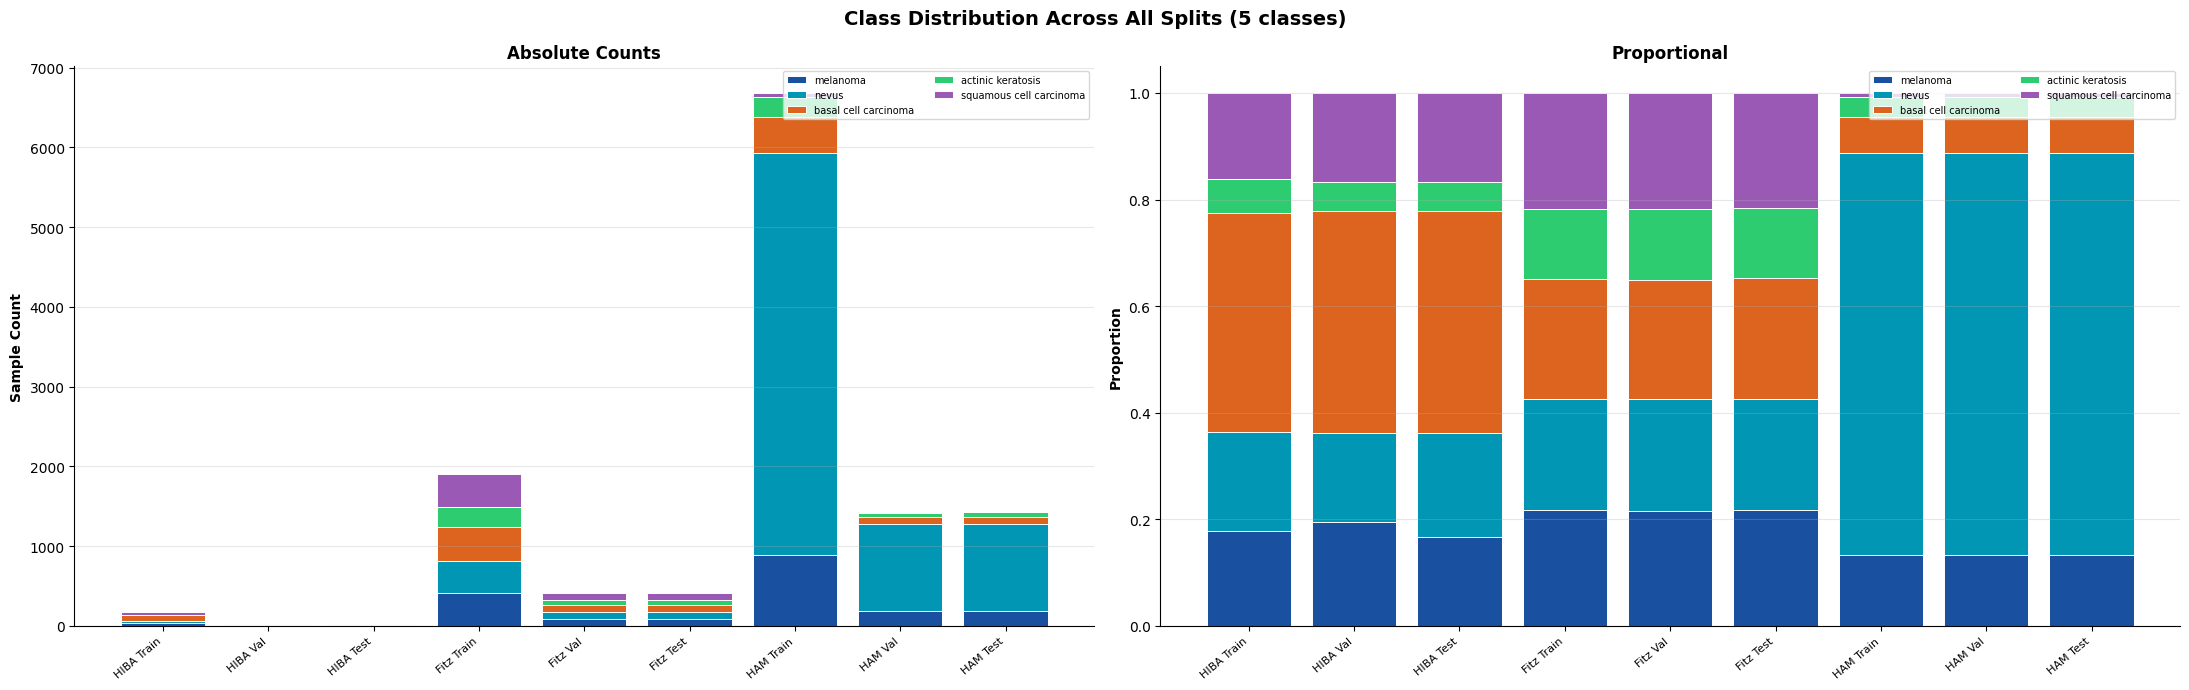

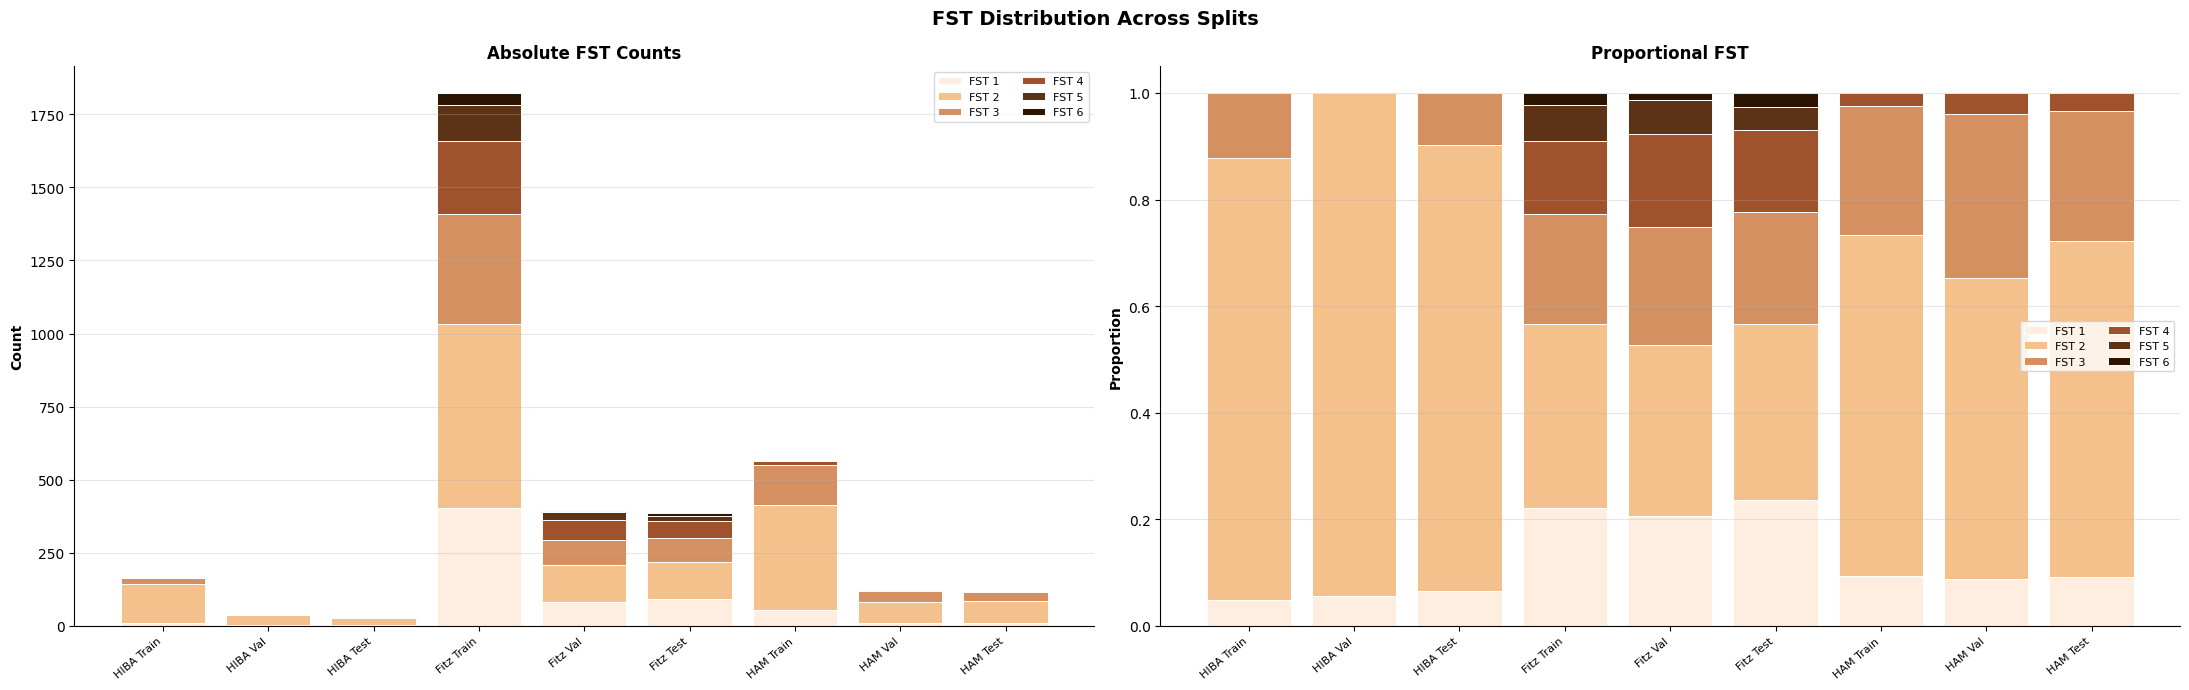

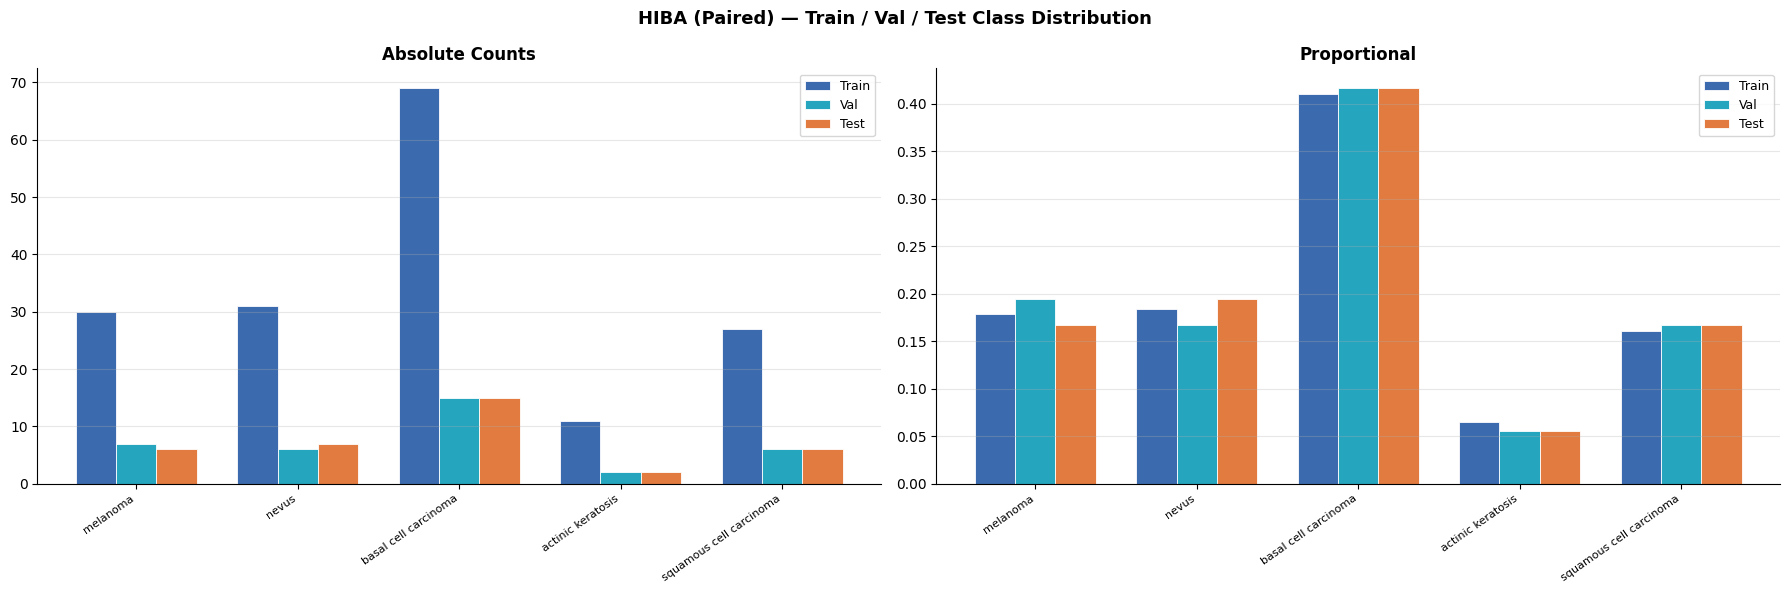

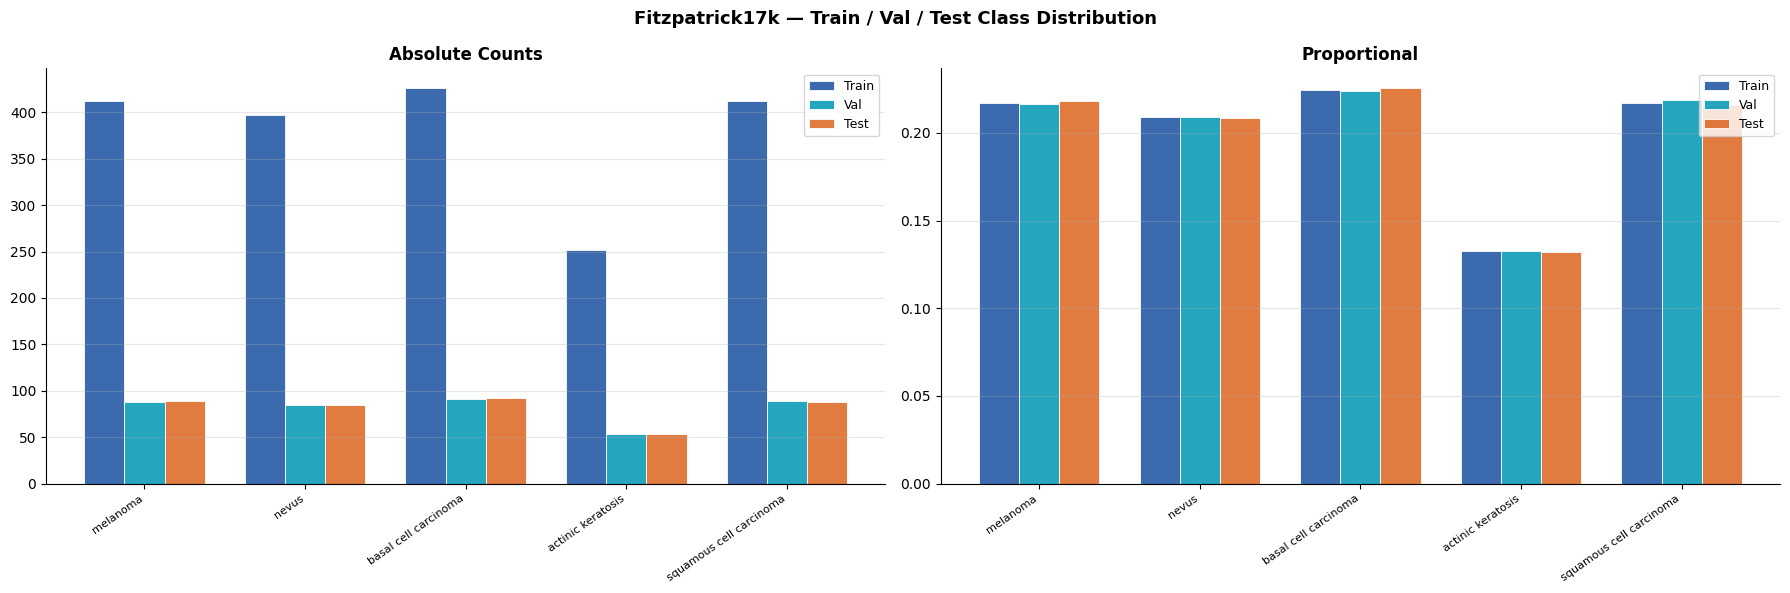

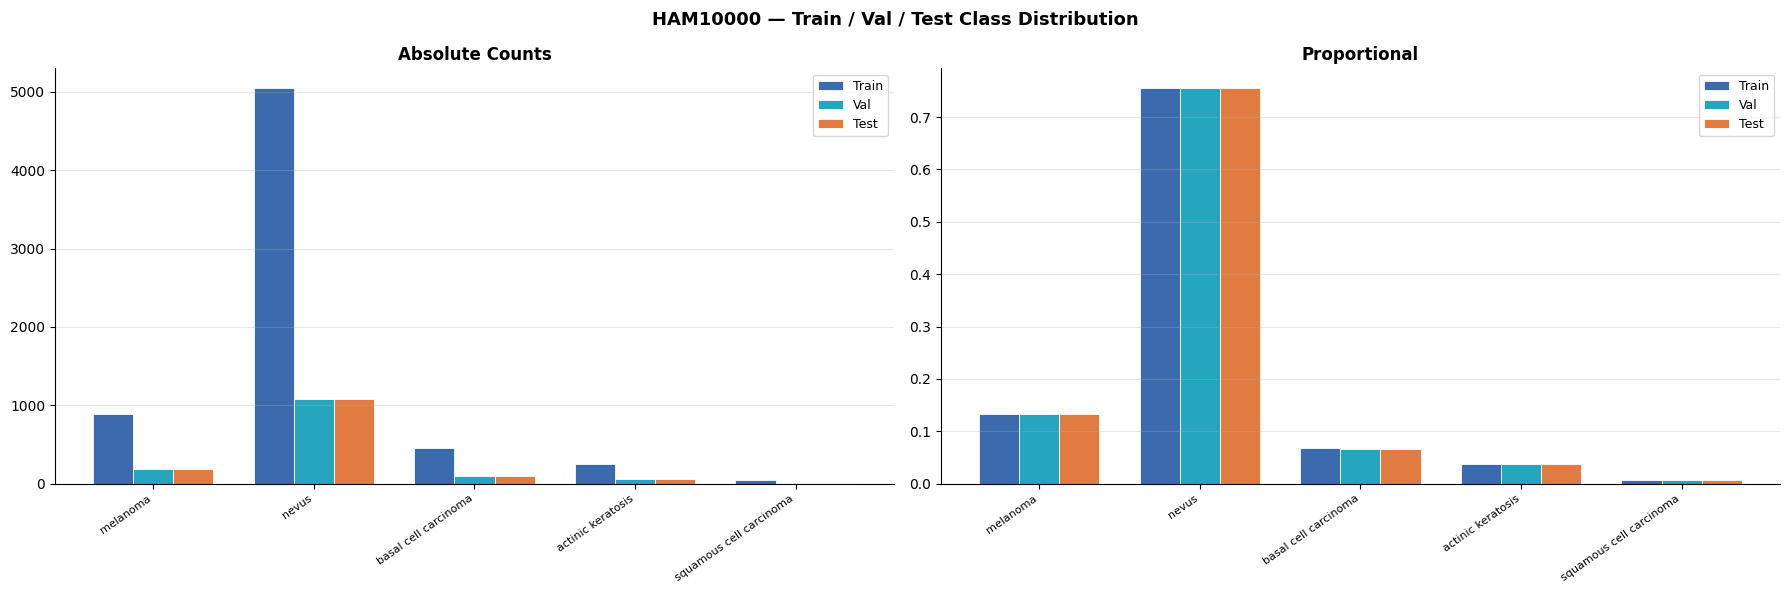

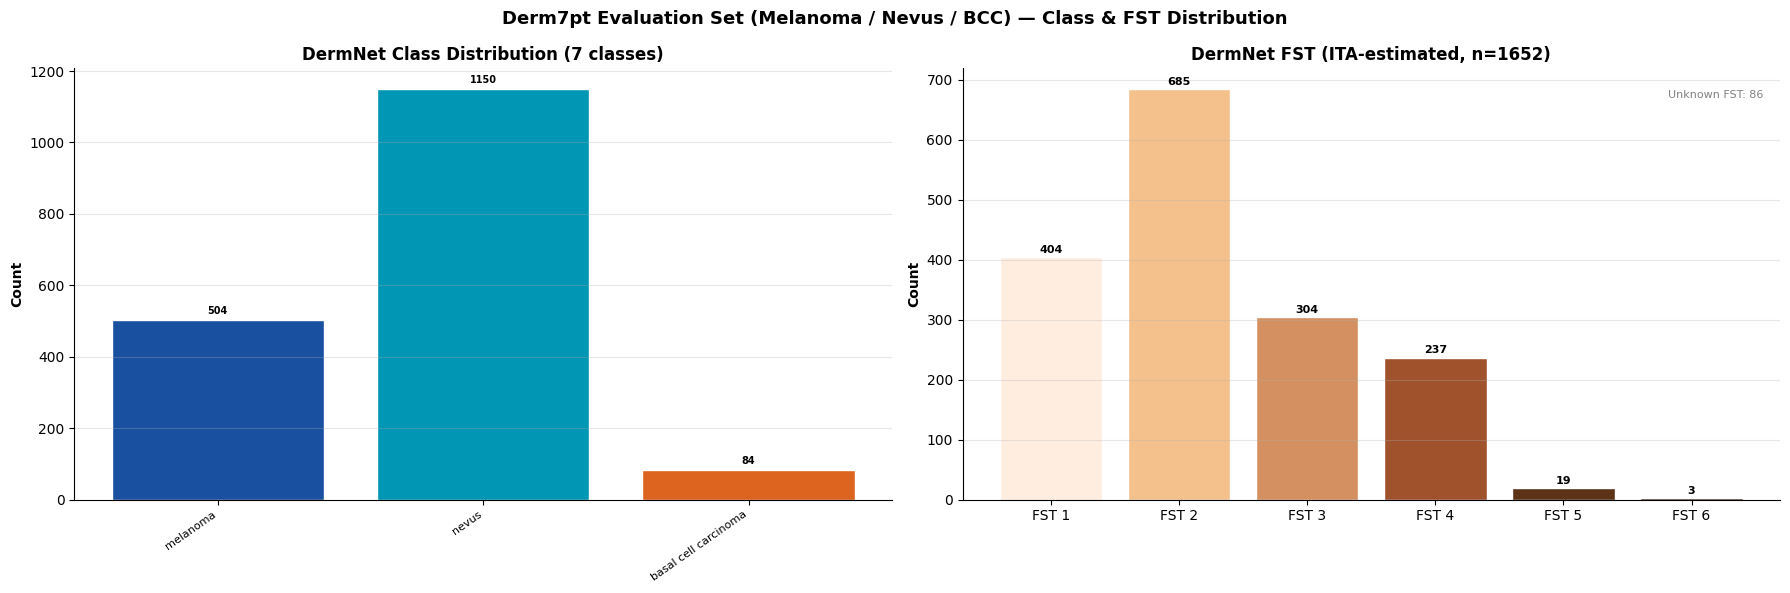

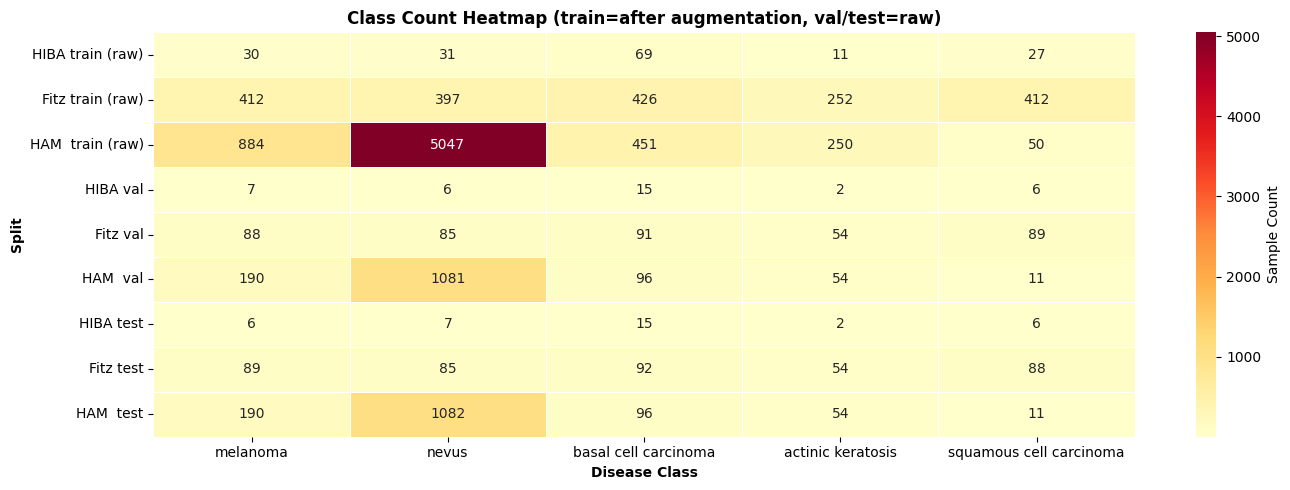


── Coverage Summary ─────────────────────────────────────
                Total rows  FST known  FST %  Class=Other Other %
Dataset                                                          
HIBA                   168        164  97.6%            0    0.0%
Fitzpatrick17k        1899       1823  96.0%            0    0.0%
HAM10000              6682        563   8.4%            0    0.0%
Derm7pt               1738       1652  95.1%            0    0.0%

EDA visualizations saved.


In [53]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — DATASET DISTRIBUTION VISUALIZATIONS  (7 classes)
# ════════════════════════════════════════════════════════════════════════════
import warnings as _w; _w.filterwarnings('ignore')

_LN  = LABEL_NAMES                          # {0:'melanoma', …, 6:'other'}
_LBL = [_LN[i] for i in range(5)]           # ordered list
_FST = {i: f'FST {i+1}' for i in range(6)}

_PAL_CLS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6']
_PAL_FST = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']

csv_dir = CFG['csv_dir']
def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# ── Load all splits ───────────────────────────────────────────────────────
_splits = {}
for tag, fname in [
    ('HIBA Train', 'paired_train.csv'), ('HIBA Val', 'paired_val.csv'),   ('HIBA Test', 'paired_test.csv'),
    ('Fitz Train', 'clin_train.csv'),   ('Fitz Val', 'clin_val.csv'),     ('Fitz Test', 'clin_test.csv'),
    ('HAM Train',  'derm_train.csv'),   ('HAM Val',  'derm_val.csv'),     ('HAM Test',  'derm_test.csv'),
]:
    d = _load(fname)
    if d.empty: continue
    # normalise clinical_path → image_path for paired sets
    if 'image_path' not in d.columns and 'clinical_path' in d.columns:
        d = d.rename(columns={'clinical_path': 'image_path'})
    _splits[tag] = d

_dermnet = _load('eval_derm7pt.csv')

# ──────────────────────────────────────────────────────────────────────────
# FIG 1  Class distribution across ALL splits (stacked absolute + proportional)
# ──────────────────────────────────────────────────────────────────────────
if _splits:
    _snames = list(_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Splits (5 classes)', fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames))
    bot_prop = np.zeros(len(_snames))
    totals = np.array([len(_splits[s]) for s in _snames], dtype=float)
    for ci in range(5):
        vals = np.array([_splits[s]['label'].value_counts().get(ci, 0) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 2  FST distribution (only splits with FST annotations)
# ──────────────────────────────────────────────────────────────────────────
_fst_splits = {s: d for s, d in _splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs))
    bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 3  Per-dataset train/val/test grouped bar (class counts)
# ──────────────────────────────────────────────────────────────────────────
for ds_name, prefix, cols in [
    ('HIBA (Paired)',  'HIBA', ['HIBA Train','HIBA Val','HIBA Test']),
    ('Fitzpatrick17k', 'Fitz', ['Fitz Train','Fitz Val','Fitz Test']),
    ('HAM10000',       'HAM',  ['HAM Train', 'HAM Val', 'HAM Test']),
]:
    dfs = {c: _splits[c] for c in cols if c in _splits}
    if not dfs: continue
    present_cls = sorted(set(c for d in dfs.values() for c in d['label'].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{ds_name} — Train / Val / Test Class Distribution', fontsize=13, fontweight='bold')
    split_labels = list(dfs.keys())
    x = np.arange(len(present_cls)); w = 0.25
    colors = ['#1950A0','#0096B4','#DC641E']
    for si, (sname, d) in enumerate(dfs.items()):
        cnts = [d['label'].value_counts().get(c, 0) for c in present_cls]
        axes[0].bar(x+(si-1)*w, cnts, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
        props = np.array(cnts, dtype=float)/max(sum(cnts),1)
        axes[1].bar(x+(si-1)*w, props, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
    for ax, title in [(axes[0],'Absolute Counts'),(axes[1],'Proportional')]:
        ax.set_xticks(x); ax.set_xticklabels([_LN.get(c,f'C{c}') for c in present_cls],
                                               rotation=35, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/f'eda_class_{prefix.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 4  DermNet class + FST (eval set)
# ──────────────────────────────────────────────────────────────────────────
if not _dermnet.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Derm7pt Evaluation Set (Melanoma / Nevus / BCC) — Class & FST Distribution', fontsize=13, fontweight='bold')
    vc = _dermnet['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i % 7] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index], vc.values,
                       color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01, str(n),
                     ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[0].set_title('DermNet Class Distribution (7 classes)', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index], rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)
    if 'skin_type' in _dermnet.columns:
        fst_k = _dermnet[_dermnet['skin_type'] >= 0]
        if not fst_k.empty:
            fst_ns = [(_dermnet['skin_type']==fi).sum() for fi in range(6)]
            b2 = axes[1].bar([_FST[fi] for fi in range(6)], fst_ns, color=_PAL_FST, edgecolor='white', lw=1)
            for bar, n in zip(b2, fst_ns):
                if n: axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                                   str(n), ha='center', fontsize=8, fontweight='bold')
            axes[1].set_title(f'DermNet FST (ITA-estimated, n={len(fst_k)})', fontweight='bold')
            axes[1].set_ylabel('Count', fontweight='bold')
            axes[1].text(0.98, 0.95, f'Unknown FST: {(_dermnet["skin_type"]<0).sum()}',
                         transform=axes[1].transAxes, ha='right', va='top', fontsize=8, color='grey')
            axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_derm7pt.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 5  Class imbalance heatmap — raw counts per (dataset × class)
# ──────────────────────────────────────────────────────────────────────────
_heatmap_splits = {
    'HIBA train (raw)':  pd.read_csv(csv_dir/'paired_train.csv') if (csv_dir/'paired_train.csv').exists() else pd.DataFrame(),
    'Fitz train (raw)':  pd.read_csv(csv_dir/'clin_train.csv')   if (csv_dir/'clin_train.csv').exists()   else pd.DataFrame(),
    'HAM  train (raw)':  pd.read_csv(csv_dir/'derm_train.csv')   if (csv_dir/'derm_train.csv').exists()   else pd.DataFrame(),
    'HIBA val':          pd.read_csv(csv_dir/'paired_val.csv')    if (csv_dir/'paired_val.csv').exists()  else pd.DataFrame(),
    'Fitz val':          pd.read_csv(csv_dir/'clin_val.csv')      if (csv_dir/'clin_val.csv').exists()      else pd.DataFrame(),
    'HAM  val':          pd.read_csv(csv_dir/'derm_val.csv')      if (csv_dir/'derm_val.csv').exists()      else pd.DataFrame(),
    'HIBA test':         pd.read_csv(csv_dir/'paired_test.csv')    if (csv_dir/'paired_test.csv').exists()  else pd.DataFrame(),
    'Fitz test':         pd.read_csv(csv_dir/'clin_test.csv')      if (csv_dir/'clin_test.csv').exists()      else pd.DataFrame(),
    'HAM  test':         pd.read_csv(csv_dir/'derm_test.csv')      if (csv_dir/'derm_test.csv').exists()      else pd.DataFrame(),
}
_hmap_data = {}
for name, d in _heatmap_splits.items():
    if d.empty: continue
    _hmap_data[name] = [d['label'].value_counts().get(ci, 0) for ci in range(5)]
if _hmap_data:
    import seaborn as sns
    _hm_df = pd.DataFrame(_hmap_data, index=[_LN[i] for i in range(5)]).T
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap (train=after augmentation, val/test=raw)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['results_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 6  Coverage summary: % images found + % FST known per dataset
# ──────────────────────────────────────────────────────────────────────────
_cov_rows = []
for tag, fname in [('HIBA','paired_train.csv'),('Fitzpatrick17k','clin_train.csv'),
                    ('HAM10000','derm_train.csv'),('Derm7pt','eval_derm7pt.csv')]:
    d = _load(fname)
    if d.empty: continue
    _img_col = 'image_path' if 'image_path' in d.columns else 'clinical_path'
    n_total  = len(d)
    n_fst    = int((d['skin_type'] >= 0).sum()) if 'skin_type' in d.columns else 0
    n_cls6   = int((d['label'] == 6).sum()) if 'label' in d.columns else 0
    _cov_rows.append({'Dataset': tag, 'Total rows': n_total,
                       'FST known': n_fst, 'FST %': f'{100*n_fst/max(n_total,1):.1f}%',
                       'Class=Other': n_cls6, 'Other %': f'{100*n_cls6/max(n_total,1):.1f}%'})
if _cov_rows:
    _cov_df = pd.DataFrame(_cov_rows).set_index('Dataset')
    print('\n── Coverage Summary ─────────────────────────────────────')
    print(_cov_df.to_string())
    _cov_df.to_csv(CFG['results_dir']/'eda_coverage_summary.csv')

print('\nEDA visualizations saved.')


In [54]:
# ════════════════════════════════════════════════════════════════════════════
# ONLINE DATA AUGMENTATION  (applied per-batch during training)
# ════════════════════════════════════════════════════════════════════════════
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

_AUG_P = CFG['aug_probability']   # probability gate for the full augmentation pipeline

# Individual transform probabilities (applied when the pipeline gate fires)
train_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size']+32, CFG['img_size']+32)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomApply([transforms.RandomRotation(30)],      p=0.6),
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.08)], p=0.7),
    transforms.RandomApply([transforms.GaussianBlur(
        kernel_size=5, sigma=(0.1, 2.0))],                       p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_tfm = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

denorm_tfm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/s for s in IMG_STD]),
    transforms.Normalize(mean=[-m for m in IMG_MEAN], std=[1,1,1]),
])


class UnpairedSkinDataset(Dataset):
    """Dataset for unpaired (single-modality) images.

    When train=True, augmentation is applied with probability aug_prob.
    When train=False (val/eval), only the deterministic val_tfm is applied.
    """
    def __init__(self, df_or_csv, modality='clinical', transform=None,
                 train=True, aug_prob=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv, (str, Path))
                   else df_or_csv.reset_index(drop=True))
        self.modality  = modality
        self.transform = transform
        self.train     = train
        self.aug_prob  = aug_prob if aug_prob is not None else CFG['aug_probability']

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            img = Image.open(r['image_path']).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))

        # Online augmentation: apply train_tfm with probability aug_prob,
        # otherwise apply val_tfm (deterministic resize+normalize only)
        if self.train and random.random() < self.aug_prob:
            img = train_tfm(img)
        else:
            img = val_tfm(img)

        return {
            'image'     : img,
            'label'     : torch.tensor(int(r['label']),     dtype=torch.long),
            'skin_type' : torch.tensor(int(r['skin_type']), dtype=torch.long),
            'modality'  : self.modality,
            'paired'    : False,
            'image_path': str(r['image_path']),
        }


class PairedSkinDataset(Dataset):
    """Dataset for paired (clinical + dermoscopic) images from HIBA."""
    def __init__(self, df_or_csv, transform=None, train=True, aug_prob=None):
        self.df = (pd.read_csv(df_or_csv) if isinstance(df_or_csv, (str, Path))
                   else df_or_csv.reset_index(drop=True))
        self.transform = transform
        self.train     = train
        self.aug_prob  = aug_prob if aug_prob is not None else CFG['aug_probability']

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        try:
            clin = Image.open(r['clinical_path']).convert('RGB')
            derm = Image.open(r['derm_path']).convert('RGB')
        except Exception:
            clin = derm = Image.new('RGB', (224, 224))

        # Both modalities get the same augmentation decision for consistency
        if self.train and random.random() < self.aug_prob:
            clin = train_tfm(clin)
            derm = train_tfm(derm)
        else:
            clin = val_tfm(clin)
            derm = val_tfm(derm)

        return {
            'clinical'  : clin,
            'derm'      : derm,
            'label'     : torch.tensor(int(r['label']),     dtype=torch.long),
            'skin_type' : torch.tensor(int(r['skin_type']), dtype=torch.long),
            'paired'    : True,
        }


class MixedDataset(Dataset):
    def __init__(self, paired_ds, unpaired_list):
        self.paired   = paired_ds
        self.unpaired = unpaired_list
        self.index = (
            [('p', i)    for i in range(len(paired_ds))] +
            [('u', di, i) for di, ds in enumerate(unpaired_list)
                          for i in range(len(ds))]
        )
    def __len__(self): return len(self.index)
    def __getitem__(self, i):
        e = self.index[i]
        return self.paired[e[1]] if e[0] == 'p' else self.unpaired[e[1]][e[2]]


def mixed_collate(batch):
    paired_items   = [item for item in batch if item.get('paired') is True]
    unpaired_items = [item for item in batch if item.get('paired') is not True]

    result = {}
    result['label']      = torch.stack([item['label']     for item in batch])
    result['skin_type']  = torch.stack([item['skin_type'] for item in batch])
    result['paired']     = [item['paired']                for item in batch]
    result['modality']   = [item.get('modality', 'clinical') for item in batch]
    result['image_path'] = [item.get('image_path', '')    for item in batch]

    if paired_items:
        result['clinical'] = torch.stack([item['clinical'] for item in paired_items])
        result['derm']     = torch.stack([item['derm']     for item in paired_items])
    if unpaired_items:
        result['image']    = torch.stack([item['image']    for item in unpaired_items])

    return result

print('Online augmentation + Dataset classes defined.')
print(f'  aug_probability = {CFG["aug_probability"]} (applied per-sample per-batch during training)')


Online augmentation + Dataset classes defined.
  aug_probability = 0.85 (applied per-sample per-batch during training)


In [55]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD DATA LOADERS
# ════════════════════════════════════════════════════════════════════════════
import pandas as _pd
from torch.utils.data import WeightedRandomSampler

def _safe_csv(path):
    p = Path(path)
    if not p.exists():
        print(f'  [WARN] CSV not found, skipping: {p.name}')
        return _pd.DataFrame()
    df = _pd.read_csv(p)
    if df.empty:
        print(f'  [WARN] CSV is empty, skipping: {p.name}')
    return df

csv = CFG['csv_dir']

# Paired (HIBA) — train with online aug, val without
_paired_tr = _safe_csv(csv/'paired_train.csv')
_paired_va = _safe_csv(csv/'paired_val.csv')
paired_tr_ds = PairedSkinDataset(_paired_tr, train=True)  if not _paired_tr.empty else None
paired_va_ds = PairedSkinDataset(_paired_va, train=False) if not _paired_va.empty else None

# Clinical unpaired (Fitzpatrick17k)
_clin_tr = _safe_csv(csv/'clin_train.csv')
_clin_va = _safe_csv(csv/'clin_val.csv')
clin_tr_ds  = UnpairedSkinDataset(_clin_tr, 'clinical', train=True)  if not _clin_tr.empty else None
clin_val_ds = UnpairedSkinDataset(_clin_va, 'clinical', train=False) if not _clin_va.empty else None

# Dermoscopic unpaired (HAM10000)
_derm_tr = _safe_csv(csv/'derm_train.csv')
derm_tr_ds = UnpairedSkinDataset(_derm_tr, 'derm', train=True) if not _derm_tr.empty else None

# Build mixed training dataset
_unpaired_list = [ds for ds in [clin_tr_ds, derm_tr_ds] if ds is not None]
assert _unpaired_list or paired_tr_ds is not None, \
    'No training data found — check that dataset CSVs were built in Phase 1.'

if paired_tr_ds is None:
    class _EmptyPaired(Dataset):
        def __len__(self): return 0
        def __getitem__(self, i): raise IndexError
    paired_tr_ds = _EmptyPaired()

train_ds = MixedDataset(paired_tr_ds, _unpaired_list)

# ── WeightedRandomSampler (fast, reads DataFrames) ───────────────────────
def _build_sampler_fast(paired_df, unpaired_dfs):
    all_labels = []
    if paired_df is not None and not paired_df.empty:
        all_labels.extend(paired_df['label'].astype(int).tolist())
    for df in unpaired_dfs:
        if df is not None and not df.empty:
            all_labels.extend(df['label'].astype(int).tolist())
    all_labels   = np.array(all_labels)
    class_counts = np.bincount(all_labels, minlength=CFG['num_classes']).astype(float)
    class_counts = np.where(class_counts == 0, 1, class_counts)
    weights      = 1.0 / class_counts[all_labels]
    return WeightedRandomSampler(
        weights=torch.from_numpy(weights).double(),
        num_samples=len(weights),
        replacement=True,
    )

print('  Building WeightedRandomSampler ...')
_paired_df_for_sampler    = _paired_tr if not _paired_tr.empty else None
_unpaired_dfs_for_sampler = [df for df in [_clin_tr, _derm_tr]
                              if df is not None and not df.empty]
_sampler = _build_sampler_fast(_paired_df_for_sampler, _unpaired_dfs_for_sampler)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    sampler=_sampler,
    collate_fn=mixed_collate,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=2,
)

# Validation loader
# IMPORTANT: include HIBA paired_val so all 5 classes are always represented.
# Fitzpatrick17k + HAM10000 val splits lack SCC (class 4), causing AUROC NaN.
_val_parts = []

# Add HIBA paired val (clinical + derm sides separately)
_pva = _safe_csv(csv/'paired_val.csv')
if not _pva.empty and 'clinical_path' in _pva.columns and 'derm_path' in _pva.columns:
    _pva_clin          = _pva[['label','skin_type']].copy()
    _pva_clin['image_path'] = _pva['clinical_path'].values
    _pva_derm          = _pva[['label','skin_type']].copy()
    _pva_derm['image_path'] = _pva['derm_path'].values
    _val_parts.append(UnpairedSkinDataset(_pva_clin, 'clinical', train=False))
    _val_parts.append(UnpairedSkinDataset(_pva_derm, 'derm',     train=False))
    print(f'  val: added {len(_pva)} HIBA paired val cases (clinical+derm)')

# Add Fitzpatrick17k clinical val
if clin_val_ds is not None:
    _val_parts.append(clin_val_ds)

# Add HAM10000 derm val
_derm_va = _safe_csv(csv/'derm_val.csv')
if not _derm_va.empty:
    _val_parts.append(UnpairedSkinDataset(_derm_va, 'derm', train=False))

assert _val_parts, 'No validation data found.'
from torch.utils.data import ConcatDataset as _ConcatDSval
_val_ds = _ConcatDSval(_val_parts) if len(_val_parts) > 1 else _val_parts[0]
print(f'  val_ds: {len(_val_parts)} part(s)  total={len(_val_ds)} samples')

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=mixed_collate,
    persistent_workers=True,
    prefetch_factor=2,
)

# Internal Test loader
_test_dfs = []
for _csv_f, _mod in [
        (csv/'paired_test.csv', 'clinical'),
        (csv/'clin_test.csv',   'clinical'),
        (csv/'derm_test.csv',   'derm'),
]:
    _d = _safe_csv(_csv_f)
    if not _d.empty:
        _test_dfs.append((_d, _mod))

if _test_dfs:
    _combined_test_dfs = []
    for _d, _mod in _test_dfs:
        if 'image_path' not in _d.columns and 'clinical_path' in _d.columns:
            _d = _d.rename(columns={'clinical_path': 'image_path'})
        _combined_test_dfs.append(UnpairedSkinDataset(_d, _mod, train=False))
    from torch.utils.data import ConcatDataset as _ConcatDS
    _test_combined = _ConcatDS(_combined_test_dfs)
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        collate_fn=mixed_collate,
        persistent_workers=True,
        prefetch_factor=2,
    )
    print(f'  internal test set: {len(_test_combined)} samples')
else:
    test_loader = None
    _test_combined = None
    print('  [WARN] No internal test CSVs found — test_loader is None')

# ── Cross-dataset eval loaders (Derm7pt only) ─────────────────────────────
eval_loaders = {}
_d7pt_csv = _safe_csv(csv/'eval_derm7pt.csv')
if not _d7pt_csv.empty:
    # Split by modality if column exists, else evaluate all together
    if 'modality' in _d7pt_csv.columns:
        for _mod in _d7pt_csv['modality'].unique():
            _d7pt_sub = _d7pt_csv[_d7pt_csv['modality'] == _mod].reset_index(drop=True)
            if not _d7pt_sub.empty:
                ds = UnpairedSkinDataset(_d7pt_sub, _mod, train=False)
                eval_loaders[f'derm7pt_{_mod}'] = DataLoader(
                    ds,
                    batch_size=CFG['batch_size'] * 2,
                    shuffle=False,
                    num_workers=4,
                    pin_memory=True,
                    collate_fn=mixed_collate,
                    persistent_workers=True,
                    prefetch_factor=2,
                )
                print(f'  eval [derm7pt_{_mod}]: {len(ds)} samples')
    else:
        ds = UnpairedSkinDataset(_d7pt_csv, 'clinical', train=False)
        eval_loaders['derm7pt'] = DataLoader(
            ds,
            batch_size=CFG['batch_size'] * 2,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            collate_fn=mixed_collate,
            persistent_workers=True,
            prefetch_factor=2,
        )
        print(f'  eval [derm7pt]: {len(ds)} samples')

print(f'\nTrain batches : {len(train_loader)}  |  Val batches: {len(val_loader)}')
print(f'Eval sets      : {list(eval_loaders.keys())}')
print('NOTE: online augmentation is applied during training (aug_probability='
      f'{CFG["aug_probability"]}), not during val/eval.')


  Building WeightedRandomSampler ...
  val: added 36 HIBA paired val cases (clinical+derm)
  val_ds: 4 part(s)  total=1911 samples
  internal test set: 1877 samples
  eval [derm7pt_derm]: 869 samples
  eval [derm7pt_clinical]: 869 samples

Train batches : 273  |  Val batches: 30
Eval sets      : ['derm7pt_derm', 'derm7pt_clinical']
NOTE: online augmentation is applied during training (aug_probability=0.85), not during val/eval.


## Phase 2 — Model Architecture

**FairDisCo** (Du et al. 2022, Figure 1c) grafted onto the dual-ResNet-18 backbone.

```
Clinical image  →  ResNet18_clin  →  z_c (512-d)  ─┐
                                                      ├→  z = avg(z_c, z_d) [paired]
Derm image      →  ResNet18_derm  →  z_d (512-d)  ─┘   or z_c / z_d [unpaired]

z  →  fc  (target branch)     →  p^c  →  Lcls
z  →  fs  (SA branch)         →  p^s  →  Lconf  (confuse backbone)
z (detached)  →  fs            →       →  Ls     (keep fs alive)
z  →  H   (contrastive head)  →  r    →  Lcontr (supervised contrastive)
```

Key differences from the modality-invariance notebook:
- **No shared projection head** — each encoder is independent (no cross-encoder weight sharing)
- **No LMI** — modality invariance loss is excluded; alignment arises only from Lcontr
- **H** is a 2-layer MLP (512→512→128) matching the FairDisCo paper
- **fs** is a 2-layer MLP (512→256→num_skin_types) matching paper's SA branch

In [56]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRDISCO DUAL-ENCODER MODEL  (dual ResNet-18 backbone)
# ════════════════════════════════════════════════════════════════════════════

def _load_resnet18_backbone(pretrained: bool = True) -> nn.Module:
    """ResNet-18 with FC replaced by Identity. Output: 512-d (global avg-pool)."""
    weights = ResNet18_Weights.DEFAULT if pretrained else None
    m = resnet18(weights=weights)
    m.fc = nn.Identity()
    return m

_RESNET18_FEAT_DIM = 512   # global avg-pool output dim


class ProjectionHead(nn.Module):
    """Contrastive projection head H: 512 → 512 → 128 (BN + ReLU).
    Matches FairDisCo paper: MLP with a single hidden layer of size 512,
    output size 128, no final normalisation (paper uses raw cosine similarity).
    """
    def __init__(self, in_dim=512, hidden_dim=512, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)   # raw (not L2-normalised) — cosine sim computed in loss


class SkinTypeClassifier(nn.Module):
    """Sensitive attribute (SA) branch fs: 512 → 256 → num_skin_types."""
    def __init__(self, in_dim=512, hidden_dim=256, num_skin_types=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_skin_types),
        )

    def forward(self, x):
        return self.net(x)


class FairDisCoModel(nn.Module):
    """Dual ResNet-18 + FairDisCo three-branch disentanglement.

    Two *independent* ResNet-18 encoders (one per modality) — no shared
    backbone weights. This matches the modality-invariant notebook's
    dual-encoder design while applying the FairDisCo objective.

    Branches (from paper Fig. 1c):
        fc   — target branch: Linear(512, num_classes)
        fs   — SA branch:     MLP(512→256→num_skin_types)
        H    — contrastive:   MLP(512→512→128)

    Forward returns:
        z            — shared embedding (avg of z_c,z_d for paired; single for unpaired)
        logits       — fc(z)    [Lcls]
        skin_logits  — fs(z)    [Lconf + Ls]
        proj         — H(z)     [Lcontr]
        z_c, z_d     — per-encoder embeddings (present only for paired inputs)
    """
    def __init__(self, embed_dim=512, proj_dim=128, num_classes=5,
                 num_skin_types=6, pretrained=True):
        super().__init__()
        # Independent encoders — one per modality
        self.clinical_enc = _load_resnet18_backbone(pretrained)
        self.derm_enc     = _load_resnet18_backbone(pretrained)

        # Target branch (fc)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embed_dim, num_classes),
        )
        # SA branch (fs) — trained with Lconf + Ls
        self.skin_clf = SkinTypeClassifier(embed_dim, 256, num_skin_types)
        # Contrastive projection head (H)
        self.proj_head = ProjectionHead(embed_dim, 512, proj_dim)

        total = sum(p.numel() for p in self.parameters()) / 1e6
        print(f'FairDisCoModel  backbone=2×resnet18  embed={embed_dim}  '
              f'proj={proj_dim}  params={total:.1f}M')

    def encode(self, x, modality):
        """Encode a single-modality image batch."""
        if modality == 'clinical':
            return self.clinical_enc(x)
        return self.derm_enc(x)

    def forward(self, batch):
        out = {}
        batch_size      = len(batch['label'])
        is_paired_flags = batch['paired']
        paired_mask     = torch.tensor(is_paired_flags, dtype=torch.bool,
                                       device=batch['label'].device)
        unpaired_mask   = ~paired_mask

        embeddings_full = torch.zeros(batch_size, _RESNET18_FEAT_DIM,
                              device=batch['label'].device,
                              dtype=torch.float32)   # explicit

        # ── Paired branch ──────────────────────────────────────────────────
        if paired_mask.any() and 'clinical' in batch and 'derm' in batch:
            clin_t = batch['clinical'].to(batch['label'].device)
            derm_t = batch['derm'].to(batch['label'].device)
            z_c = self.clinical_enc(clin_t)   # (B_p, 512)
            z_d = self.derm_enc(derm_t)        # (B_p, 512)
            z_paired = (z_c + z_d) / 2
            z_paired = z_paired.to(embeddings_full.dtype)
            embeddings_full[paired_mask] = z_paired
            out['z_c'] = z_c
            out['z_d'] = z_d

        # ── Unpaired branch ────────────────────────────────────────────────
        if unpaired_mask.any() and 'image' in batch:
            img_t = batch['image'].to(batch['label'].device)
            modality = 'clinical'
            for i, is_p in enumerate(is_paired_flags):
                if not is_p:
                    modality = batch['modality'][i]
                    break
            z_unpaired = self.encode(img_t, modality)
            z_unpaired = z_unpaired.to(embeddings_full.dtype)
            embeddings_full[unpaired_mask] = z_unpaired

        out['z']           = embeddings_full
        out['logits']      = self.classifier(out['z'])          # target branch
        out['skin_logits'] = self.skin_clf(out['z'])            # SA branch (full grad)
        out['proj']        = self.proj_head(out['z'])           # contrastive branch
        return out


def get_stage_lr_params(model, base_lr, lr_decay=0.85):
    """Stage-wise LR decay for dual ResNet-18.
    stem → layer1 → layer2 → layer3/4 get progressively higher LR.
    Head params (classifier, skin_clf, proj_head) get full base_lr.
    """
    stage_map = {
        'stem':   lr_decay ** 3,
        'layer1': lr_decay ** 2,
        'layer2': lr_decay ** 1,
        'layer3': lr_decay ** 0,
        'layer4': lr_decay ** 0,
    }
    _stem_kw = ('conv1', 'bn1')
    groups = {k: [] for k in stage_map}
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        placed = False
        for stage in ('layer1','layer2','layer3','layer4'):
            if f'.{stage}.' in name:
                groups[stage].append(param); placed = True; break
        if not placed:
            if ('clinical_enc.' in name or 'derm_enc.' in name) and any(k in name for k in _stem_kw):
                groups['stem'].append(param)
            else:
                head_params.append(param)
    param_groups = [{'params': head_params, 'lr': base_lr, 'name': 'heads'}]
    for stage, factor in stage_map.items():
        if groups[stage]:
            param_groups.append({'params': groups[stage], 'lr': base_lr * factor, 'name': stage})
    return param_groups


# ── Instantiate ──────────────────────────────────────────────────────────
model = FairDisCoModel(
    embed_dim      = CFG['embed_dim'],
    proj_dim       = CFG['proj_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Smoke-tests
with torch.no_grad():
    _t = model({'clinical'  : torch.randn(2,3,224,224).to(DEVICE),
                'derm'      : torch.randn(2,3,224,224).to(DEVICE),
                'label'     : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'skin_type' : torch.zeros(2,dtype=torch.long).to(DEVICE),
                'paired'    : [True,True]})
print('Paired  forward OK — logits:', _t['logits'].shape,
      ' proj:', _t['proj'].shape, ' skin_logits:', _t['skin_logits'].shape)

with torch.no_grad():
    _t2 = model({'image'    : torch.randn(2,3,224,224).to(DEVICE),
                 'label'    : torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'skin_type': torch.zeros(2,dtype=torch.long).to(DEVICE),
                 'paired'   : [False,False],
                 'modality' : ['clinical','clinical']})
print('Unpaired forward OK — logits:', _t2['logits'].shape)

FairDisCoModel  backbone=2×resnet18  embed=512  proj=128  params=22.8M
Paired  forward OK — logits: torch.Size([2, 5])  proj: torch.Size([2, 128])  skin_logits: torch.Size([2, 6])
Unpaired forward OK — logits: torch.Size([2, 5])


## Phase 3 — FairDisCo Loss Functions

Faithful implementation of Du et al. (2022), Equation 3:

$$L_{total} = L_{cls}(\theta_\phi, \theta_{f_c}) + \alpha \cdot L_{conf}(\theta_\phi, \theta_{f_s}) + L_s(\theta_{f_s}) + \beta \cdot L_{contr}(\theta_\phi, \theta_H)$$

| Loss | Branch | Gradient flows to | Purpose |
|------|--------|-------------------|---------|
| **Lcls** | target (fc) | backbone φ + fc | disease classification |
| **Lconf** | SA (fs) | backbone φ + fs | *confuse* backbone — remove FST from z |
| **Ls** | SA (fs) | fs **only** (z detached) | keep fs from collapsing to uniform |
| **Lcontr** | contrastive (H) | backbone φ + H | pull same-class embeddings together across FST |

**No LMI** — modality-invariance loss intentionally omitted.  
This isolates the FairDisCo contribution in the experimental comparison.

In [57]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRDISCO LOSS FUNCTIONS  (Du et al. 2022, models_losses.py)
# ════════════════════════════════════════════════════════════════════════════

# ── Class weights for Lcls ────────────────────────────────────────────────
def _compute_class_weights(csv_dir, n_classes=5):
    try:
        dfs = []
        for p in csv_dir.glob('*_train*.csv'):
            try: dfs.append(pd.read_csv(p, usecols=['label']))
            except Exception: pass
        if not dfs: return None
        labels = pd.concat(dfs)['label'].astype(int)
        counts = labels.value_counts().sort_index()
        freqs  = np.array([counts.get(i, 1) for i in range(n_classes)], dtype=float)
        beta_cb = 0.9999
        eff_num = (1.0 - beta_cb ** freqs) / (1.0 - beta_cb)
        weights = 1.0 / eff_num
        weights /= weights.sum() / n_classes
        print(f'  Class weights (effective-num, {n_classes} classes): {np.round(weights, 3)}')
        return weights.tolist()
    except Exception as e:
        print(f'  [WARN] Could not compute class weights: {e}'); return None

_class_weights = _compute_class_weights(CFG['csv_dir'], n_classes=CFG['num_classes'])
_weight_tensor = (torch.tensor(_class_weights, dtype=torch.float32).to(DEVICE)
                  if _class_weights is not None else None)


# ── Lcls — cross-entropy on skin condition (paper Eq. 3, θ_φ + θ_fc) ─────
def cls_loss_fn(logits, targets):
    """Standard weighted cross-entropy. Optional class weights for imbalance."""
    return F.cross_entropy(logits, targets, weight=_weight_tensor)


# ── Lconf — confusion loss (paper Eq. 1, θ_φ + θ_fs) ────────────────────
class ConfusionLoss(nn.Module):
    """Minimised when fs outputs uniform probability for all skin types.
    Backpropagates into backbone φ to remove FST information from z.
    Implementation from models_losses.py:
        loss = -mean_batch(mean_classes(log(softmax(skin_logits))))
    """
    def __init__(self):
        super().__init__()

    def forward(self, skin_logits):
        prediction  = F.softmax(skin_logits, dim=1)
        log_pred    = torch.log(prediction + 1e-8)
        loss        = -torch.mean(torch.mean(log_pred, dim=1), dim=0)
        return loss


# ── Ls — skin-type CE on DETACHED z (paper Eq. 3, θ_fs only) ─────────────
def skin_type_loss(skin_logits_detached, skin_labels):
    """CE on fs using detached embeddings — only fs parameters receive gradient.
    Filters out samples with unknown FST (skin_type == -1).
    Prevents fs from trivially satisfying Lconf by zeroing its weights.
    """
    valid = skin_labels >= 0
    if valid.sum() == 0:
        return skin_logits_detached.new_tensor(0.)
    return F.cross_entropy(skin_logits_detached[valid], skin_labels[valid])


# ── Lcontr — Supervised Contrastive Loss (paper Eq. 2, θ_φ + θ_H) ────────
class SupervisedContrastiveLoss(nn.Module):
    """Faithful port of Supervised_Contrastive_Loss from models_losses.py.

    For each anchor embedding r_i with target label y_i:
        positive set P_y  = {p : label[p] == label[i], p ≠ i}
        negative set N_y  = {n : label[n] != label[i]}

    Loss (Eq. 2):
        L_contr = -1/|P_y| * Σ_{p∈P_y} log[
            exp(cos(r_i, r_p)/τ) /
            (exp(cos(r_i, r_p)/τ) + Σ_{n∈N_y} exp(cos(r_i, r_n)/τ))
        ]

    Uses raw (non-L2-normalised) projections r — cosine_similarity handles
    the normalisation internally, matching models_losses.py.
    """
    def __init__(self, temperature=0.1):
        super().__init__()
        self.T = temperature

    def forward(self, projections, targets):
        # projections: (B, proj_dim), targets: (B,)
        B = projections.size(0)
        if B < 2:
            return projections.new_tensor(0.)

        # Cosine similarity matrix / τ  — (B, B)
        dot = F.cosine_similarity(
            projections.unsqueeze(1),   # (B,1,D)
            projections.unsqueeze(0),   # (1,B,D)
            dim=2
        ) / self.T

        # Numerical stability: subtract row-max
        dot_max, _ = dot.max(dim=1, keepdim=True)
        exp_dot = torch.exp(dot - dot_max.detach()) + 1e-5  # (B,B)

        # Masks
        mask_same_class = (targets.unsqueeze(1) == targets.unsqueeze(0))   # (B,B) bool
        mask_no_diag    = ~torch.eye(B, dtype=torch.bool, device=dot.device) # (B,B)
        mask_diff_class = ~mask_same_class                                   # (B,B)

        # mask_combined: same class, not self  [positive pairs]
        mask_combined   = mask_same_class & mask_no_diag

        # Denominator per row: exp(dot[i,p]) + Σ_{n∈N_y} exp(dot[i,n])
        neg_sum = (exp_dot * mask_diff_class).sum(dim=1, keepdim=True)      # (B,1)

        # log_prob[i,p] = dot[i,p] - dot_max - log(exp_dot[i,p] + neg_sum[i])
        log_prob = (dot - dot_max.detach()) - torch.log(exp_dot + neg_sum + 1e-5)

        # Sum log_prob over positives per anchor, average over anchors with ≥1 positive
        cardinality = mask_combined.sum(dim=1).float()   # (B,) num positives per anchor
        has_pos     = cardinality > 0
        if not has_pos.any():
            return projections.new_tensor(0.)

        per_anchor = (log_prob * mask_combined).sum(dim=1)   # (B,)
        loss = -(per_anchor[has_pos] / cardinality[has_pos]).mean()
        return loss


# ── Instantiate loss objects ──────────────────────────────────────────────
confusion_loss_fn  = ConfusionLoss()
sup_con_loss_fn    = SupervisedContrastiveLoss(temperature=CFG['temperature'])


# ── total_loss — FairDisCo objective (Eq. 3) ─────────────────────────────
def total_loss(out, batch, cfg, is_baseline=False):
    """Compute all FairDisCo loss components.

    Args:
        is_baseline: if True, only compute Lcls (for baseline training).

    Gradient routing:
        Lcls   → backbone φ + fc
        Lconf  → backbone φ + fs   (confuses backbone)
        Ls     → fs ONLY           (z detached, keeps fs alive)
        Lcontr → backbone φ + H
    """
    labels     = batch['label'].to(DEVICE)
    skin_types = batch['skin_type'].to(DEVICE)
    L = {}

    # ── Lcls (always) ────────────────────────────────────────────────────
    L['cls'] = cls_loss_fn(out['logits'], labels)
    tot = cfg['lambda_cls'] * L['cls'] if 'lambda_cls' in cfg else L['cls']

    if is_baseline:
        L['conf'] = out['logits'].new_tensor(0.)
        L['skin'] = out['logits'].new_tensor(0.)
        L['con']  = out['logits'].new_tensor(0.)
        L['total'] = tot
        return L

    # ── Lconf — confusion loss (θ_φ + θ_fs) ──────────────────────────────
    L['conf'] = confusion_loss_fn(out['skin_logits'])
    tot = tot + cfg['alpha'] * L['conf']

    # ── Ls — skin CE on detached z (θ_fs only) ───────────────────────────
    skin_logits_det = model.skin_clf(out['z'].detach())
    L['skin'] = skin_type_loss(skin_logits_det, skin_types)
    tot = tot + L['skin']

    # ── Lcontr — supervised contrastive (θ_φ + θ_H) ─────────────────────
    L['con'] = sup_con_loss_fn(out['proj'], labels)
    tot = tot + cfg['beta'] * L['con']

    L['total'] = tot
    return L


print('FairDisCo loss functions ready (Du et al. 2022, Eq. 3):')
print()
print('  Lcls   — Weighted cross-entropy on skin condition')
print('  Lconf  — Confusion loss: -mean(mean(log(softmax(skin_logits))))')
print('  Ls     — CE on fs with DETACHED z (prevents fs collapse)')
print('  Lcontr — Supervised contrastive (cosine sim / τ, τ =', CFG['temperature'], ')')
print('  [NO LMI] — modality invariance loss intentionally excluded')

  Class weights (effective-num, 5 classes): [0.645 0.19  0.887 1.601 1.678]
FairDisCo loss functions ready (Du et al. 2022, Eq. 3):

  Lcls   — Weighted cross-entropy on skin condition
  Lconf  — Confusion loss: -mean(mean(log(softmax(skin_logits))))
  Ls     — CE on fs with DETACHED z (prevents fs collapse)
  Lcontr — Supervised contrastive (cosine sim / τ, τ = 0.1 )
  [NO LMI] — modality invariance loss intentionally excluded


## Phase 4 — Training

### 4-A  Baseline Training (Lcls only)
Train a clean baseline with only cross-entropy loss. This establishes the
FATE denominator for the fairness-accuracy trade-off metric.

### 4-B  FairDisCo Training
Train the full FairDisCo objective on the same backbone and data splits.

In [58]:
# ════════════════════════════════════════════════════════════════════════════
# OPTIMIZER + SCHEDULER  (matching FairDisCo paper: Adam, StepLR step=2 γ=0.9)
# ════════════════════════════════════════════════════════════════════════════
import math

def build_optimizer_scheduler(mdl, cfg):
    """Build Adam + StepLR for a given model.
    Stage-wise LR decay applied to backbone layers (from CNN notebook).
    Paper: lr=1e-4, StepLR(step_size=2, gamma=0.9).
    """
    _lr_params = get_stage_lr_params(mdl, base_lr=cfg['lr'], lr_decay=0.85)
    opt = torch.optim.Adam(
        _lr_params,
        lr=cfg['lr'],
        weight_decay=cfg['weight_decay'],
    )
    # StepLR: matches FairDisCo paper
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=2, gamma=0.9)
    return opt, sched

optimizer, scheduler = build_optimizer_scheduler(model, CFG)
print(f'Optimizer : Adam  lr={CFG["lr"]}  weight_decay={CFG["weight_decay"]}')
print(f'Scheduler : StepLR  step_size=2  gamma=0.9  (paper default)')

Optimizer : Adam  lr=0.0001  weight_decay=0.0
Scheduler : StepLR  step_size=2  gamma=0.9  (paper default)


In [59]:
# ── robust_macro_auroc ────────────────────────────────────────────────────

def robust_macro_auroc(probs, labels):
    present = np.unique(labels)
    if len(present) < 2:
        return float('nan')

    aucs = []
    for c in range(probs.shape[1]):          # iterate all output classes
        if c not in present:
            continue                          # class unseen → skip
        binary_labels = (labels == c).astype(int)
        # Every other class is a negative — guaranteed at least one pos + one neg
        if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
            continue                          # degenerate (shouldn't happen now)
        try:
            auc = roc_auc_score(binary_labels, probs[:, c])
            aucs.append(float(auc))
        except Exception as e:
            print(f'  [robust_macro_auroc] class {c}: {e}')
    return float(np.mean(aucs)) if aucs else float('nan')


# ════════════════════════════════════════════════════════════════════════════
# TRAIN EPOCH + VALIDATE  (tqdm progress bars, AMP, grad clip)
# ════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (precision_score, recall_score,
                              confusion_matrix as sk_confusion_matrix)

# Mixed-precision scaler (speeds up ViT-Base on T4/A100)
_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(mdl, loader, opt, cfg, epoch):
    """One full training epoch — returns dict of mean losses + acc/F1."""
    mdl.train()
    totals    = dict(total=0., cls=0., conf=0., skin=0., con=0., mi=0.)
    all_preds, all_labels = [], []
    n_batches = 0

    bar = tqdm(loader, desc=f'Ep {epoch+1:>3} [train]',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
            L   = total_loss(out, batch, cfg)

        _scaler.scale(L['total']).backward()
        _scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=1.0)
        _scaler.step(opt)
        _scaler.update()

        for k in totals:
            totals[k] += float(L[k].detach())
        n_batches += 1

        bar.set_postfix(
            loss=f'{totals["total"]/n_batches:.4f}',
            cls =f'{totals["cls"] /n_batches:.4f}',
            conf=f'{totals["conf"]/n_batches:.4f}',
            Ls  =f'{totals["skin"]/n_batches:.4f}',
            mi  =f'{totals["mi"]  /n_batches:.4f}',
        )

        with torch.no_grad():
            preds = out['logits'].argmax(dim=1).cpu().numpy()
        all_preds .append(preds)
        all_labels.append(batch['label'].cpu().numpy())

    bar.close()

    for k in totals:
        totals[k] /= max(n_batches, 1)

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    totals['acc']      = float((all_preds == all_labels).mean())
    totals['macro_f1'] = float(f1_score(all_labels, all_preds,
                                        average='macro', zero_division=0))
    return totals


@torch.no_grad()
def validate(mdl, loader, desc='[val]'):
    mdl.eval()
    all_probs, all_labels, all_skins = [], [], []

    bar = tqdm(loader, desc=f'          {desc}',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
        probs = F.softmax(out['logits'], dim=-1).cpu().numpy()
        all_probs .append(probs)
        all_labels.append(batch['label'].cpu().numpy())
        all_skins .append(batch['skin_type'].cpu().numpy())
        # Live update: show class coverage so far
        _seen = len(np.unique(np.concatenate(all_labels)))
        bar.set_postfix(classes_seen=_seen)

    bar.close()

    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    skins  = np.concatenate(all_skins)
    preds  = probs.argmax(axis=1)

    # Warn if any expected class is missing from val labels
    present = set(np.unique(labels).tolist())
    missing = set(range(CFG['num_classes'])) - present
    if missing:
        missing_names = [LABEL_NAMES.get(c, str(c)) for c in sorted(missing)]
        tqdm.write(f'  [validate] classes absent from val labels: '
                   f'{missing_names} — AUROC computed over {sorted(present)} only')

    acc         = float((preds == labels).mean())
    auroc       = robust_macro_auroc(probs, labels)
    macro_f1    = float(f1_score(labels, preds, average='macro',    zero_division=0))
    weighted_f1 = float(f1_score(labels, preds, average='weighted', zero_division=0))
    macro_prec  = float(precision_score(labels, preds, average='macro',    zero_division=0))
    macro_rec   = float(recall_score(   labels, preds, average='macro',    zero_division=0))
    per_class_prec = precision_score(labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_rec  = recall_score(   labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    per_class_f1   = f1_score(       labels, preds, average=None, zero_division=0,
                                     labels=list(range(CFG['num_classes'])))
    conf_mat = sk_confusion_matrix(labels, preds,
                                   labels=list(range(CFG['num_classes'])))

    return {
        'acc': acc, 'auroc': auroc,
        'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
        'macro_prec': macro_prec, 'macro_rec': macro_rec,
        'micro_f1': float(f1_score(labels, preds, average='micro', zero_division=0)),
        'weighted_prec': float(precision_score(labels, preds, average='weighted', zero_division=0)),
        'weighted_rec':  float(recall_score(   labels, preds, average='weighted', zero_division=0)),
        'per_class_prec': per_class_prec,
        'per_class_rec':  per_class_rec,
        'per_class_f1':   per_class_f1,
        'conf_mat': conf_mat,
        'probs': probs, 'preds': preds,
        'labels': labels, 'skin': skins,
    }

print('train_epoch() and validate() ready.')
print('  robust_macro_auroc: per-class OvR binary AUC — never NaN when ≥2 classes present.')
print('  Mixed-precision (AMP):', torch.cuda.is_available())
print('  Gradient clipping: max_norm=1.0')


train_epoch() and validate() ready.
  robust_macro_auroc: per-class OvR binary AUC — never NaN when ≥2 classes present.
  Mixed-precision (AMP): True
  Gradient clipping: max_norm=1.0


In [60]:
# ════════════════════════════════════════════════════════════════════════════
# TRAIN EPOCH + VALIDATE  (FairDisCo-aware)
# ════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, confusion_matrix as sk_confusion_matrix

_scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(mdl, loader, opt, cfg, epoch, is_baseline=False):
    """One training epoch. is_baseline=True disables aux losses."""
    mdl.train()
    totals    = dict(total=0., cls=0., conf=0., skin=0., con=0.)
    all_preds, all_labels = [], []
    n_batches = 0

    tag = 'BASE' if is_baseline else 'FDC'
    bar = tqdm(loader, desc=f'Ep {epoch+1:>3} [{tag}]',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
            L   = total_loss(out, batch, cfg, is_baseline=is_baseline)

        _scaler.scale(L['total']).backward()
        _scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=2.0)
        _scaler.step(opt)
        _scaler.update()

        for k in totals:
            totals[k] += float(L[k].detach())
        n_batches += 1

        bar.set_postfix(
            loss=f'{totals["total"]/n_batches:.4f}',
            cls =f'{totals["cls"] /n_batches:.4f}',
            conf=f'{totals["conf"]/n_batches:.4f}',
            con =f'{totals["con"] /n_batches:.4f}',
        )
        with torch.no_grad():
            preds = out['logits'].argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(batch['label'].cpu().numpy())

    bar.close()
    for k in totals: totals[k] /= max(n_batches, 1)
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    from sklearn.metrics import f1_score as _f1
    totals['acc']      = float((all_preds == all_labels).mean())
    totals['macro_f1'] = float(_f1(all_labels, all_preds, average='macro', zero_division=0))
    return totals


@torch.no_grad()
def validate(mdl, loader, desc='[val]'):
    mdl.eval()
    all_probs, all_labels, all_skins = [], [], []

    bar = tqdm(loader, desc=f'          {desc}',
               unit='batch', dynamic_ncols=True, leave=False)

    for batch in bar:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor):
                batch[k] = v.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = mdl(batch)
        probs = F.softmax(out['logits'], dim=-1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(batch['label'].cpu().numpy())
        all_skins.append(batch['skin_type'].cpu().numpy())
        bar.set_postfix(classes_seen=len(np.unique(np.concatenate(all_labels))))
    bar.close()

    from sklearn.metrics import f1_score as _f1, precision_score as _prec, recall_score as _rec
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    skins  = np.concatenate(all_skins)
    preds  = probs.argmax(axis=1)

    present = set(np.unique(labels).tolist())
    missing = set(range(CFG['num_classes'])) - present
    if missing:
        tqdm.write(f'  [val] absent classes: {[LABEL_NAMES.get(c,str(c)) for c in sorted(missing)]}')

    return {
        'acc'          : float((preds == labels).mean()),
        'auroc'        : robust_macro_auroc(probs, labels),
        'macro_f1'     : float(_f1(labels, preds, average='macro',    zero_division=0)),
        'weighted_f1'  : float(_f1(labels, preds, average='weighted', zero_division=0)),
        'micro_f1'     : float(_f1(labels, preds, average='micro',    zero_division=0)),
        'macro_prec'   : float(_prec(labels, preds, average='macro',    zero_division=0)),
        'macro_rec'    : float(_rec( labels, preds, average='macro',    zero_division=0)),
        'weighted_prec': float(_prec(labels, preds, average='weighted', zero_division=0)),
        'weighted_rec' : float(_rec( labels, preds, average='weighted', zero_division=0)),
        'per_class_prec': _prec(labels, preds, average=None, zero_division=0,
                                labels=list(range(CFG['num_classes']))),
        'per_class_rec' : _rec( labels, preds, average=None, zero_division=0,
                                labels=list(range(CFG['num_classes']))),
        'per_class_f1'  : _f1(  labels, preds, average=None, zero_division=0,
                                labels=list(range(CFG['num_classes']))),
        'conf_mat': sk_confusion_matrix(labels, preds,
                                        labels=list(range(CFG['num_classes']))),
        'probs': probs, 'preds': preds, 'labels': labels, 'skin': skins,
    }

print('train_epoch() and validate() ready.')
print('  AMP:', torch.cuda.is_available(), '  grad_clip: max_norm=2.0')

train_epoch() and validate() ready.
  AMP: True   grad_clip: max_norm=2.0


In [61]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 4-A — BASELINE TRAINING  (Lcls only, for FATE reference)
# ════════════════════════════════════════════════════════════════════════════
import sys, json as _json, shutil as _shutil

# Checkpoint paths for the BASELINE
_BASE_CKPT_DIR = CFG['ckpt_dir'] / 'baseline'
_BASE_CKPT_DIR.mkdir(parents=True, exist_ok=True)
base_best_ckpt    = _BASE_CKPT_DIR / 'best_model.pt'
base_best_f1_ckpt = _BASE_CKPT_DIR / 'best_f1_model.pt'
base_last_ckpt    = _BASE_CKPT_DIR / 'last_model.pt'
base_hist_path    = CFG['results_dir'] / 'history_baseline.json'

BASE_EPOCHS = 20   # shorter run — baseline does not need long training

# Build a fresh identical model for the baseline
baseline_model = FairDisCoModel(
    embed_dim      = CFG['embed_dim'],
    proj_dim       = CFG['proj_dim'],
    num_classes    = CFG['num_classes'],
    num_skin_types = CFG['num_skin_types'],
    pretrained     = True,
).to(DEVICE)

# Use same optimiser family (Adam + StepLR) at same LR
base_optimizer, base_scheduler = build_optimizer_scheduler(baseline_model, CFG)

# Rebuild val loader with num_workers=0 for safety
_base_val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)

print(f'Starting BASELINE training ({BASE_EPOCHS} epochs, Lcls only) ...')
base_history   = defaultdict(list)
base_best_auroc = 0.0
base_best_f1    = 0.0

base_epoch_bar = tqdm(range(BASE_EPOCHS), desc='Baseline', unit='epoch', dynamic_ncols=True)

for epoch in base_epoch_bar:
    tm = train_epoch(baseline_model, train_loader, base_optimizer, CFG, epoch,
                     is_baseline=True)
    base_scheduler.step()
    vr = validate(baseline_model, _base_val_loader, desc='[base-val]')
    lr = base_optimizer.param_groups[0]['lr']

    for k, v in tm.items():
        base_history[f'train_{k}'].append(float(v))
    for k in ['acc','auroc','macro_f1','weighted_f1']:
        base_history[f'val_{k}'].append(float(vr[k]) if not isinstance(vr[k],float) else vr[k])
    base_history['lr'].append(float(lr))

    _auroc_str = f'{vr["auroc"]:.4f}' if not (isinstance(vr["auroc"],float) and vr["auroc"]!=vr["auroc"]) else 'nan'
    base_epoch_bar.set_postfix(
        loss=f'{tm["total"]:.4f}',
        v_acc=f'{vr["acc"]:.4f}',
        v_auc=_auroc_str,
        v_f1=f'{vr["macro_f1"]:.4f}',
    )
    tqdm.write(f'[BASE] Ep {epoch+1:>3}/{BASE_EPOCHS}  loss={tm["total"]:.4f}  '
               f'val_acc={vr["acc"]:.4f}  val_auroc={_auroc_str}  '
               f'val_f1={vr["macro_f1"]:.4f}  lr={lr:.2e}')

    _ckpt = {'epoch':epoch,'model':baseline_model.state_dict(),
              'optimizer':base_optimizer.state_dict(),
              'scheduler':base_scheduler.state_dict(),'history':dict(base_history)}
    torch.save(_ckpt, base_last_ckpt)
    if not np.isnan(vr['auroc']) and vr['auroc'] > base_best_auroc:
        base_best_auroc = vr['auroc']
        _shutil.copy(base_last_ckpt, base_best_ckpt)
    if vr['macro_f1'] > base_best_f1:
        base_best_f1 = vr['macro_f1']
        _shutil.copy(base_last_ckpt, base_best_f1_ckpt)
    with open(base_hist_path,'w') as _hf:
        _json.dump({k:[round(float(x),6) for x in v] for k,v in base_history.items()},_hf,indent=2)
    sys.stdout.flush()

print(f'\nBaseline training complete.')
print(f'  Best AUROC  : {base_best_auroc:.4f}')
print(f'  Best macro-F1: {base_best_f1:.4f}')
print(f'  Checkpoints → {_BASE_CKPT_DIR}')

FairDisCoModel  backbone=2×resnet18  embed=512  proj=128  params=22.8M
Starting BASELINE training (20 epochs, Lcls only) ...


Baseline:   0%|          | 0/20 [00:00<?, ?epoch/s]

Ep   1 [BASE]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [base-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[BASE] Ep   1/20  loss=0.9886  val_acc=0.6975  val_auroc=0.9115  val_f1=0.5813  lr=1.00e-04


...

          [base-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[BASE] Ep  19/20  loss=0.2464  val_acc=0.7771  val_auroc=0.9375  val_f1=0.6999  lr=3.87e-05


Ep  20 [BASE]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [base-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[BASE] Ep  20/20  loss=0.2474  val_acc=0.7949  val_auroc=0.9372  val_f1=0.7055  lr=3.49e-05

Baseline training complete.
  Best AUROC  : 0.9480
  Best macro-F1: 0.7058
  Checkpoints → /kaggle/working/checkpoints/baseline


In [62]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 4-B — FAIRDISCO TRAINING  (full Lcls + Lconf + Ls + Lcontr)
# ════════════════════════════════════════════════════════════════════════════

# Checkpoint paths for FairDisCo
_FDC_CKPT_DIR = CFG['ckpt_dir'] / 'fairdisco'
_FDC_CKPT_DIR.mkdir(parents=True, exist_ok=True)
best_ckpt    = _FDC_CKPT_DIR / 'best_model.pt'
best_f1_ckpt = _FDC_CKPT_DIR / 'best_f1_model.pt'
last_ckpt    = _FDC_CKPT_DIR / 'last_model.pt'
hist_path    = CFG['results_dir'] / 'history_fairdisco.json'

PERIODIC_SAVE_EVERY = 5

# ── Resume detection ──────────────────────────────────────────────────────
_resume_candidates = sorted(_FDC_CKPT_DIR.glob('checkpoint_ep*.pt'))
if _resume_candidates:
    _rp   = _resume_candidates[-1]
    _rc   = torch.load(_rp, map_location=DEVICE, weights_only=False)
    model.load_state_dict(_rc['model'])
    optimizer.load_state_dict(_rc['optimizer'])
    scheduler.load_state_dict(_rc['scheduler'])
    history     = defaultdict(list, _rc['history'])
    start_epoch = _rc['epoch'] + 1
    best_auroc  = max(history.get('val_auroc',  [0.0]), default=0.0)
    best_f1     = max(history.get('val_macro_f1',[0.0]), default=0.0)
    print(f'Resuming from {_rp.name}  (epoch {start_epoch+1}/{CFG["num_epochs"]})  '
          f'best_auroc={best_auroc:.4f}  best_f1={best_f1:.4f}')
else:
    history     = defaultdict(list)
    start_epoch = 0
    best_auroc  = 0.0
    best_f1     = 0.0
    print(f'Starting FairDisCo training from scratch — '
          f'{CFG["num_epochs"]} epochs  alpha={CFG["alpha"]}  beta={CFG["beta"]}')

# Rebuild val loader for FairDisCo training
fdc_val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=4, pin_memory=True,
    collate_fn=mixed_collate,
    persistent_workers=True, prefetch_factor=2,
)

epoch_bar = tqdm(range(start_epoch, CFG['num_epochs']),
                 desc='FairDisCo', unit='epoch',
                 dynamic_ncols=True, initial=start_epoch, total=CFG['num_epochs'])

for epoch in epoch_bar:
    tm = train_epoch(model, train_loader, optimizer, CFG, epoch, is_baseline=False)
    scheduler.step()
    vr = validate(model, fdc_val_loader, desc='[fdc-val]')
    lr = optimizer.param_groups[0]['lr']

    for k, v in tm.items():
        history[f'train_{k}'].append(float(v))
    for k in ['acc','auroc','macro_f1','weighted_f1']:
        history[f'val_{k}'].append(float(vr[k]) if not isinstance(vr[k],float) else vr[k])
    history['lr'].append(float(lr))

    _auroc_str = f'{vr["auroc"]:.4f}' if not (isinstance(vr["auroc"],float) and vr["auroc"]!=vr["auroc"]) else 'nan'
    epoch_bar.set_postfix(
        loss =f'{tm["total"]:.4f}',
        conf =f'{tm["conf"]:.4f}',
        con  =f'{tm["con"]:.4f}',
        v_acc=f'{vr["acc"]:.4f}',
        v_f1 =f'{vr["macro_f1"]:.4f}',
    )
    tqdm.write(
        f'[FDC] Ep {epoch+1:>3}/{CFG["num_epochs"]}  '
        f'loss={tm["total"]:.4f}  Lconf={tm["conf"]:.4f}  Lcon={tm["con"]:.4f}  '
        f'val_acc={vr["acc"]:.4f}  val_auroc={_auroc_str}  '
        f'val_f1={vr["macro_f1"]:.4f}  lr={lr:.2e}'
    )
    sys.stdout.flush()

    _ckpt_state = {
        'epoch'    : epoch,
        'model'    : model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'history'  : dict(history),
    }
    torch.save(_ckpt_state, last_ckpt)
    if not np.isnan(vr['auroc']) and vr['auroc'] > best_auroc:
        best_auroc = vr['auroc']
        _shutil.copy(last_ckpt, best_ckpt)
        print(f'  ✓  Best AUROC  (AUROC={best_auroc:.4f})')
    if vr['macro_f1'] > best_f1:
        best_f1 = vr['macro_f1']
        _shutil.copy(last_ckpt, best_f1_ckpt)
        print(f'  ✓  Best F1     (macro_F1={best_f1:.4f})')
    if (epoch+1) % PERIODIC_SAVE_EVERY == 0:
        _pp = _FDC_CKPT_DIR / f'checkpoint_ep{epoch+1:03d}.pt'
        torch.save(_ckpt_state, _pp)
        for _old in sorted(_FDC_CKPT_DIR.glob('checkpoint_ep*.pt'))[:-2]:
            _old.unlink()
    with open(hist_path,'w') as _hf:
        _json.dump({k:[round(float(x),6) for x in v] for k,v in history.items()},_hf,indent=2)
    sys.stdout.flush()

print(f'\nFairDisCo training complete.')
print(f'  Best AUROC   : {best_auroc:.4f}')
print(f'  Best macro-F1: {best_f1:.4f}')
print(f'  History saved → {hist_path}')

Starting FairDisCo training from scratch — 100 epochs  alpha=1.0  beta=0.8


FairDisCo:   0%|          | 0/100 [00:00<?, ?epoch/s]

Ep   1 [FDC]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [fdc-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[FDC] Ep   1/100  loss=6.7070  Lconf=1.8716  Lcon=2.8338  val_acc=0.6954  val_auroc=0.9100  val_f1=0.5581  lr=1.00e-04
  ✓  Best AUROC  (AUROC=0.9100)
  ✓  Best F1     (macro_F1=0.5581)


...

          [fdc-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[FDC] Ep  99/100  loss=3.8723  Lconf=1.8753  Lcon=0.4682  val_acc=0.8357  val_auroc=0.9528  val_f1=0.7347  lr=5.73e-07


Ep 100 [FDC]:   0%|          | 0/273 [00:00<?, ?batch/s]

          [fdc-val]:   0%|          | 0/30 [00:00<?, ?batch/s]

[FDC] Ep 100/100  loss=3.8353  Lconf=1.8742  Lcon=0.4282  val_acc=0.8331  val_auroc=0.9556  val_f1=0.7426  lr=5.15e-07

FairDisCo training complete.
  Best AUROC   : 0.9604
  Best macro-F1: 0.7535
  History saved → /kaggle/working/results/history_fairdisco.json


In [63]:
# ════════════════════════════════════════════════════════════════════════════
# REBUILD EVAL LOADERS  (num_workers=0, no persistent workers)
# ════════════════════════════════════════════════════════════════════════════

val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
    collate_fn=mixed_collate,
)

if test_loader is not None and _test_combined is not None:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=mixed_collate,
    )

# Rebuild Derm7pt eval loaders
# Rebuild eval loaders (num_workers=0 for post-training safety)
eval_loaders = {}
_d7pt_csv = _safe_csv(csv/'eval_derm7pt.csv')
if not _d7pt_csv.empty:
    if 'modality' in _d7pt_csv.columns:
        for _mod in _d7pt_csv['modality'].unique():
            _d7pt_sub = _d7pt_csv[_d7pt_csv['modality'] == _mod].reset_index(drop=True)
            if not _d7pt_sub.empty:
                ds = UnpairedSkinDataset(_d7pt_sub, _mod, train=False)
                eval_loaders[f'derm7pt_{_mod}'] = DataLoader(
                    ds,
                    batch_size=CFG['batch_size'] * 2,
                    shuffle=False,
                    num_workers=0,
                    pin_memory=False,
                    collate_fn=mixed_collate,
                )
    else:
        ds = UnpairedSkinDataset(_d7pt_csv, 'clinical', train=False)
        eval_loaders['derm7pt'] = DataLoader(
            ds,
            batch_size=CFG['batch_size'] * 2,
            shuffle=False,
            num_workers=0,
            pin_memory=False,
            collate_fn=mixed_collate,
        )

print('Eval loaders rebuilt with num_workers=0 — ready for post-training evaluation.')
print(f'  val_loader  : {len(val_loader)} batches')
if test_loader is not None:
    print(f'  test_loader : {len(test_loader)} batches')
print(f'  eval_loaders: {list(eval_loaders.keys())}')
print('  NOTE: Derm7pt covers melanoma / nevus / BCC only (3 classes).')
print('        Per-class metrics are reported for those 3 classes.')
print('        Total metrics (acc, auroc, macro-F1) cover all available data.')


Eval loaders rebuilt with num_workers=0 — ready for post-training evaluation.
  val_loader  : 30 batches
  test_loader : 30 batches
  eval_loaders: ['derm7pt_derm', 'derm7pt_clinical']
  NOTE: Derm7pt covers melanoma / nevus / BCC only (3 classes).
        Per-class metrics are reported for those 3 classes.
        Total metrics (acc, auroc, macro-F1) cover all available data.


## Phase 5 — Evaluation

In [64]:
# ════════════════════════════════════════════════════════════════════════════
# FAIRNESS METRICS
# ════════════════════════════════════════════════════════════════════════════

def _safe_auroc(labels, probs):
    try:
        if len(np.unique(labels)) < 2:
            return float('nan')
        multi = probs.shape[1] > 2 if probs.ndim > 1 else False
        if multi:
            return float(roc_auc_score(labels, probs, multi_class='ovr', average='macro'))
        return float(roc_auc_score(labels, probs[:, 1] if probs.ndim > 1 else probs))
    except Exception:
        return float('nan')

def pg_acc(preds, labels, groups, K=6):
    out = {}
    for g in range(K):
        m = groups == g
        if int(m.sum()) == 0:
            out[g] = float('nan'); continue
        out[g] = float((preds[m] == labels[m]).mean())
    return out


def eom(preds, labels, groups, K=6):
    """Equality of Opportunity Metric — higher = fairer."""
    classes      = np.unique(labels)
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2: return float('nan')
    ratios = []
    for cls in classes:
        tpr_per_group = []
        for g in valid_groups:
            mask = (groups == g) & (labels == cls)
            if mask.sum() == 0: continue
            tpr_per_group.append(float((preds[mask] == cls).mean()))
        if len(tpr_per_group) < 2: continue
        mn, mx = np.min(tpr_per_group), np.max(tpr_per_group)
        ratios.append(1.0 if mx == 0 else mn / mx)
    return float(np.mean(ratios)) if ratios else float('nan')


def pqd(pg_acc_dict):
    """Predictive Quality Disparity — higher = fairer."""
    v = [x for x in pg_acc_dict.values() if not np.isnan(x)]
    if len(v) < 2: return float('nan')
    mn, mx = np.min(v), np.max(v)
    return float('nan') if mx == 0 else float(mn / mx)


def dpm(preds, labels, groups, K=6):
    """Demographic Parity Metric — higher = fairer."""
    classes      = np.unique(labels)
    valid_groups = [g for g in range(K) if (groups == g).sum() > 0]
    if len(valid_groups) < 2: return float('nan')
    ratios = []
    for cls in classes:
        rate = []
        for g in valid_groups:
            mask = groups == g
            if mask.sum() == 0: continue
            rate.append(float((preds[mask] == cls).mean()))
        if len(rate) < 2: continue
        mn, mx = np.min(rate), np.max(rate)
        ratios.append(1.0 if mx == 0 else mn / mx)
    return float(np.mean(ratios)) if ratios else float('nan')


def fate(res_m, fair_m, res_b, fair_b, lam=1.0):
    """FATE = acc_gain + lambda * fairness_gain (both positive = better+fairer)."""
    acc_m = res_m.get('auroc',  float('nan'))
    acc_b = res_b.get('auroc',  float('nan'))
    fc_m  = fair_m.get('EOM',   float('nan'))
    fc_b  = fair_b.get('EOM',   float('nan'))
    if any(np.isnan(v) for v in [acc_m, acc_b, fc_m, fc_b]): return float('nan')
    if acc_b == 0 or fc_b == 0: return float('nan')
    return float((acc_m - acc_b) / acc_b + lam * (fc_m - fc_b) / fc_b)


def fairness(res, K=6, baseline_res=None, baseline_fair=None):
    pg_a   = pg_acc(res['preds'], res['labels'], res['skin'], K)
    preds  = res['preds']
    labels = res['labels']
    skin   = res['skin']
    e      = eom(preds, labels, skin, K)
    fate_v = (fate(res, {'EOM': e}, baseline_res, baseline_fair)
              if baseline_res is not None and baseline_fair is not None
              else float('nan'))
    return {
        'pg_acc': pg_a,
        'EOM'  : e,
        'PQD'  : pqd(pg_a),
        'DPM'  : dpm(preds, labels, skin, K),
        'FATE' : fate_v,
    }


def _fmt(v):
    return f'{v:.4f}' if isinstance(v, float) and not np.isnan(v) else 'nan'

def robust_macro_auroc(probs, labels):
    """Per-class OvR AUROC averaged over classes that appear in `labels`.
    Skips classes absent from labels entirely (no contribution to average).
    Guaranteed non-NaN as long as ≥2 classes are present.
    """
    present = np.unique(labels)
    if len(present) < 2:
        return float('nan')
    aucs = []
    for c in range(probs.shape[1]):
        if c not in present:
            continue
        binary_labels = (labels == c).astype(int)
        if binary_labels.sum() == 0 or binary_labels.sum() == len(binary_labels):
            continue
        try:
            aucs.append(float(roc_auc_score(binary_labels, probs[:, c])))
        except Exception as e:
            print(f'  [robust_macro_auroc] class {c}: {e}')
    return float(np.mean(aucs)) if aucs else float('nan')
    try:
        sub_probs  = probs[:, present]
        sub_norm   = sub_probs / sub_probs.sum(axis=1, keepdims=True).clip(min=1e-9)
        lbl_map    = {c: i for i, c in enumerate(present)}
        labels_re  = np.array([lbl_map[l] for l in labels])
        if len(present) == 2:
            return float(roc_auc_score(labels_re, sub_norm[:, 1]))
        return float(roc_auc_score(labels_re, sub_norm,
                                   multi_class='ovr', average='macro'))
    except Exception as e:
        print(f'  [robust_macro_auroc] {e}')
        return float('nan')


# ── Full report ───────────────────────────────────────────────────────────
def print_full_report(res, fair, split_name='Val'):
    ln    = LABEL_NAMES
    n_cls = CFG['num_classes']

    print(f'\n{"═"*60}')
    print(f'  {split_name} — Full Evaluation Report')
    print(f'{"═"*60}')
    if 'derm7pt' in split_name.lower():
        print('  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). '
              'AK/SCC rows will be zero.')

    # ── Overall ──────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Overall Metrics')
    print(f'{"─"*40}')
    print(f'  Accuracy          : {res["acc"]:.4f}')
    print(f'  AUC-ROC (macro)   : {_fmt(res["auroc"])}')
    print(f'  Precision (macro) : {res["macro_prec"]:.4f}')
    print(f'  Recall    (macro) : {res["macro_rec"]:.4f}')
    print(f'  F1        (macro) : {res["macro_f1"]:.4f}')
    print(f'  F1        (micro) : {res["micro_f1"]:.4f}')
    print(f'  F1     (weighted) : {res["weighted_f1"]:.4f}')

    # ── Per-class ─────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Per-Class Metrics')
    print(f'{"─"*40}')
    print(f'  {"Class":<26} {"Prec":>6}  {"Rec":>6}  {"F1":>6}')
    print(f'  {"─"*48}')
    for i in range(n_cls):
        name = ln.get(i, f'class_{i}').title()
        p = res['per_class_prec'][i]
        r = res['per_class_rec'][i]
        f = res['per_class_f1'][i]
        print(f'  {name:<26} {p:6.4f}  {r:6.4f}  {f:6.4f}')

    # ── Confusion matrix ──────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Confusion Matrix  (rows=True, cols=Pred)')
    print(f'{"─"*40}')
    short = [ln.get(i,str(i))[:5].ljust(5) for i in range(n_cls)]
    print('       ' + '  '.join(short))
    for i in range(n_cls):
        row_vals = '  '.join(f'{v:5d}' for v in res['conf_mat'][i])
        print(f'  {short[i]}  {row_vals}')

    # ── Fairness ─────────────────────────────────────────────────────────
    print(f'\n{"─"*40}')
    print('  Fairness Metrics')
    print(f'{"─"*40}')
    for m, arrow, desc in [
        ('EOM',  '↑', 'Equity of Opportunity          '),
        ('PQD',  '↑', 'Predictive Quality Disparity   '),
        ('DPM',  '↑', 'Demographic Parity Metric      '),
        ('FATE', '↑', 'Fairness-Accuracy Trade-off    '),
    ]:
        print(f'  {desc} {m} ({arrow}): {_fmt(fair[m])}')

    # ── Per-FST Accuracy (ONLY — per-FST AUROC removed) ───────────────────
    print(f'\n{"─"*40}')
    print('  Per-Fitzpatrick-Skin-Type Accuracy')
    print(f'{"─"*40}')
    for g, v in fair['pg_acc'].items():
        bar   = '█' * int((v if not np.isnan(v) else 0) * 20)
        n_grp = int((res['skin'] == g).sum())
        note  = '' if not np.isnan(v) else f'  ← n={n_grp} (no samples)'
        print(f'  FST {g+1}  n={n_grp:>4}  {_fmt(v)}  {bar}{note}')

    print(f'\n{"═"*60}\n')


# ── Plot helpers ─────────────────────────────────────────────────────────
def plot_confusion_matrix(conf_mat, split_name='Val', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Confusion Matrix — {split_name}', fontsize=14, fontweight='bold')
    short_names = [LABEL_NAMES.get(i, f'C{i}')[:12] for i in range(CFG['num_classes'])]

    im0 = axes[0].imshow(conf_mat, cmap='Blues')
    axes[0].set_title('Raw Counts', fontweight='bold')
    plt.colorbar(im0, ax=axes[0], shrink=0.8)
    thresh0 = conf_mat.max() / 2.0
    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            axes[0].text(j, i, str(conf_mat[i, j]), ha='center', va='center',
                         fontsize=8, color='white' if conf_mat[i, j] > thresh0 else 'black')
    for ax in axes:
        ax.set_xticks(range(len(short_names))); ax.set_yticks(range(len(short_names)))
        ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=8)
        ax.set_yticklabels(short_names, fontsize=8)
        ax.set_xlabel('Predicted', fontweight='bold')
        ax.set_ylabel('True', fontweight='bold')

    row_sums  = conf_mat.sum(axis=1, keepdims=True).clip(min=1)
    conf_norm = conf_mat.astype(float) / row_sums
    im1 = axes[1].imshow(conf_norm, cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('Normalised (Recall)', fontweight='bold')
    plt.colorbar(im1, ax=axes[1], shrink=0.8)
    for i in range(conf_norm.shape[0]):
        for j in range(conf_norm.shape[1]):
            axes[1].text(j, i, f'{conf_norm[i,j]:.2f}', ha='center', va='center',
                         fontsize=8, color='white' if conf_norm[i, j] > 0.5 else 'black')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_per_class_metrics(res, split_name='Val', save_path=None):
    n_cls = CFG['num_classes']
    class_names = [LABEL_NAMES.get(i, f'C{i}') for i in range(n_cls)]
    x = np.arange(n_cls); w = 0.25
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x-w, res['per_class_prec'], w, label='Precision', color='#1950A0', alpha=0.9)
    ax.bar(x,   res['per_class_rec'],  w, label='Recall',    color='#0096B4', alpha=0.9)
    ax.bar(x+w, res['per_class_f1'],   w, label='F1-Score',  color='#DC641E', alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontweight='bold')
    ax.set_title(f'Per-Class Precision / Recall / F1 — {split_name}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_fairness_metrics(fair, res, split_name='Val', save_path=None):
    """Fairness plot: per-FST Accuracy bars + summary EOM/PQD/DPM/FATE."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Fairness Metrics — {split_name}', fontsize=13, fontweight='bold')

    # Per-FST Accuracy bar chart (replaces per-FST AUROC)
    fst_acc_vals = [fair['pg_acc'].get(i, float('nan')) for i in range(6)]
    fst_lbls     = [f'FST {i+1}' for i in range(6)]
    colors       = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in fst_acc_vals]
    bars = axes[0].bar(fst_lbls, [0 if np.isnan(v) else v for v in fst_acc_vals],
                       color=colors, edgecolor='white', lw=1.5)
    mean_acc = np.nanmean(fst_acc_vals)
    axes[0].axhline(mean_acc, ls='--', color='#D1333B', lw=1.8,
                    label=f'Mean = {mean_acc:.3f}')
    for b, v in zip(bars, fst_acc_vals):
        if not np.isnan(v):
            axes[0].text(b.get_x() + b.get_width()/2, v + 0.01,
                         f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy', fontweight='bold')
    axes[0].set_title('Per-FST Accuracy', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    # Summary fairness bars
    fair_names  = ['EOM (↑)', 'PQD (↑)', 'DPM (↑)', 'FATE (↑)']
    fair_vals   = [fair['EOM'], fair['PQD'], fair['DPM'], fair['FATE']]
    fair_colors = ['#2ECC71', '#2ECC71', '#2ECC71', '#1950A0']
    axes[1].bar(fair_names,
                [0 if np.isnan(v) else max(0, v) for v in fair_vals],
                color=fair_colors, edgecolor='white', lw=1.5, alpha=0.85)
    for i, v in enumerate(fair_vals):
        if not np.isnan(v):
            axes[1].text(i, max(0, v) + 0.01, f'{v:.4f}', ha='center',
                         fontsize=10, fontweight='bold')
    ymax = max(1.15, max((v for v in fair_vals if not np.isnan(v) and v > 0),
                         default=1.15) * 1.2)
    axes[1].set_ylim(0, ymax)
    axes[1].set_ylabel('Score', fontweight='bold')
    axes[1].set_title('Fairness Summary (EOM / PQD / DPM / FATE)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Fairness metrics ready.')


Fairness metrics ready.


In [65]:
# ════════════════════════════════════════════════════════════════════════════
# POST-TRAINING HELPERS
# ════════════════════════════════════════════════════════════════════════════

# ── Load best FairDisCo checkpoint ───────────────────────────────────────
_fdc_priority = [
    (best_f1_ckpt, 'best macro-F1'),
    (best_ckpt,    'best AUROC'),
    (last_ckpt,    'last epoch'),
]
for _path, _label in _fdc_priority:
    if _path.exists():
        ckpt = torch.load(_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        print(f'FairDisCo checkpoint: {_label}  (epoch {ckpt["epoch"]+1})')
        break

# ── Load best Baseline checkpoint ────────────────────────────────────────
for _path, _label in [
    (base_best_f1_ckpt, 'baseline best macro-F1'),
    (base_best_ckpt,    'baseline best AUROC'),
    (base_last_ckpt,    'baseline last epoch'),
]:
    if _path.exists():
        _bc = torch.load(_path, map_location=DEVICE, weights_only=False)
        baseline_model.load_state_dict(_bc['model'])
        print(f'Baseline checkpoint : {_label}  (epoch {_bc["epoch"]+1})')
        break

# ── Rebuild val/test loaders with num_workers=0 ───────────────────────────
val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size'] * 2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)
if _test_combined is not None and len(_test_combined) > 0:
    test_loader = DataLoader(
        _test_combined,
        batch_size=CFG['batch_size'] * 2,
        shuffle=False, num_workers=0, pin_memory=False,
        collate_fn=mixed_collate,
    )

# ── Temperature Scaling ───────────────────────────────────────────────────
class TemperatureScaler(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.model       = base_model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, batch):
        out = self.model(batch)
        out['logits'] = out['logits'] / self.temperature.clamp(min=0.1)
        return out
    def set_temperature(self, loader):
        self.model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                for k, v in batch.items():
                    if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
                out = self.model(batch)
                all_logits.append(out['logits'].cpu())
                all_labels.append(batch['label'].cpu())
        logits = torch.cat(all_logits); labels = torch.cat(all_labels)
        opt_t = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=100)
        def _eval():
            opt_t.zero_grad()
            loss = F.cross_entropy(logits.to(DEVICE)/self.temperature.clamp(min=0.1), labels.to(DEVICE))
            loss.backward(); return loss
        opt_t.step(_eval)
        print(f'  Temperature scaling: T = {self.temperature.item():.4f}')
        return self

scaled_model = TemperatureScaler(model).to(DEVICE)
scaled_model.set_temperature(val_loader)

# ── collect_probs ─────────────────────────────────────────────────────────
@torch.no_grad()
def collect_probs(mdl, loader):
    mdl.eval()
    Pr, La, Sk = [], [], []
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out  = mdl(batch)
        prob = F.softmax(out['logits'], -1).cpu()
        Pr.append(prob); La.append(batch['label'].cpu()); Sk.append(batch['skin_type'].cpu())
    return torch.cat(Pr).numpy(), torch.cat(La).numpy(), torch.cat(Sk).numpy()


# ── Per-class threshold helpers ───────────────────────────────────────────
def _threshold_predict(probs, thresholds):
    argmax_preds = probs.argmax(axis=1); preds = argmax_preds.copy()
    n_cls = probs.shape[1]
    for i in range(len(probs)):
        c = argmax_preds[i]
        if probs[i, c] < thresholds[c]:
            met = [k for k in range(n_cls) if probs[i,k] >= thresholds[k]]
            if met: preds[i] = max(met, key=lambda k: probs[i,k])
    return preds

def optimise_thresholds(probs, labels, n_cls, n_steps=50):
    from sklearn.metrics import f1_score as _f1
    best_thresh = np.full(n_cls, 1.0/n_cls)
    for cls in range(n_cls):
        best_t, best_s = best_thresh[cls], 0.0
        for t in np.linspace(0.05, 0.95, n_steps):
            trial = best_thresh.copy(); trial[cls] = t
            score = _f1(labels, _threshold_predict(probs, trial), average='macro', zero_division=0)
            if score > best_s: best_s, best_t = score, t
        best_thresh[cls] = best_t
    final = _f1(labels, _threshold_predict(probs, best_thresh), average='macro', zero_division=0)
    print(f'  Threshold-optimised macro-F1 on val: {final:.4f}')
    print(f'  Per-class thresholds: {np.round(best_thresh,3)}')
    return best_thresh

def validate_with_thresholds(mdl, loader, thresholds=None):
    from sklearn.metrics import f1_score as _f1, precision_score as _prec, recall_score as _rec
    probs, labels, skins = collect_probs(mdl, loader)
    preds = _threshold_predict(probs, thresholds) if thresholds is not None else probs.argmax(axis=1)
    return {
        'acc'          : float((preds==labels).mean()),
        'auroc'        : robust_macro_auroc(probs, labels),
        'macro_f1'     : float(_f1(labels,preds,average='macro',   zero_division=0)),
        'micro_f1'     : float(_f1(labels,preds,average='micro',   zero_division=0)),
        'weighted_f1'  : float(_f1(labels,preds,average='weighted',zero_division=0)),
        'macro_prec'   : float(_prec(labels,preds,average='macro',   zero_division=0)),
        'macro_rec'    : float(_rec( labels,preds,average='macro',   zero_division=0)),
        'weighted_prec': float(_prec(labels,preds,average='weighted',zero_division=0)),
        'weighted_rec' : float(_rec( labels,preds,average='weighted',zero_division=0)),
        'per_class_prec': _prec(labels,preds,average=None,zero_division=0,labels=list(range(CFG['num_classes']))),
        'per_class_rec' : _rec( labels,preds,average=None,zero_division=0,labels=list(range(CFG['num_classes']))),
        'per_class_f1'  : _f1(  labels,preds,average=None,zero_division=0,labels=list(range(CFG['num_classes']))),
        'conf_mat': sk_confusion_matrix(labels,preds,labels=list(range(CFG['num_classes']))),
        'probs':probs,'preds':preds,'labels':labels,'skin':skins,
    }

# ── Optimise thresholds on val set (FairDisCo model) ─────────────────────
val_probs, val_labels, _ = collect_probs(scaled_model, val_loader)
best_thresholds = optimise_thresholds(val_probs, val_labels, CFG['num_classes'])
print('Post-training helpers ready.')

FairDisCo checkpoint: best macro-F1  (epoch 95)
Baseline checkpoint : baseline best macro-F1  (epoch 14)
  Temperature scaling: T = 1.6082
  Threshold-optimised macro-F1 on val: 0.7552
  Per-class thresholds: [0.436 0.16  0.197 0.27  0.16 ]
Post-training helpers ready.


Computing baseline evaluation for FATE reference ...
  Temperature scaling: T = 1.7720
  Threshold-optimised macro-F1 on val: 0.7215
  Per-class thresholds: [0.454 0.362 0.27  0.711 0.528]
  Baseline: acc=0.7870  auroc=0.9481  F1=0.7215  EOM=0.4787

Running FairDisCo val evaluation ...

════════════════════════════════════════════════════════════
  FairDisCo — Val (T-scaled + threshold-opt) — Full Evaluation Report
════════════════════════════════════════════════════════════

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.8456
  AUC-ROC (macro)   : 0.9546
  Precision (macro) : 0.7551
  Recall    (macro) : 0.7571
  F1        (macro) : 0.7552
  F1        (micro) : 0.8456
  F1     (weighted) : 0.8453

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma

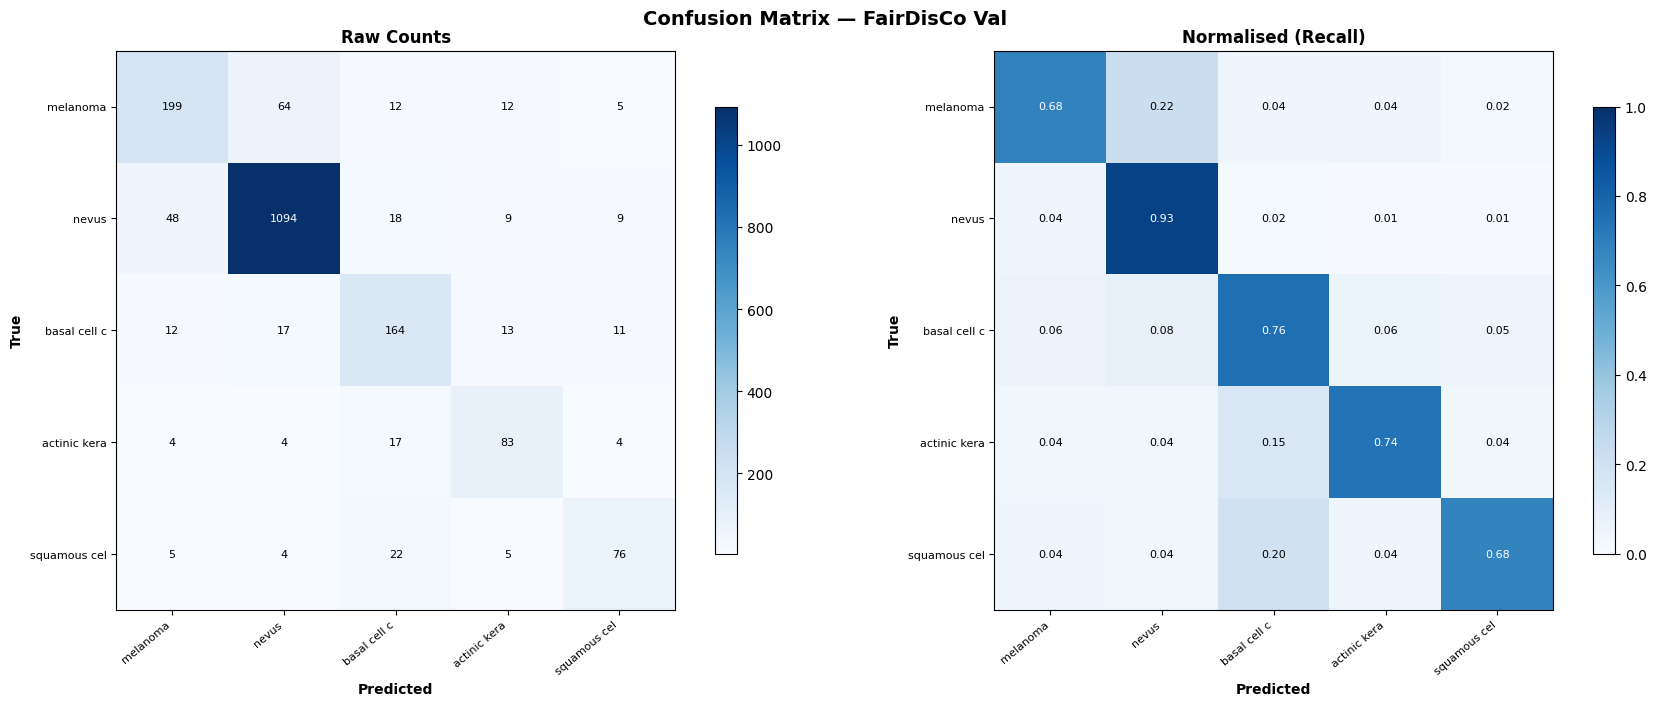

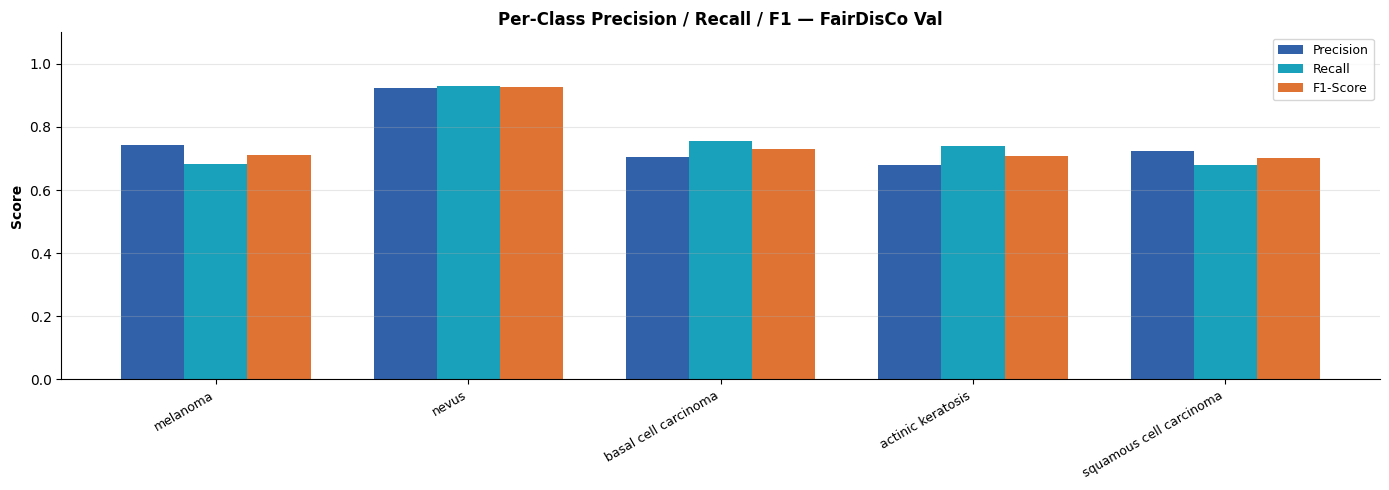

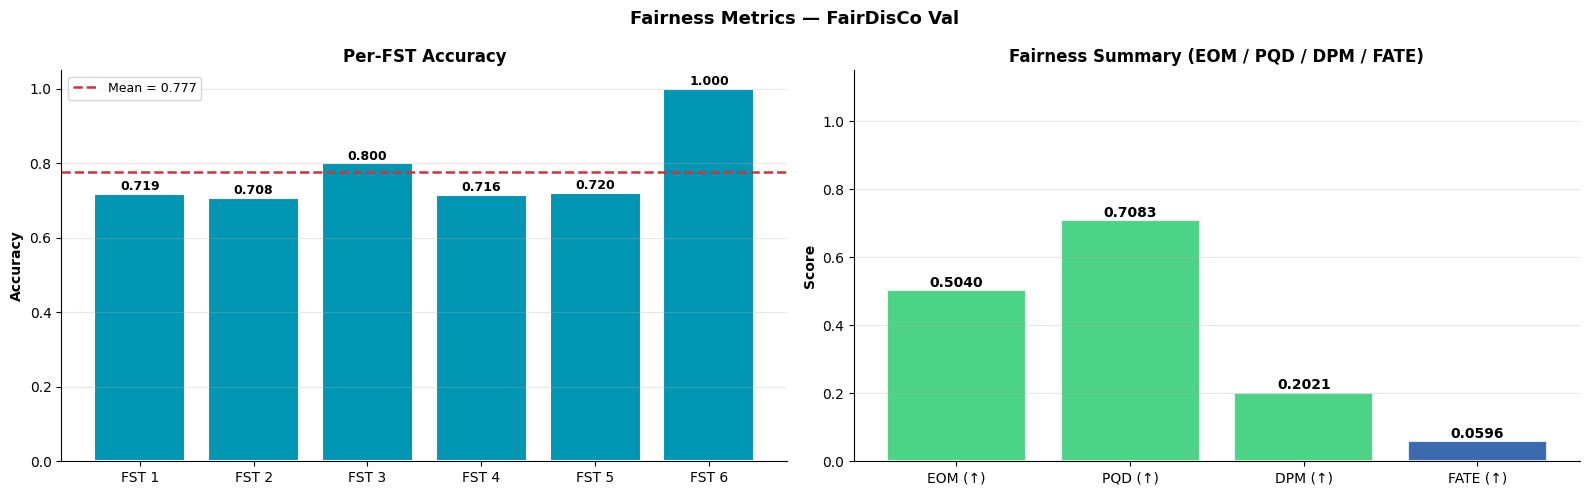


Running Baseline val evaluation ...

════════════════════════════════════════════════════════════
  Baseline (Lcls only) — Val — Full Evaluation Report
════════════════════════════════════════════════════════════

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.7870
  AUC-ROC (macro)   : 0.9481
  Precision (macro) : 0.7070
  Recall    (macro) : 0.7493
  F1        (macro) : 0.7215
  F1        (micro) : 0.7870
  F1     (weighted) : 0.7967

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma                   0.5306  0.8014  0.6385
  Nevus                      0.9409  0.8107  0.8710
  Basal Cell Carcinoma       0.7072  0.7235  0.7153
  Actinic Keratosis          0.6870  0.7054  0.6960
  Squamous Cell Carcinoma    0.6695  0.7054  0.6870

───────────────

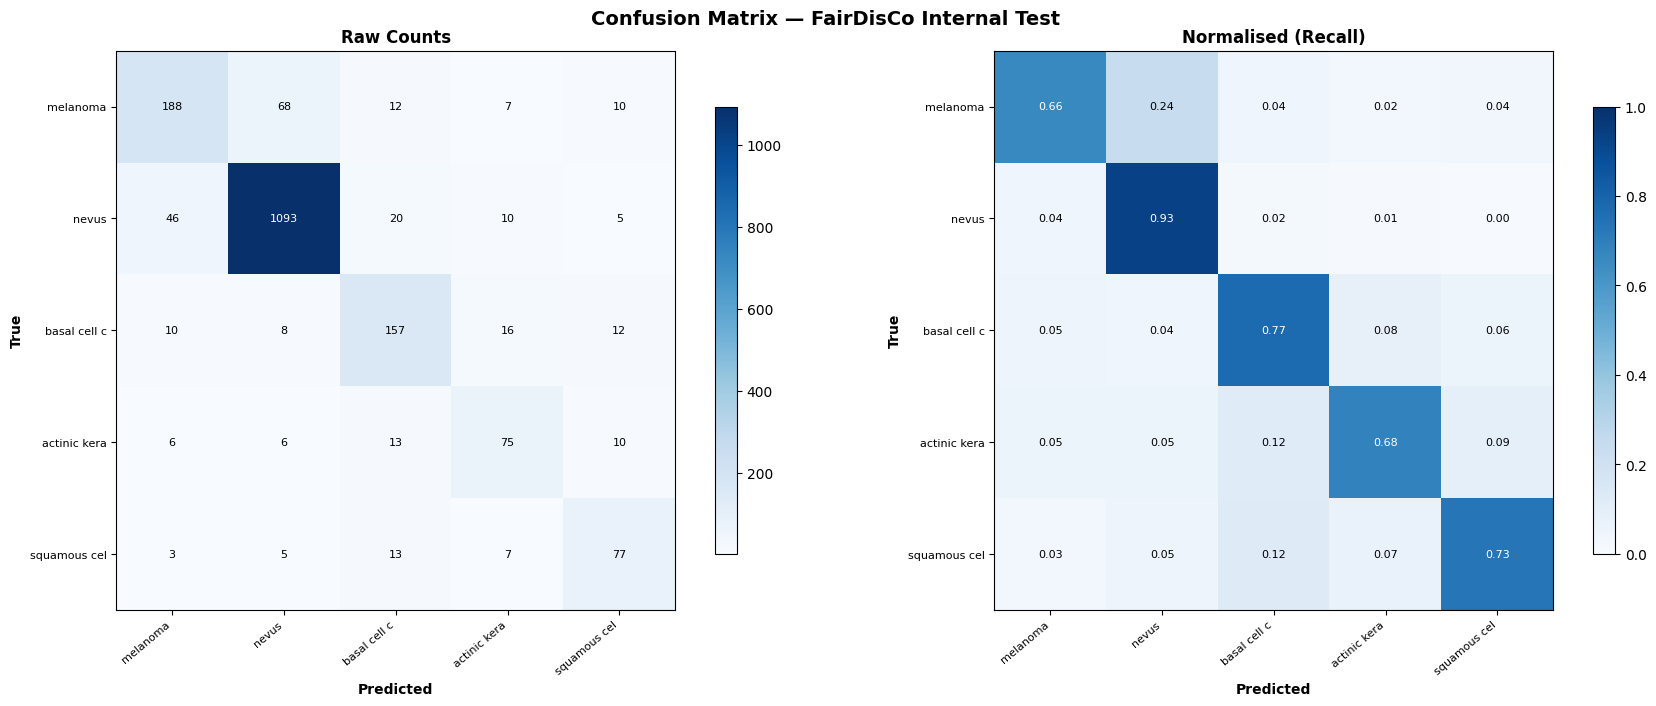

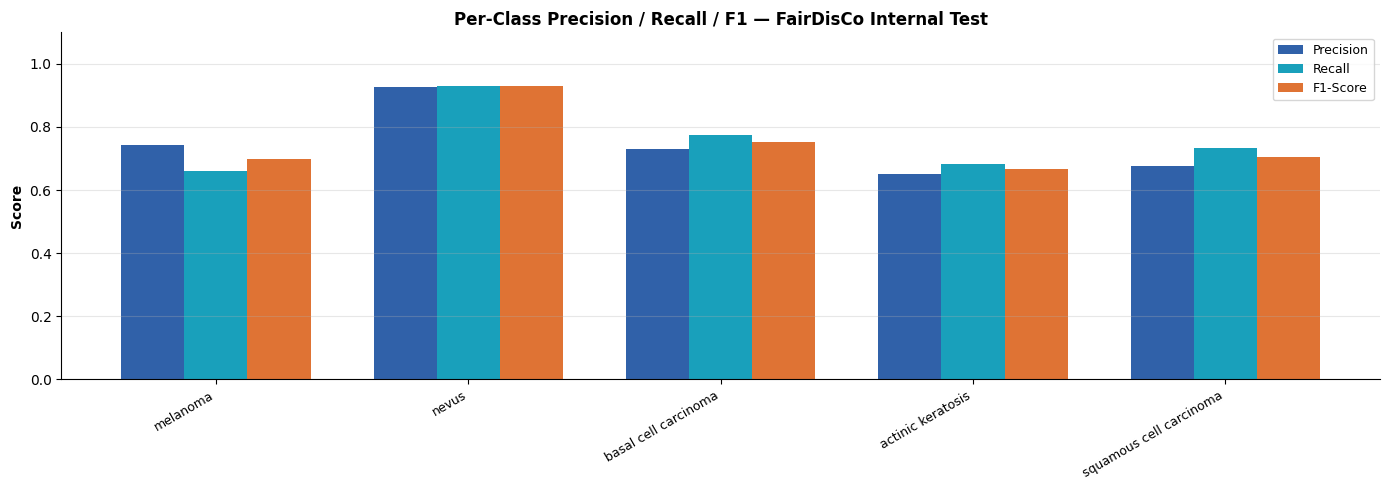

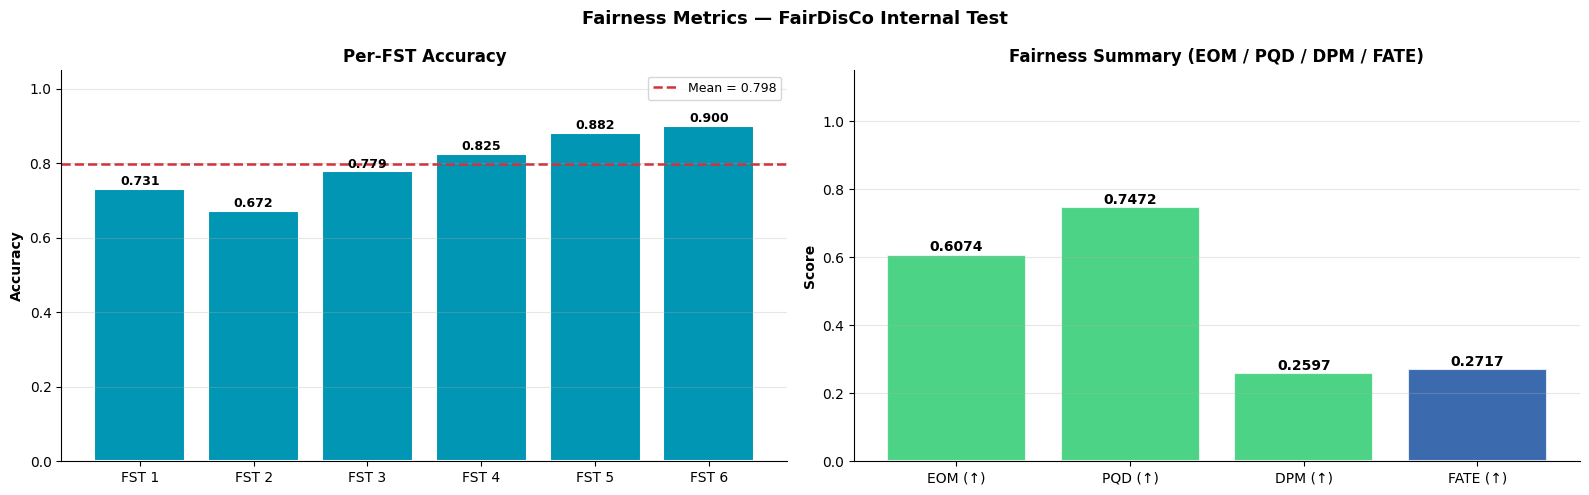


════════════════════════════════════════════════════════════
  Summary: Baseline vs FairDisCo  (Val set)
════════════════════════════════════════════════════════════
  Metric                   Baseline  FairDisCo
  --------------------------------------------
  Accuracy                   0.7870     0.8456
  AUC-ROC                    0.9481     0.9546
  F1 (macro)                 0.7215     0.7552
  EOM                        0.4787     0.5040
  PQD                        0.8065     0.7083
  DPM                        0.1768     0.2021
  FATE                          nan     0.0596
════════════════════════════════════════════════════════════


In [66]:
# ════════════════════════════════════════════════════════════════════════════
# VAL + TEST EVALUATION  (Baseline → FATE ref, then FairDisCo)
# ════════════════════════════════════════════════════════════════════════════

_fmt = lambda v: f'{v:.4f}' if isinstance(v,float) and not np.isnan(v) else 'nan'

# ── Step 1: Evaluate Baseline on val (provides FATE denominator) ──────────
print('Computing baseline evaluation for FATE reference ...')
_baseline_val_loader = DataLoader(
    _val_ds,
    batch_size=CFG['batch_size']*2,
    shuffle=False, num_workers=0, pin_memory=False,
    collate_fn=mixed_collate,
)
# Temperature-scale the baseline too
scaled_baseline = TemperatureScaler(baseline_model).to(DEVICE)
scaled_baseline.set_temperature(_baseline_val_loader)

_bval_probs, _bval_labels, _ = collect_probs(scaled_baseline, _baseline_val_loader)
_base_thresh = optimise_thresholds(_bval_probs, _bval_labels, CFG['num_classes'])

baseline_res  = validate_with_thresholds(scaled_baseline, _baseline_val_loader, _base_thresh)
baseline_fair = fairness(baseline_res)
print(f'  Baseline: acc={baseline_res["acc"]:.4f}  auroc={_fmt(baseline_res["auroc"])}  '
      f'F1={baseline_res["macro_f1"]:.4f}  EOM={_fmt(baseline_fair["EOM"])}')

# ── Step 2: FairDisCo val evaluation ─────────────────────────────────────
print('\nRunning FairDisCo val evaluation ...')
vr = validate_with_thresholds(scaled_model, val_loader, best_thresholds)
fr = fairness(vr, baseline_res=baseline_res, baseline_fair=baseline_fair)
print_full_report(vr, fr, split_name='FairDisCo — Val (T-scaled + threshold-opt)')
plot_confusion_matrix(vr['conf_mat'], split_name='FairDisCo Val',
                      save_path=CFG['results_dir']/'fdc_val_confusion_matrix.png')
plot_per_class_metrics(vr, split_name='FairDisCo Val',
                       save_path=CFG['results_dir']/'fdc_val_per_class_metrics.png')
plot_fairness_metrics(fr, vr, split_name='FairDisCo Val',
                      save_path=CFG['results_dir']/'fdc_val_fairness_metrics.png')

# ── Step 3: Baseline val evaluation (for side-by-side display) ───────────
print('\nRunning Baseline val evaluation ...')
bl_vr = validate_with_thresholds(scaled_baseline, _baseline_val_loader, _base_thresh)
bl_fr = fairness(bl_vr)
print_full_report(bl_vr, bl_fr, split_name='Baseline (Lcls only) — Val')

# ── Step 4: Internal test evaluation ─────────────────────────────────────
if test_loader is not None:
    print('\nRunning FairDisCo internal test evaluation ...')
    test_res  = validate_with_thresholds(scaled_model, test_loader, best_thresholds)
    test_fair = fairness(test_res, baseline_res=baseline_res, baseline_fair=baseline_fair)
    print_full_report(test_res, test_fair, split_name='FairDisCo — Internal Test')
    plot_confusion_matrix(test_res['conf_mat'], split_name='FairDisCo Internal Test',
                          save_path=CFG['results_dir']/'fdc_test_confusion_matrix.png')
    plot_per_class_metrics(test_res, split_name='FairDisCo Internal Test',
                           save_path=CFG['results_dir']/'fdc_test_per_class_metrics.png')
    plot_fairness_metrics(test_fair, test_res, split_name='FairDisCo Internal Test',
                          save_path=CFG['results_dir']/'fdc_test_fairness_metrics.png')
else:
    print('[SKIP] test_loader is None.')

# ── Step 5: Summary comparison table ─────────────────────────────────────
print(f'\n{"═"*60}')
print('  Summary: Baseline vs FairDisCo  (Val set)')
print(f'{"═"*60}')
_cmp_keys = [
    ('acc','Accuracy'),('auroc','AUC-ROC'),('macro_f1','F1 (macro)'),
]
_fair_keys = [('EOM','EOM'),('PQD','PQD'),('DPM','DPM'),('FATE','FATE')]
print(f'  {"Metric":<22} {"Baseline":>10} {"FairDisCo":>10}')
print(f'  {"-"*44}')
for attr, name in _cmp_keys:
    b = _fmt(baseline_res[attr]); f = _fmt(vr[attr])
    print(f'  {name:<22} {b:>10} {f:>10}')
for attr, name in _fair_keys:
    b = _fmt(baseline_fair[attr]); f = _fmt(fr[attr])
    print(f'  {name:<22} {b:>10} {f:>10}')
print(f'{"═"*60}')


============================================================  derm7pt_derm
  Acc=0.7537  AUROC=0.8668  macro-F1=0.4238
  Per-class metrics (Derm7pt classes):
    [0] melanoma                   Prec=0.5975  Rec=0.5714  F1=0.5842
    [1] nevus                      Prec=0.8206  Rec=0.8435  F1=0.8319
    [2] basal cell carcinoma       Prec=0.8125  Rec=0.6190  F1=0.7027

════════════════════════════════════════════════════════════
  Cross-Eval [derm7pt_derm] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.7537
  AUC-ROC (macro)   : 0.8668
  Precision (macro) : 0.4461
  Recall    (macro) : 0.4068
  F1        (macro) : 0.4238
  F1        (micro) : 0.7537
  F1     (weighted) : 0.7538

────────────────────────────────────────
  Per-Class Metrics
────

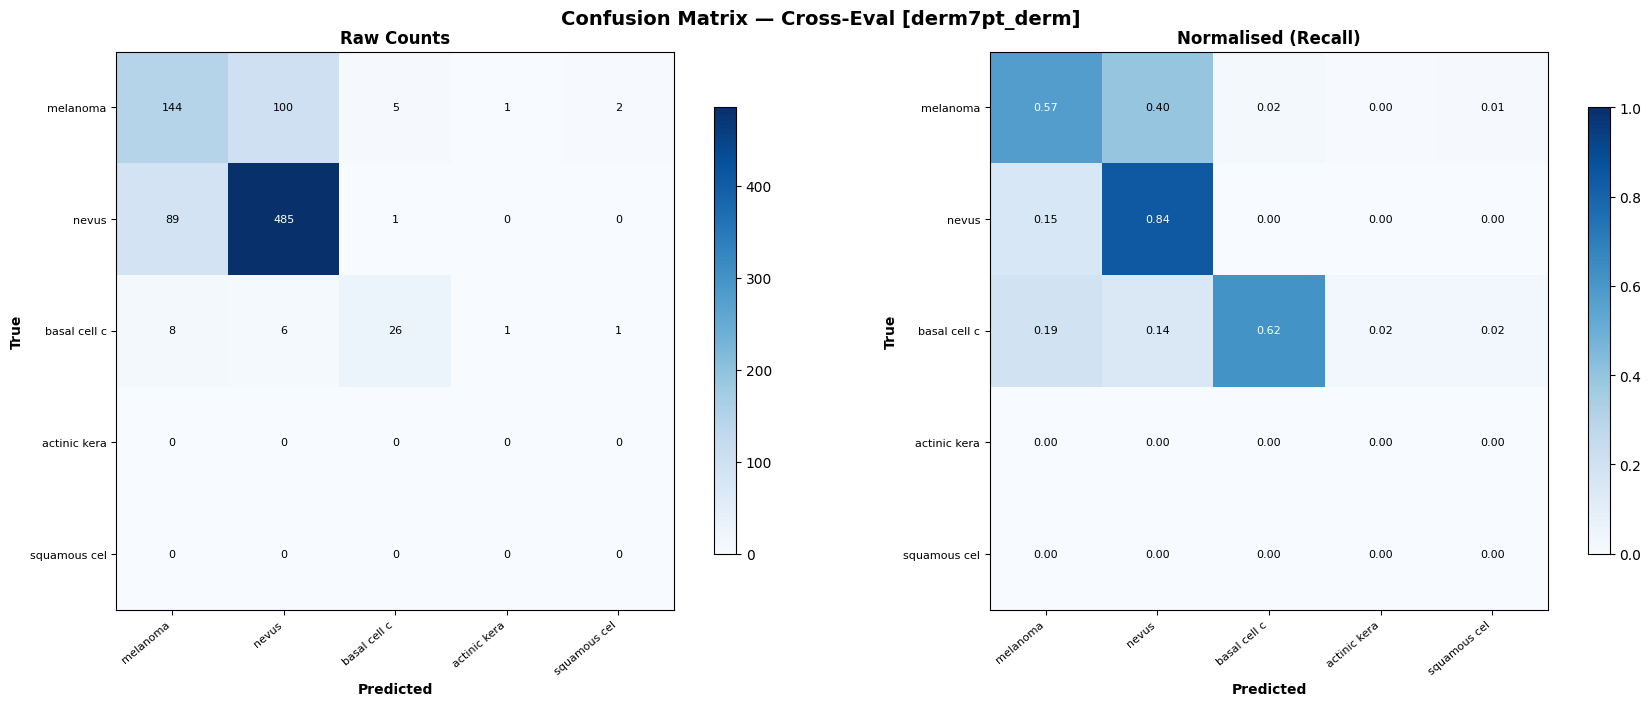

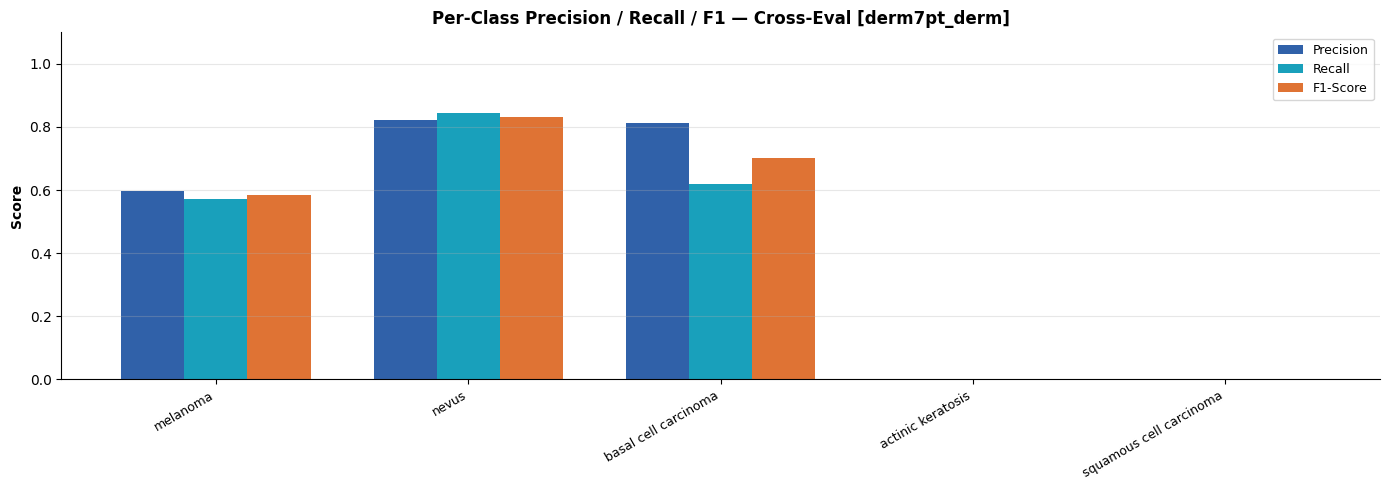

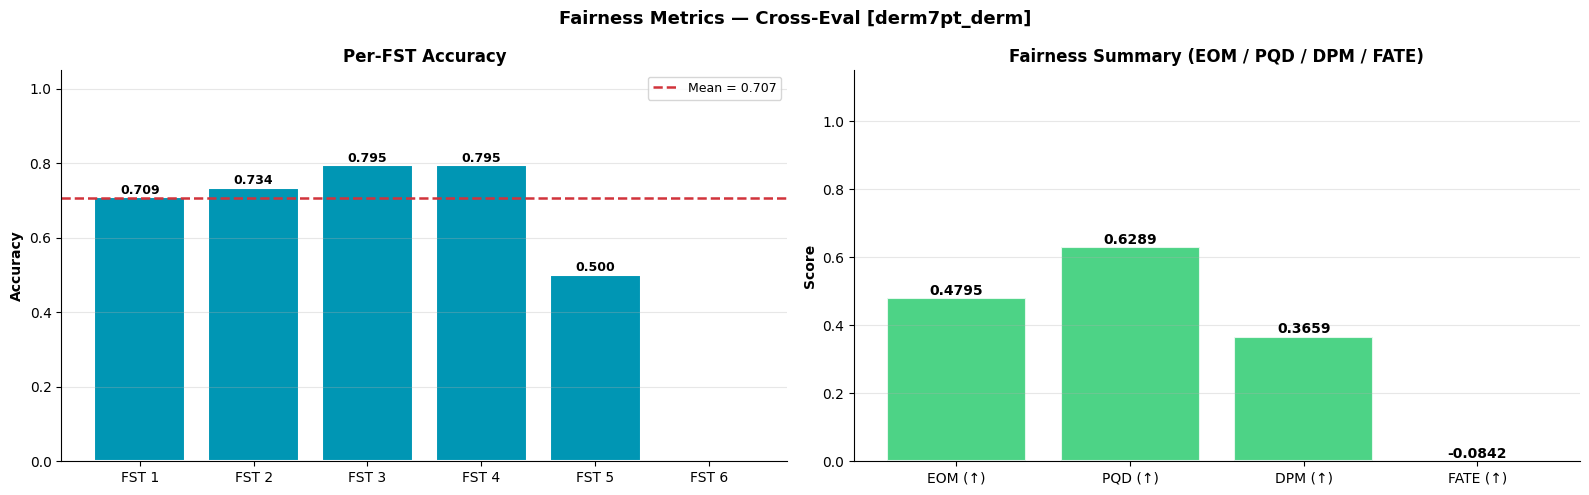


============================================================  derm7pt_clinical
  Acc=0.6306  AUROC=0.7920  macro-F1=0.3141
  Per-class metrics (Derm7pt classes):
    [0] melanoma                   Prec=0.4753  Rec=0.7262  F1=0.5746
    [1] nevus                      Prec=0.8803  Rec=0.6139  F1=0.7234
    [2] basal cell carcinoma       Prec=0.2609  Rec=0.2857  F1=0.2727

════════════════════════════════════════════════════════════
  Cross-Eval [derm7pt_clinical] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.6306
  AUC-ROC (macro)   : 0.7920
  Precision (macro) : 0.3233
  Recall    (macro) : 0.3252
  F1        (macro) : 0.3141
  F1        (micro) : 0.6306
  F1     (weighted) : 0.6584

────────────────────────────────────────
  Per-Class Metr

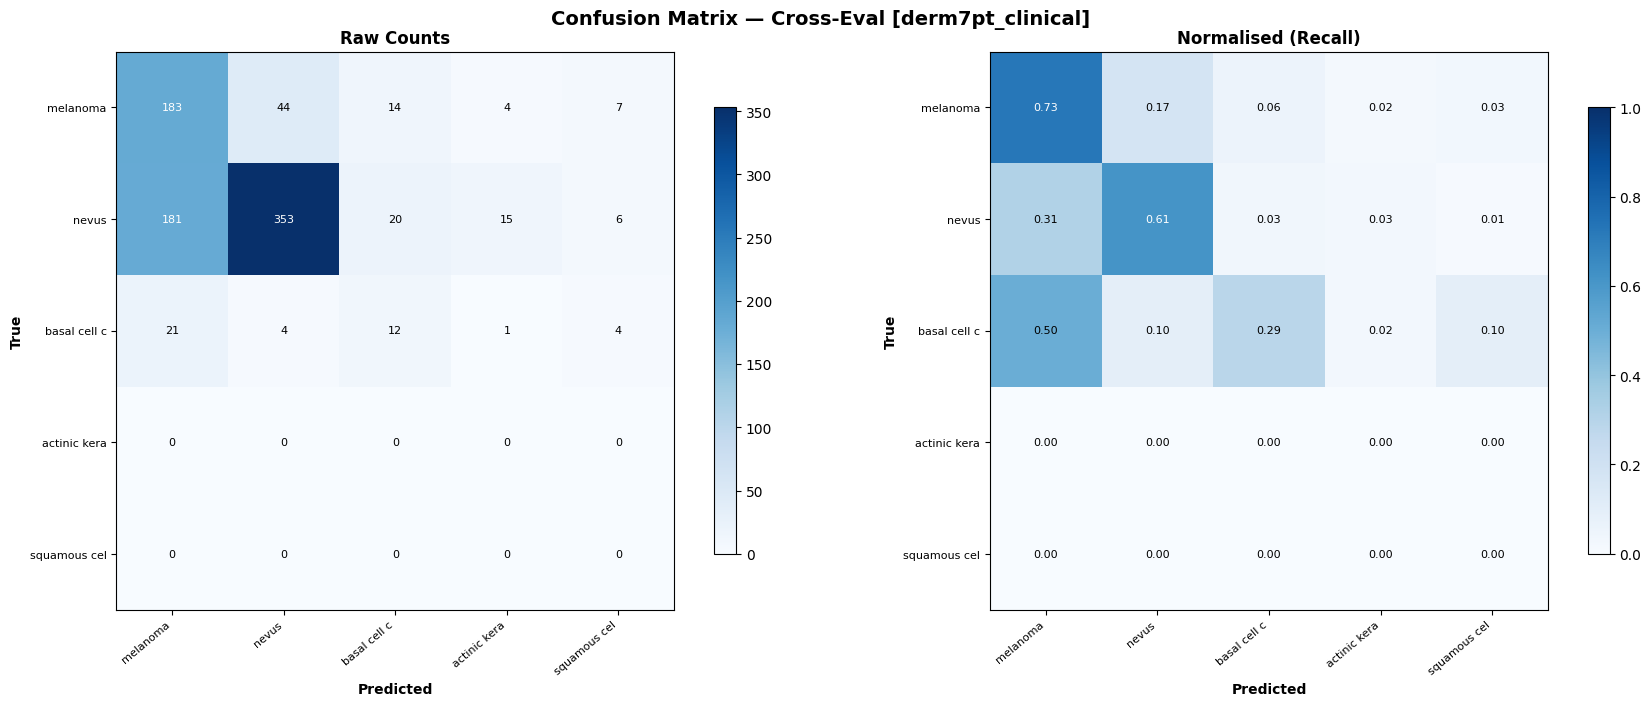

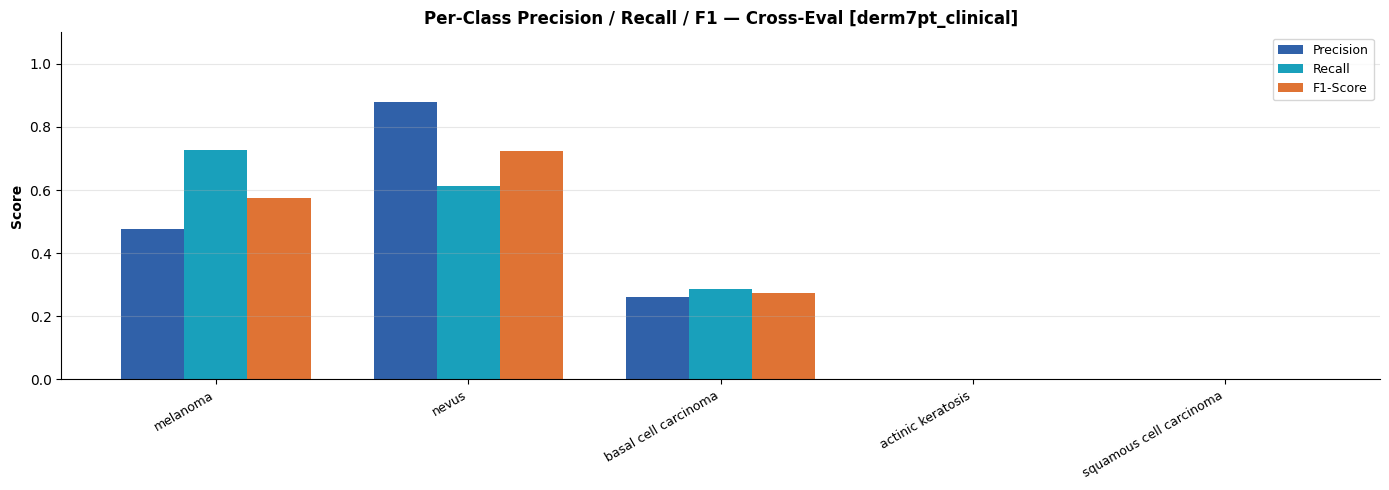

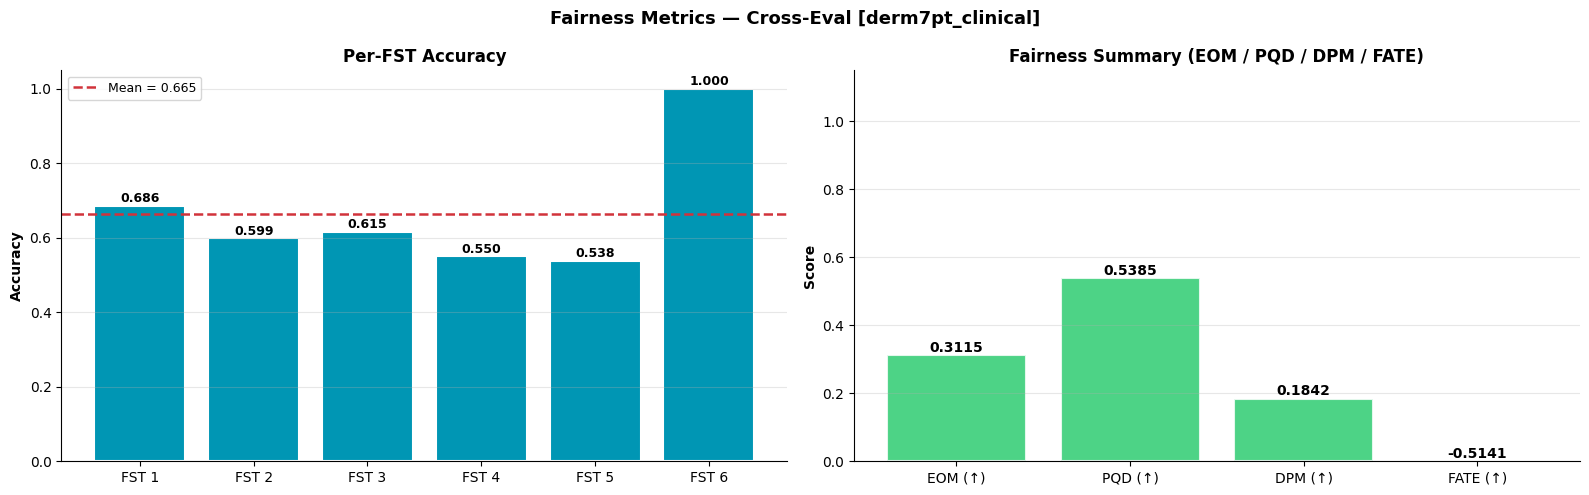


════════════════════════════════════════════════════════════
  COMBINED Derm7pt (clinical + dermoscopic)
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Cross-Eval [Derm7pt COMBINED] — Full Evaluation Report
════════════════════════════════════════════════════════════
  [NOTE] Derm7pt: melanoma/nevus/BCC only (classes 0,1,2). AK/SCC rows will be zero.

────────────────────────────────────────
  Overall Metrics
────────────────────────────────────────
  Accuracy          : 0.6922
  AUC-ROC (macro)   : 0.8270
  Precision (macro) : 0.3709
  Recall    (macro) : 0.3660
  F1        (macro) : 0.3661
  F1        (micro) : 0.6922
  F1     (weighted) : 0.7082

────────────────────────────────────────
  Per-Class Metrics
────────────────────────────────────────
  Class                        Prec     Rec      F1
  ────────────────────────────────────────────────
  Melanoma                   0.5224  0.6488  0.5788
  Nevu

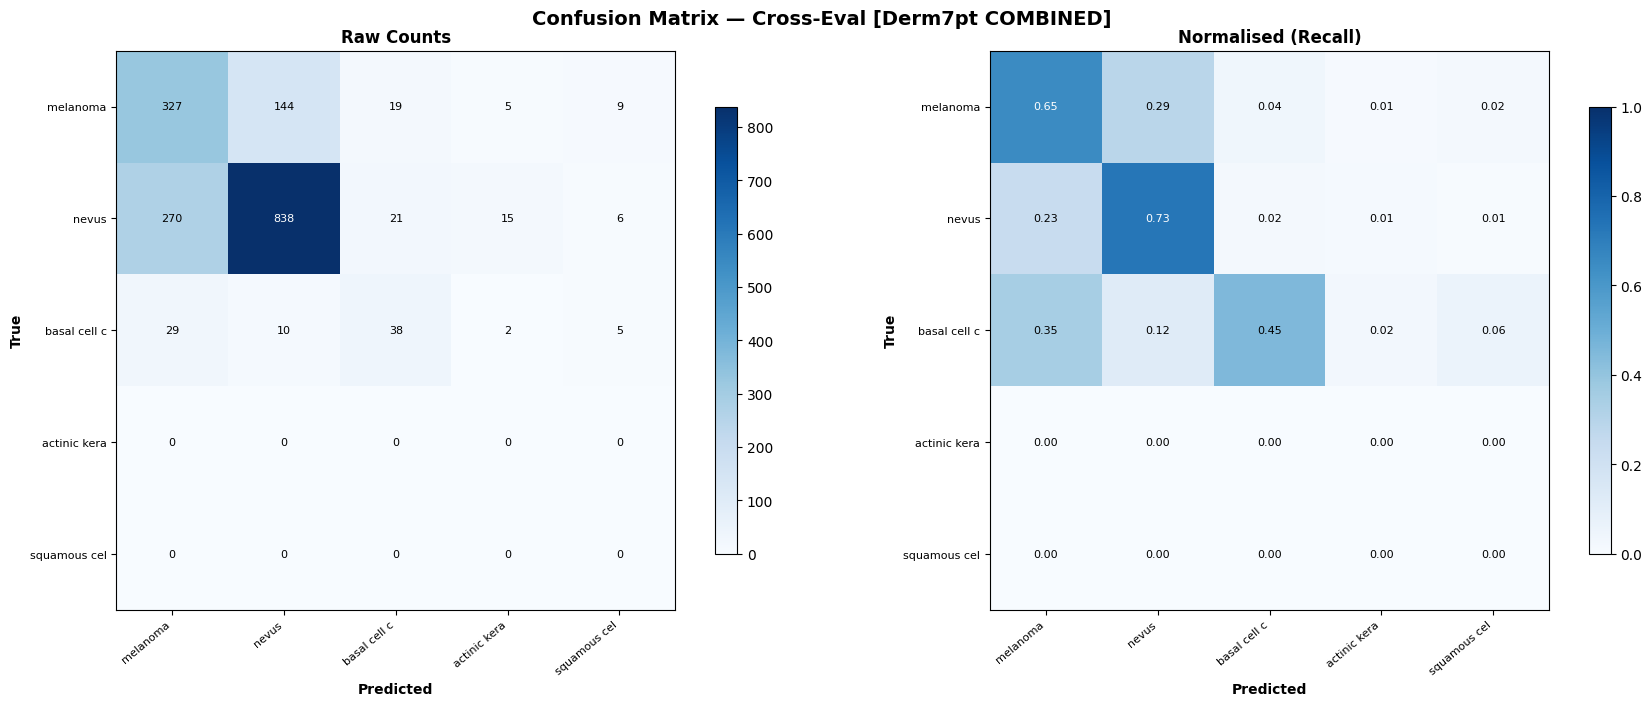

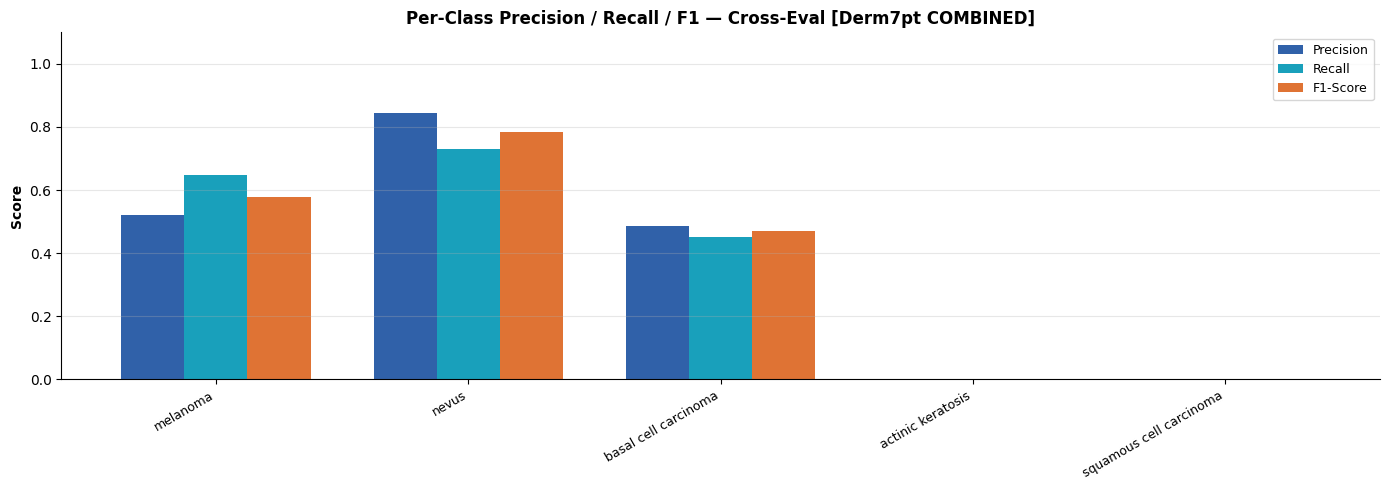

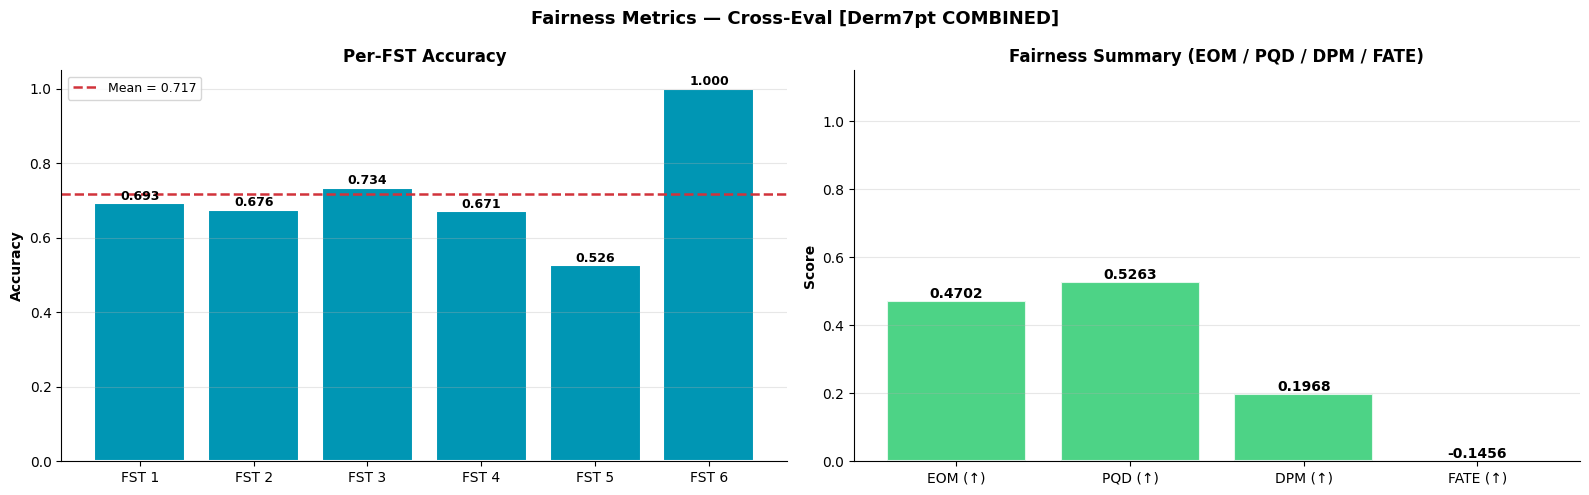


── Cross-Dataset Summary Table ──────────────────────────────────────
                  Accuracy  AUC-ROC  Precision (M)  Recall    (M)  F1        (M)  F1   (weighted)  F1 melanoma  F1 nevus  F1 BCC     EOM     PQD     DPM    FATE
derm7pt_derm        0.7537   0.8668         0.4461         0.4068         0.4238           0.7538       0.5842    0.8319  0.7027  0.4795  0.6289  0.3659 -0.0842
derm7pt_clinical    0.6306   0.7920         0.3233         0.3252         0.3141           0.6584       0.5746    0.7234  0.2727  0.3115  0.5385  0.1842 -0.5141
Derm7pt COMBINED    0.6922   0.8270         0.3709         0.3660         0.3661           0.7082       0.5788    0.7824  0.4691  0.4702  0.5263  0.1968 -0.1456

[NOTE] macro-AUROC computed via robust_macro_auroc() (handles 3-class Derm7pt subset correctly).
[NOTE] FST estimated via ITA; per-FST Accuracy reported (no per-FST AUROC).
[NOTE] AK (class 3) and SCC (class 4) rows are 0 — not present in Derm7pt.


In [67]:
# ════════════════════════════════════════════════════════════════════════════
# CROSS-DATASET EVALUATION  (Derm7pt — clinical + dermoscopic)
# ════════════════════════════════════════════════════════════════════════════

DERM7PT_EVAL_CLASSES = [0, 1, 2]
DERM7PT_CLASS_NAMES  = {0: 'melanoma', 1: 'nevus', 2: 'basal cell carcinoma'}

cross_results   = {}   # per-modality results
combined_probs  = []
combined_preds  = []
combined_labels = []
combined_skins  = []

for ds_name, loader in eval_loaders.items():
    print(f'\n{"="*60}  {ds_name}')

    res  = validate_with_thresholds(scaled_model, loader, best_thresholds)
    fair = fairness(res, baseline_res=baseline_res, baseline_fair=baseline_fair)

    # ── Total metrics ─────────────────────────────────────────────────────
    print(f'  Acc={res["acc"]:.4f}  AUROC={_fmt(res["auroc"])}  macro-F1={res["macro_f1"]:.4f}')

    # ── Per-class for classes present in Derm7pt ──────────────────────────
    print('  Per-class metrics (Derm7pt classes):')
    for cls_id, cls_name in DERM7PT_CLASS_NAMES.items():
        p = res['per_class_prec'][cls_id]
        r = res['per_class_rec'][cls_id]
        f = res['per_class_f1'][cls_id]
        print(f'    [{cls_id}] {cls_name:<25}  Prec={p:.4f}  Rec={r:.4f}  F1={f:.4f}')

    print_full_report(res, fair, split_name=f'Cross-Eval [{ds_name}]')

    plot_confusion_matrix(
        res['conf_mat'],
        split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'fdc_cross_{ds_name}_confusion.png',
    )
    plot_per_class_metrics(
        res, split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'fdc_cross_{ds_name}_per_class.png',
    )
    plot_fairness_metrics(
        fair, res, split_name=f'Cross-Eval [{ds_name}]',
        save_path=CFG['results_dir'] / f'fdc_cross_{ds_name}_fairness.png',
    )

    cross_results[ds_name] = {
        'Accuracy'       : res['acc'],
        'AUC-ROC'        : res['auroc'],
        'Precision (M)'  : res['macro_prec'],
        'Recall    (M)'  : res['macro_rec'],
        'F1        (M)'  : res['macro_f1'],
        'F1   (weighted)': res['weighted_f1'],
        'F1 melanoma'    : res['per_class_f1'][0],
        'F1 nevus'       : res['per_class_f1'][1],
        'F1 BCC'         : res['per_class_f1'][2],
        'EOM'            : fair['EOM'],
        'PQD'            : fair['PQD'],
        'DPM'            : fair['DPM'],
        'FATE'           : fair['FATE'],
    }

    # Accumulate for combined eval
    combined_probs .append(res['probs'])
    combined_preds .append(res['preds'])
    combined_labels.append(res['labels'])
    combined_skins .append(res['skin'])


# ════════════════════════════════════════════════════════════════════════════
# COMBINED DERM7PT — aggregate across both modalities
# ════════════════════════════════════════════════════════════════════════════
if combined_probs:
    from sklearn.metrics import (precision_score, recall_score,
                                  confusion_matrix as sk_confusion_matrix)

    c_probs  = np.concatenate(combined_probs,  axis=0)
    c_preds  = np.concatenate(combined_preds,  axis=0)
    c_labels = np.concatenate(combined_labels, axis=0)
    c_skins  = np.concatenate(combined_skins,  axis=0)

    c_acc         = float((c_preds == c_labels).mean())
    c_auroc       = robust_macro_auroc(c_probs, c_labels)
    c_macro_f1    = float(f1_score(c_labels, c_preds, average='macro',    zero_division=0))
    c_micro_f1    = float(f1_score(c_labels, c_preds, average='micro',    zero_division=0))
    c_weighted_f1 = float(f1_score(c_labels, c_preds, average='weighted', zero_division=0))
    c_macro_prec  = float(precision_score(c_labels, c_preds, average='macro',    zero_division=0))
    c_macro_rec   = float(recall_score(   c_labels, c_preds, average='macro',    zero_division=0))
    c_per_prec    = precision_score(c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_per_rec     = recall_score(   c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_per_f1      = f1_score(       c_labels, c_preds, average=None, zero_division=0,
                                    labels=list(range(CFG['num_classes'])))
    c_conf_mat    = sk_confusion_matrix(c_labels, c_preds,
                                        labels=list(range(CFG['num_classes'])))

    combined_res = {
        'acc': c_acc, 'auroc': c_auroc,
        'macro_f1': c_macro_f1, 'micro_f1': c_micro_f1,
        'weighted_f1': c_weighted_f1,
        'macro_prec': c_macro_prec, 'macro_rec': c_macro_rec,
        'weighted_prec': float(precision_score(c_labels, c_preds, average='weighted', zero_division=0)),
        'weighted_rec' : float(recall_score(   c_labels, c_preds, average='weighted', zero_division=0)),
        'per_class_prec': c_per_prec, 'per_class_rec': c_per_rec,
        'per_class_f1': c_per_f1, 'conf_mat': c_conf_mat,
        'probs': c_probs, 'preds': c_preds,
        'labels': c_labels, 'skin': c_skins,
    }
    combined_fair = fairness(combined_res,
                             baseline_res=baseline_res, baseline_fair=baseline_fair)

    print(f'\n{"═"*60}')
    print('  COMBINED Derm7pt (clinical + dermoscopic)')
    print(f'{"═"*60}')
    print_full_report(combined_res, combined_fair,
                      split_name='Cross-Eval [Derm7pt COMBINED]')
    plot_confusion_matrix(
        combined_res['conf_mat'],
        split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'fdc_cross_derm7pt_combined_confusion.png',
    )
    plot_per_class_metrics(
        combined_res, split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'fdc_cross_derm7pt_combined_per_class.png',
    )
    plot_fairness_metrics(
        combined_fair, combined_res,
        split_name='Cross-Eval [Derm7pt COMBINED]',
        save_path=CFG['results_dir'] / 'fdc_cross_derm7pt_combined_fairness.png',
    )

    cross_results['Derm7pt COMBINED'] = {
        'Accuracy'       : c_acc,
        'AUC-ROC'        : c_auroc,
        'Precision (M)'  : c_macro_prec,
        'Recall    (M)'  : c_macro_rec,
        'F1        (M)'  : c_macro_f1,
        'F1   (weighted)': c_weighted_f1,
        'F1 melanoma'    : c_per_f1[0],
        'F1 nevus'       : c_per_f1[1],
        'F1 BCC'         : c_per_f1[2],
        'EOM'            : combined_fair['EOM'],
        'PQD'            : combined_fair['PQD'],
        'DPM'            : combined_fair['DPM'],
        'FATE'           : combined_fair['FATE'],
    }

# ── Save summary table ────────────────────────────────────────────────────
cross_df = pd.DataFrame(cross_results).T.round(4)
cross_df.to_csv(CFG['results_dir'] / 'fdc_cross_dataset_eval.csv')

print('\n── Cross-Dataset Summary Table ──────────────────────────────────────')
print(cross_df.to_string())
print('\n[NOTE] macro-AUROC computed via robust_macro_auroc() '
      '(handles 3-class Derm7pt subset correctly).')
print('[NOTE] FST estimated via ITA; per-FST Accuracy reported (no per-FST AUROC).')
print('[NOTE] AK (class 3) and SCC (class 4) rows are 0 — not present in Derm7pt.')


## Phase 6 — Visualization

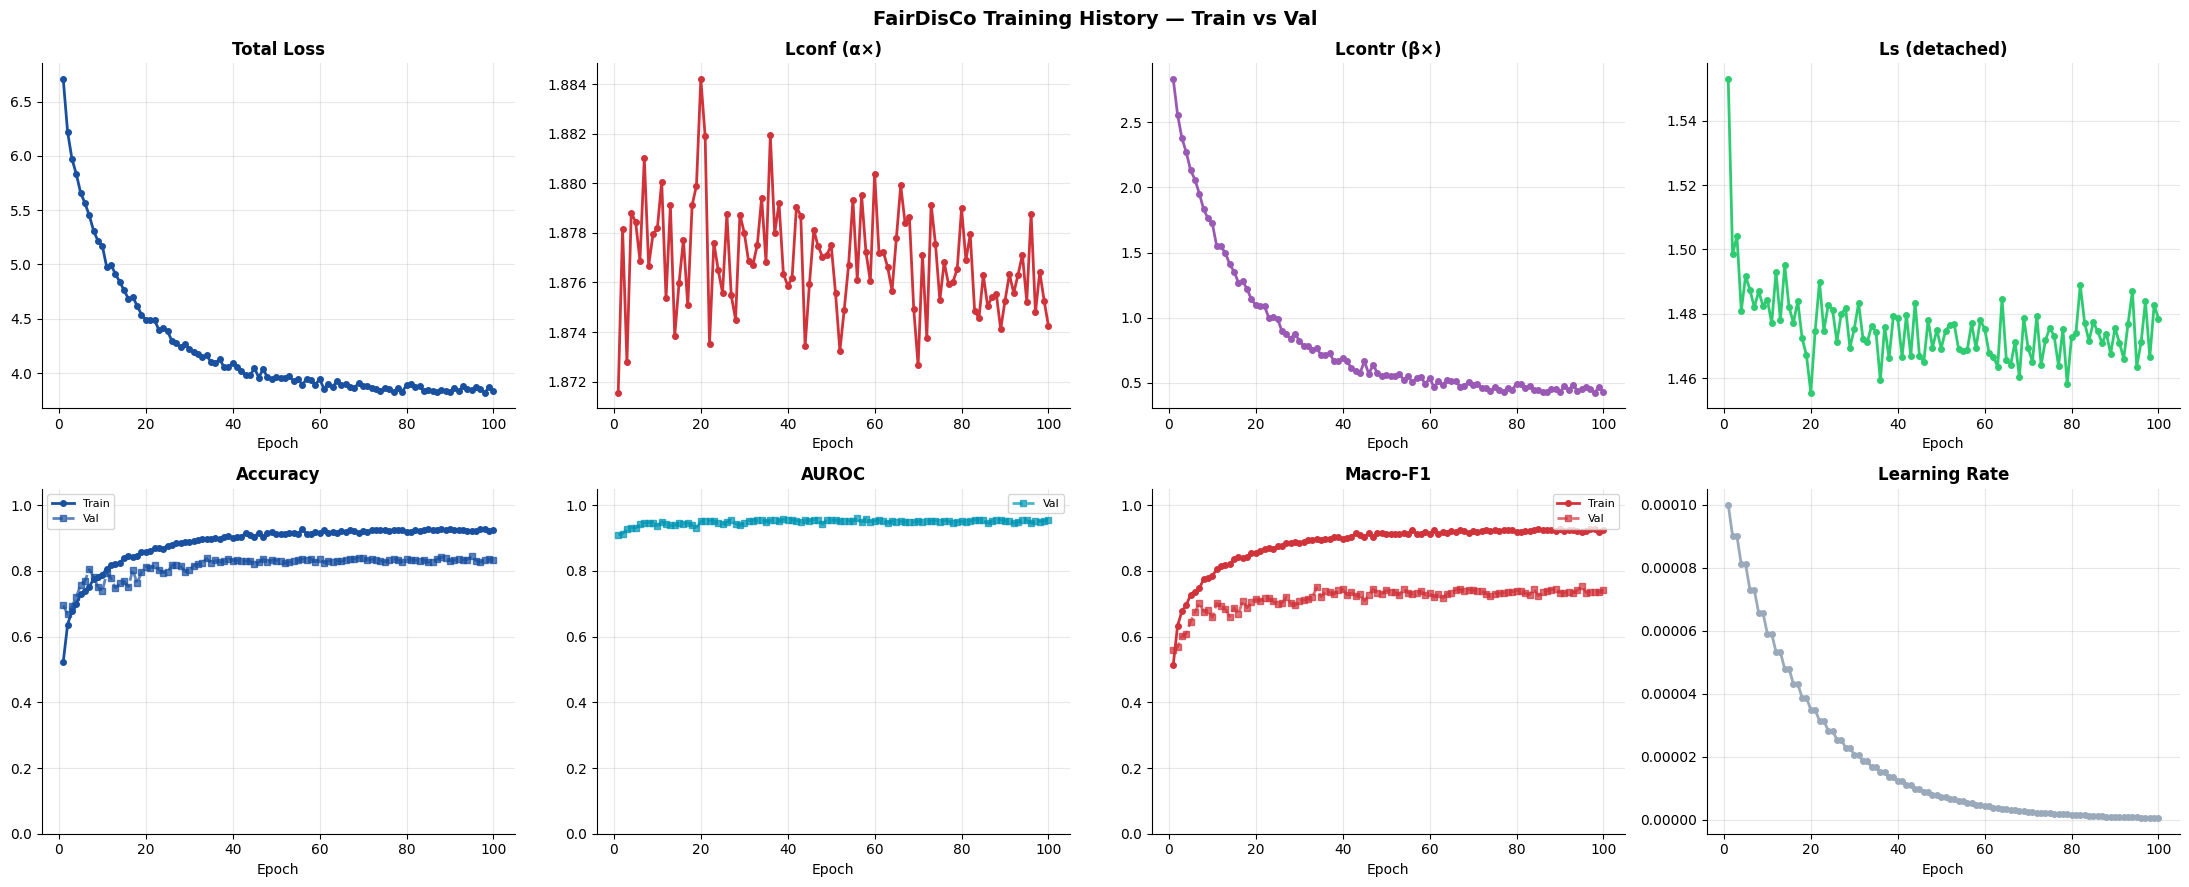

In [68]:
# ── Training curves (FairDisCo: total / Lconf / Lcontr / Ls + val metrics) ──
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('FairDisCo Training History — Train vs Val', fontsize=14, fontweight='bold')

epochs_x = list(range(1, len(history.get('train_total', [])) + 1))

# Row 0 — Loss curves
for ax, key, title, color in [
    (axes[0,0], 'train_total', 'Total Loss',   '#1950A0'),
    (axes[0,1], 'train_conf',  'Lconf (α×)',   '#D1333B'),
    (axes[0,2], 'train_con',   'Lcontr (β×)',  '#9B59B6'),
    (axes[0,3], 'train_skin',  'Ls (detached)','#2ECC71'),
]:
    if history.get(key):
        ax.plot(epochs_x, history[key], color=color, lw=2, marker='o', ms=4)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)

# Row 1 — Classification metrics + LR
for ax, t_key, v_key, title, color in [
    (axes[1,0], 'train_acc',      'val_acc',      'Accuracy',   '#1950A0'),
    (axes[1,1], 'train_auroc',    'val_auroc',    'AUROC',      '#0096B4'),
    (axes[1,2], 'train_macro_f1', 'val_macro_f1', 'Macro-F1',   '#D1333B'),
    (axes[1,3], 'lr',             None,           'Learning Rate','#9AAABB'),
]:
    if history.get(t_key):
        ax.plot(epochs_x, history[t_key], color=color, lw=2, marker='o', ms=4,
                label='Train', linestyle='-')
    if v_key and history.get(v_key):
        ax.plot(epochs_x, history[v_key], color=color, lw=2, marker='s', ms=4,
                label='Val', linestyle='--', alpha=0.7)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch')
    if t_key != 'lr': ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3); ax.spines[['top','right']].set_visible(False)
    if v_key: ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'fdc_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

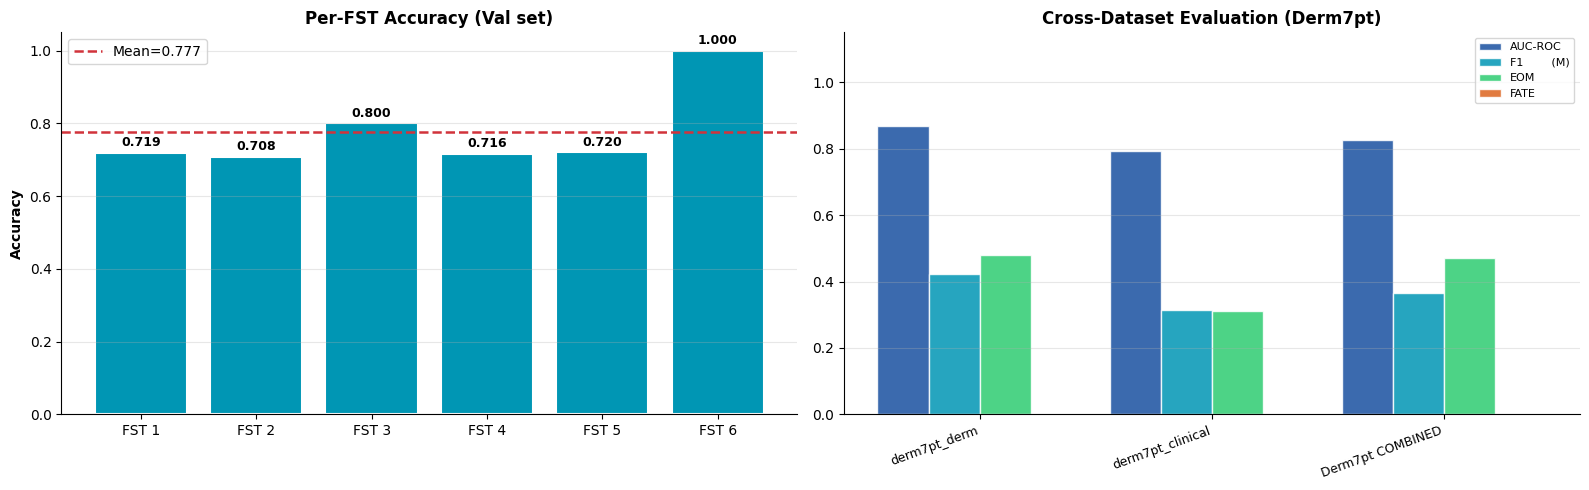

In [69]:
# ── Per-FST Accuracy + cross-dataset comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-FST Accuracy bars (val set)
pg_acc_vals = [fr['pg_acc'].get(i, float('nan')) for i in range(6)]
groups      = [f'FST {i+1}' for i in range(6)]
colors      = ['#0096B4' if not np.isnan(v) else '#CCCCCC' for v in pg_acc_vals]
bars        = axes[0].bar(groups, [0 if np.isnan(v) else v for v in pg_acc_vals],
                          color=colors, edgecolor='white', lw=1.5)
mean_acc    = np.nanmean(pg_acc_vals)
axes[0].axhline(mean_acc, ls='--', color='#D1333B', lw=1.8,
                label=f'Mean={mean_acc:.3f}')
for b, v in zip(bars, pg_acc_vals):
    if not np.isnan(v):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Per-FST Accuracy (Val set)', fontweight='bold', fontsize=12)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cross-dataset comparison (all rows including COMBINED)
if cross_results:
    df_plot = pd.DataFrame(cross_results).T
    x = np.arange(len(df_plot)); w = 0.22
    for i, (m, c) in enumerate(zip(
            ['AUC-ROC', 'F1        (M)', 'EOM', 'FATE'],
            ['#1950A0', '#0096B4', '#2ECC71', '#DC641E'])):
        col_vals = [df_plot.loc[idx, m] if m in df_plot.columns else 0
                    for idx in df_plot.index]
        axes[1].bar(x + (i-1.5)*w, [0 if np.isnan(v) else v for v in col_vals],
                    w, label=m.strip(), color=c, alpha=0.85, edgecolor='white')
    axes[1].set_xticks(x); axes[1].set_xticklabels(df_plot.index, rotation=20, ha='right', fontsize=9)
    axes[1].set_title('Cross-Dataset Evaluation (Derm7pt)', fontweight='bold', fontsize=12)
    axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.15)
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(CFG['results_dir']/'fdc_eval_overview.png', dpi=150, bbox_inches='tight')
plt.show()



── t-SNE: Internal Test ──────────────────────────────────
  [Internal Test] 1500 samples  classes=[0, 1, 2, 3, 4]  modalities=[0, 1]
  t-SNE: n=1500, perplexity=40 ...


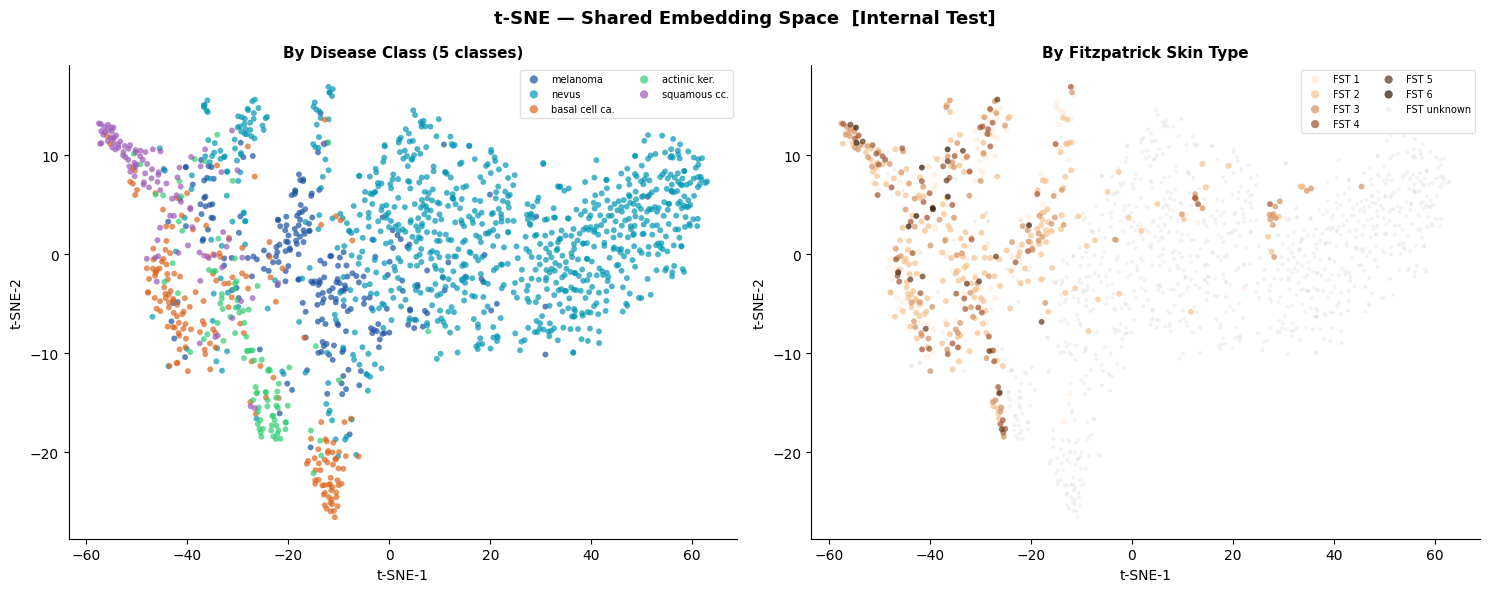

  Saved → test_tsne_class_fst.png


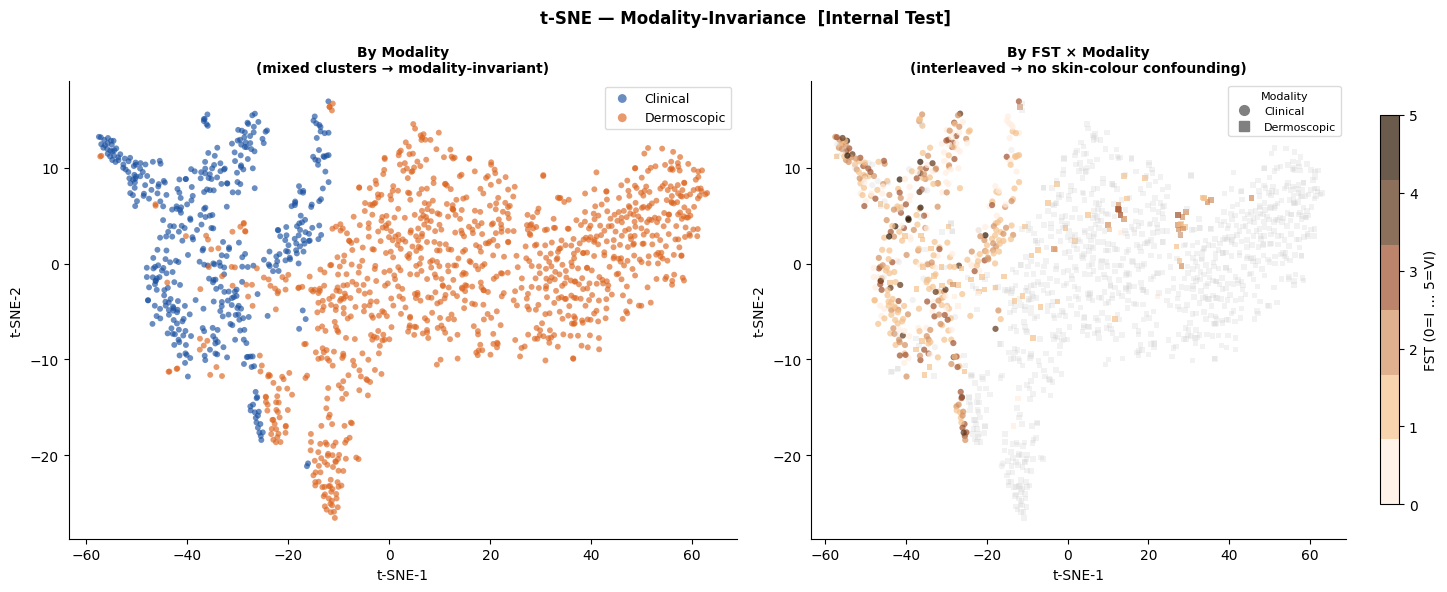

  Saved → test_tsne_modality_invariance.png

── t-SNE: Cross-Eval [derm7pt_derm] ──────────────────────────────────
  [Cross-Eval [derm7pt_derm]] 869 samples  classes=[0, 1, 2]  modalities=[1]
  t-SNE: n=869, perplexity=40 ...


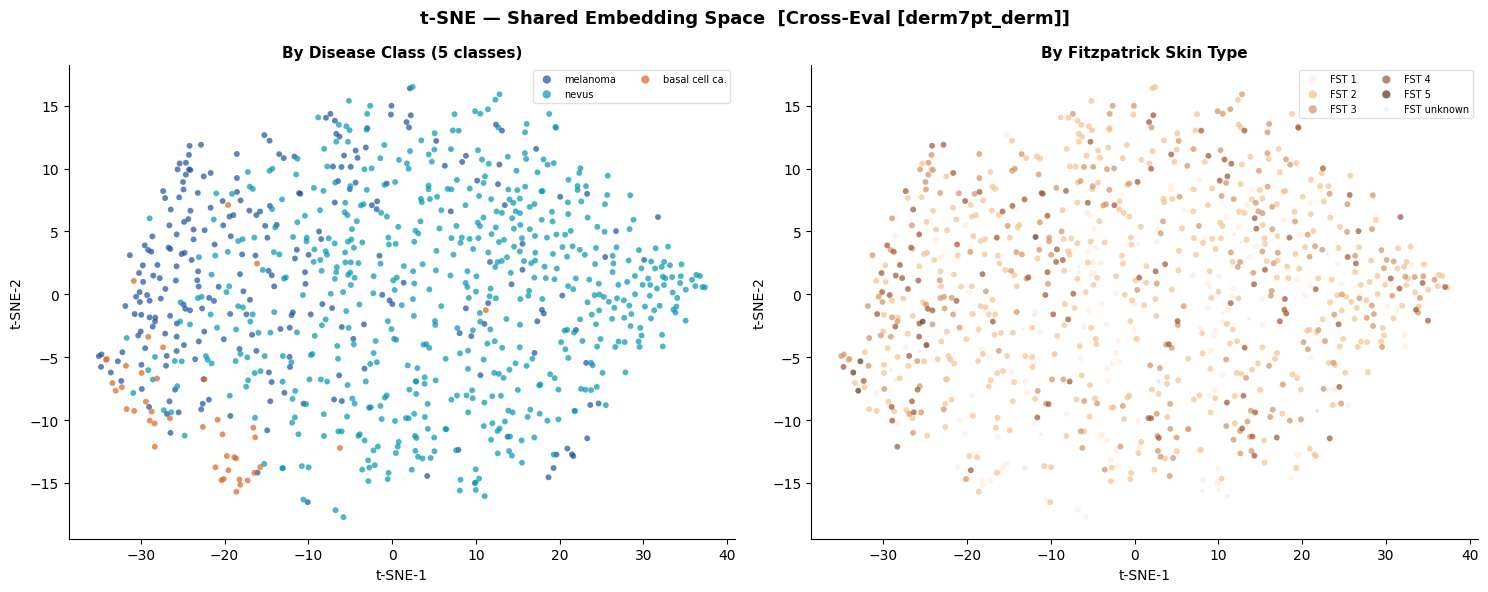

  Saved → derm7pt_derm_tsne_class_fst.png


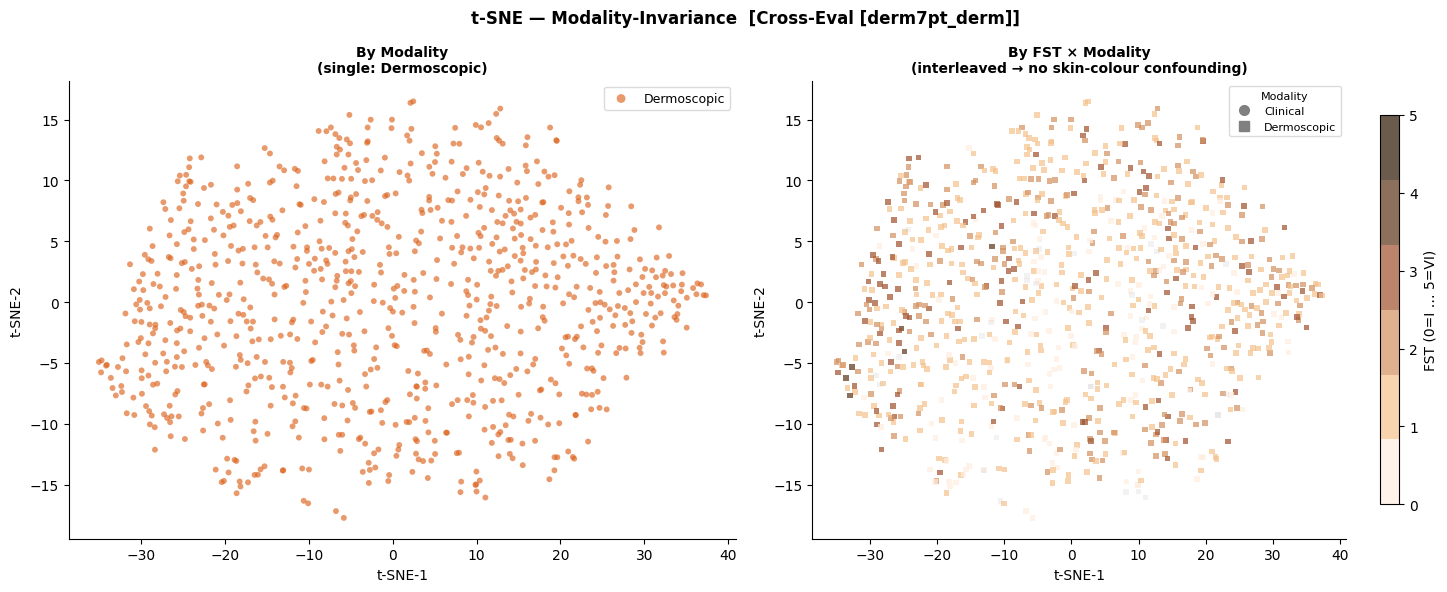

  Saved → derm7pt_derm_tsne_modality_invariance.png

── t-SNE: Cross-Eval [derm7pt_clinical] ──────────────────────────────────
  [Cross-Eval [derm7pt_clinical]] 869 samples  classes=[0, 1, 2]  modalities=[0]
  t-SNE: n=869, perplexity=40 ...


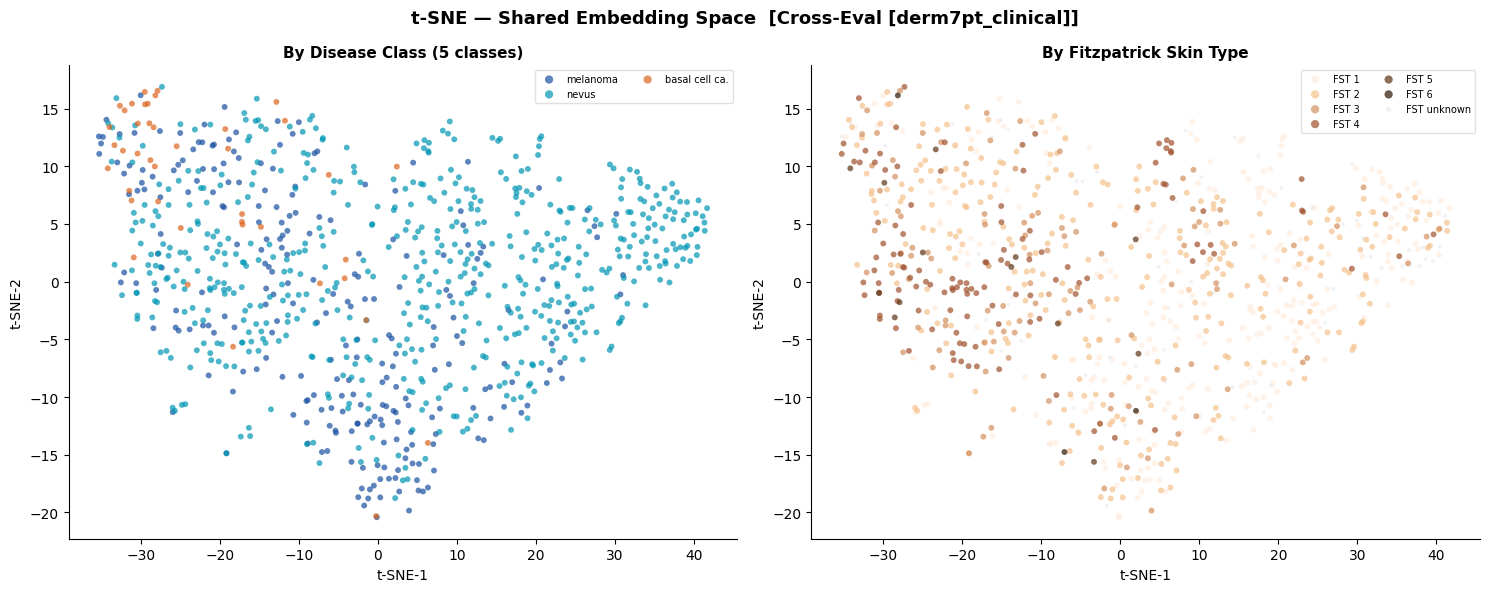

  Saved → derm7pt_clinical_tsne_class_fst.png


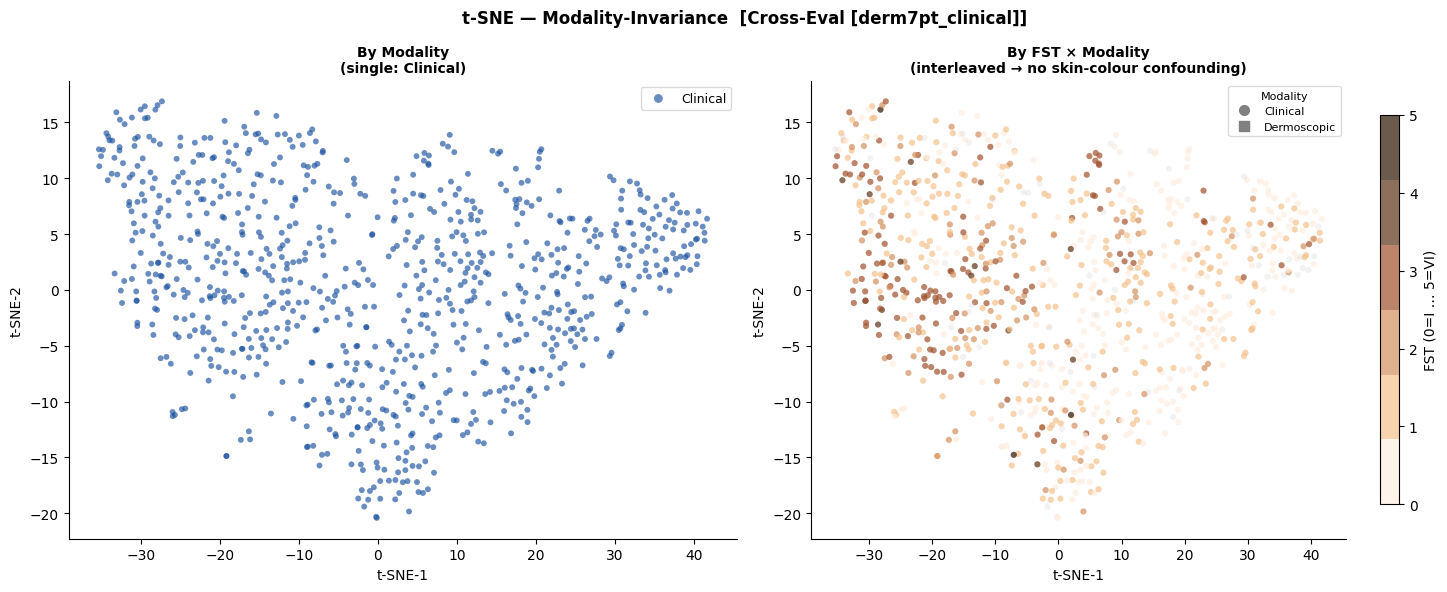

  Saved → derm7pt_clinical_tsne_modality_invariance.png

t-SNE visualization complete (no UMAP).


In [70]:
# ════════════════════════════════════════════════════════════════════════════
# t-SNE VISUALIZATIONS
# ════════════════════════════════════════════════════════════════════════════
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap as _LC
from matplotlib.lines import Line2D

# ── Palettes ─────────────────────────────────────────────────────────────
_CLS_COLORS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6']
_CLS_NAMES  = {0:'melanoma', 1:'nevus', 2:'basal cell ca.', 3:'actinic ker.', 4:'squamous cc.'}
_FST_COLORS = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']
_MOD_COLORS = {0: '#1950A0', 1: '#DC641E'}
_MOD_NAMES  = {0: 'Clinical', 1: 'Dermoscopic'}
_MARKERS    = {0: 'o', 1: 's'}
_MK_SIZE    = {0: 20,  1: 16}
_fst_map    = {i: f'FST {i+1}' for i in range(6)}
fst_cmap    = _LC(_FST_COLORS)


@torch.no_grad()
def extract_embeddings(loader, max_n=1500, tag=''):
    model.eval()  # FairDisCoModel
    Zs, Ls, Ss, Ms = [], [], [], []
    n_collected = 0
    for batch in loader:
        for k, v in batch.items():
            if isinstance(v, torch.Tensor): batch[k] = v.to(DEVICE)
        out = model(batch)
        b   = out['z'].size(0)
        Zs.append(out['z'].cpu())
        Ls.append(batch['label'].cpu())
        Ss.append(batch['skin_type'].cpu())
        mod_int = torch.tensor(
            [1 if m == 'derm' else 0
             for m in batch.get('modality', ['clinical'] * b)],
            dtype=torch.long)
        Ms.append(mod_int)
        n_collected += b
        if n_collected >= max_n: break
    embs  = torch.cat(Zs)[:max_n].numpy()
    labs  = torch.cat(Ls)[:max_n].numpy()
    skins = torch.cat(Ss)[:max_n].numpy()
    mods  = torch.cat(Ms)[:max_n].numpy()
    if tag:
        print(f'  [{tag}] {len(embs)} samples  '
              f'classes={sorted(set(labs.tolist()))}  '
              f'modalities={sorted(set(mods.tolist()))}')
    return embs, labs, skins, mods


def _scatter_labeled(ax, xy, color_ids, palette, labels_map, title,
                     xlabel='t-SNE-1', ylabel='t-SNE-2', s=18, alpha=0.7):
    for cid in sorted(set(color_ids)):
        mask = color_ids == cid
        ax.scatter(xy[mask, 0], xy[mask, 1], c=palette[cid % len(palette)],
                   s=s, alpha=alpha, label=labels_map.get(cid, str(cid)),
                   edgecolors='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, markerscale=1.4, framealpha=0.6, loc='best', ncol=2)
    ax.spines[['top','right']].set_visible(False)


def run_tsne_plots(loader, loader_tag, save_prefix, max_n=1500):
    print(f'\n── t-SNE: {loader_tag} ──────────────────────────────────')
    embs, labs, skins, mods = extract_embeddings(loader, max_n=max_n, tag=loader_tag)
    if len(embs) < 5:
        print(f'  [SKIP] too few samples ({len(embs)}) for t-SNE.'); return

    perp = min(40, max(5, len(embs) // 10))
    print(f'  t-SNE: n={len(embs)}, perplexity={perp} ...')
    e2d = TSNE(n_components=2, random_state=SEED, perplexity=perp,
               n_iter=1000, learning_rate='auto', init='pca').fit_transform(embs)
    mk = skins >= 0

    # Figure A: disease class | FST
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f't-SNE — Shared Embedding Space  [{loader_tag}]',
                 fontsize=13, fontweight='bold')
    _scatter_labeled(axes[0], e2d, labs, _CLS_COLORS, _CLS_NAMES, 'By Disease Class (5 classes)')
    _scatter_labeled(axes[1], e2d[mk], skins[mk], _FST_COLORS, _fst_map, 'By Fitzpatrick Skin Type')
    if (~mk).any():
        axes[1].scatter(e2d[~mk, 0], e2d[~mk, 1], c='#CCCCCC', s=8, alpha=0.25,
                        label='FST unknown', edgecolors='none')
        axes[1].legend(fontsize=7, markerscale=1.4, framealpha=0.6, ncol=2)
    plt.tight_layout()
    path_a = CFG['results_dir'] / f'{save_prefix}_tsne_class_fst.png'
    plt.savefig(path_a, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved → {path_a.name}')

    # Figure B: modality-invariance
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f't-SNE — Modality-Invariance  [{loader_tag}]',
                 fontsize=12, fontweight='bold')
    has_multi_mod = len(set(mods.tolist())) > 1
    for mid in [0, 1]:
        mask = mods == mid
        if mask.any():
            axes[0].scatter(e2d[mask, 0], e2d[mask, 1], c=_MOD_COLORS[mid], s=18,
                            alpha=0.65, label=_MOD_NAMES[mid], edgecolors='none')
    axes[0].set_title(
        'By Modality\n(mixed clusters → modality-invariant)' if has_multi_mod
        else f'By Modality\n(single: {_MOD_NAMES[int(mods[0])]})',
        fontweight='bold', fontsize=10)
    axes[0].set_xlabel('t-SNE-1'); axes[0].set_ylabel('t-SNE-2')
    axes[0].legend(fontsize=9, markerscale=1.5, framealpha=0.7)
    axes[0].spines[['top','right']].set_visible(False)

    sc = None
    for mid in [0, 1]:
        m_mask  = mods == mid
        fst_sub = skins[m_mask]
        xy_sub  = e2d[m_mask]
        known   = fst_sub >= 0
        if known.any():
            sc = axes[1].scatter(xy_sub[known, 0], xy_sub[known, 1],
                                 c=fst_sub[known], cmap=fst_cmap, vmin=0, vmax=5,
                                 marker=_MARKERS[mid], s=_MK_SIZE[mid],
                                 alpha=0.7, edgecolors='none', label=_MOD_NAMES[mid])
        if (~known).any():
            axes[1].scatter(xy_sub[~known, 0], xy_sub[~known, 1],
                            c='#CCCCCC', marker=_MARKERS[mid],
                            s=_MK_SIZE[mid], alpha=0.25, edgecolors='none')
    if sc is not None:
        plt.colorbar(sc, ax=axes[1], label='FST (0=I … 5=VI)', shrink=0.85)
    legend_h = [Line2D([0],[0], marker='o', color='grey', ms=7, ls='none', label='Clinical'),
                Line2D([0],[0], marker='s', color='grey', ms=7, ls='none', label='Dermoscopic')]
    axes[1].legend(handles=legend_h, fontsize=8, title='Modality', title_fontsize=8, framealpha=0.7)
    axes[1].set_title('By FST × Modality\n(interleaved → no skin-colour confounding)',
                      fontweight='bold', fontsize=10)
    axes[1].set_xlabel('t-SNE-1'); axes[1].set_ylabel('t-SNE-2')
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    path_b = CFG['results_dir'] / f'{save_prefix}_tsne_modality_invariance.png'
    plt.savefig(path_b, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Saved → {path_b.name}')


# ── Run t-SNE: internal test set ─────────────────────────────────────────
if test_loader is not None:
    run_tsne_plots(test_loader, loader_tag='Internal Test', save_prefix='test')
else:
    print('[SKIP] test_loader is None.')

# ── Run t-SNE: each Derm7pt eval loader (clinical, derm) ─────────────────
for ds_name, loader in eval_loaders.items():
    run_tsne_plots(loader, loader_tag=f'Cross-Eval [{ds_name}]', save_prefix=ds_name)

print('\nt-SNE visualization complete (no UMAP).')


# Summary — FairDisCo + Dual ResNet-18

| Phase | Content |
|-------|---------|
| 0 | GPU + Kaggle setup |
| 1 | **5-class** taxonomy; HIBA/Fitzpatrick17k/HAM10000/Derm7pt parsers; online augmentation |
| 2 | **Dual ResNet-18** (independent clinical + derm encoders) + fs (SA branch) + H (contrastive head) |
| 3 | **Lcls** (weighted CE) + **Lconf** (confusion) + **Ls** (skin CE detached) + **Lcontr** (supervised contrastive) · **No LMI** |
| 4A | **Baseline** training (Lcls only, 20 epochs) — provides FATE denominator |
| 4B | **FairDisCo** training (full objective, 80 epochs) — Adam, StepLR(step=2, γ=0.9) |
| 5 | Fairness: EOM/PQD/DPM/FATE; Baseline vs FairDisCo comparison table; cross-dataset Derm7pt |
| 6 | Training curves; per-FST Accuracy bars; cross-eval bars; t-SNE (modality × FST) |

